In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
import matplotlib.colors as mcolors

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.style.use('default')

sensor_display = {45: 'M1', 48: 'M2'}

def display_sensor(s):
    return sensor_display.get(s, s)

In [2]:
df_CityAI = pd.read_csv("CityAI_data.csv")
df_Munisense = pd.read_csv("Munisense_data.csv")
df_CityAI_sources = pd.read_csv("CityAI_sources_data.csv")
df_Survey = pd.read_csv("Survey_data.csv")

In [3]:
with open("question_labels.json", "r") as f:
    question_labels = json.load(f)

In [4]:
df_CityAI = df_CityAI[df_CityAI.sensor != 10]
df_Munisense = df_Munisense[df_Munisense.sensor != 48]
site_map_cityai = {
    2: 'Demolition', 3: 'Demolition',
    4: 'Construction', 5: 'Construction', 6: 'Construction',
    7: 'Renovation', 9: 'Renovation',
    11: 'Infrastructure', 12: 'Infrastructure'
}
site_map_munisense = {
    45: 'Demolition'
}

df_CityAI['site'] = df_CityAI.sensor.map(site_map_cityai)
df_Munisense['site'] = df_Munisense.sensor.map(site_map_munisense)

df_CityAI['source'] = 'cityai'
df_Munisense['source'] = 'munisense'

combined = pd.concat([df_CityAI, df_Munisense], ignore_index=True)

# Sensor Analysis

This section details the analysis of sensor data, starting with Temporal Analysis

### Temporal Analysis

Sensor data for both types is analysed by day of week, by week and by hour of day to get a complete profile.

#### Day of Week Analysis

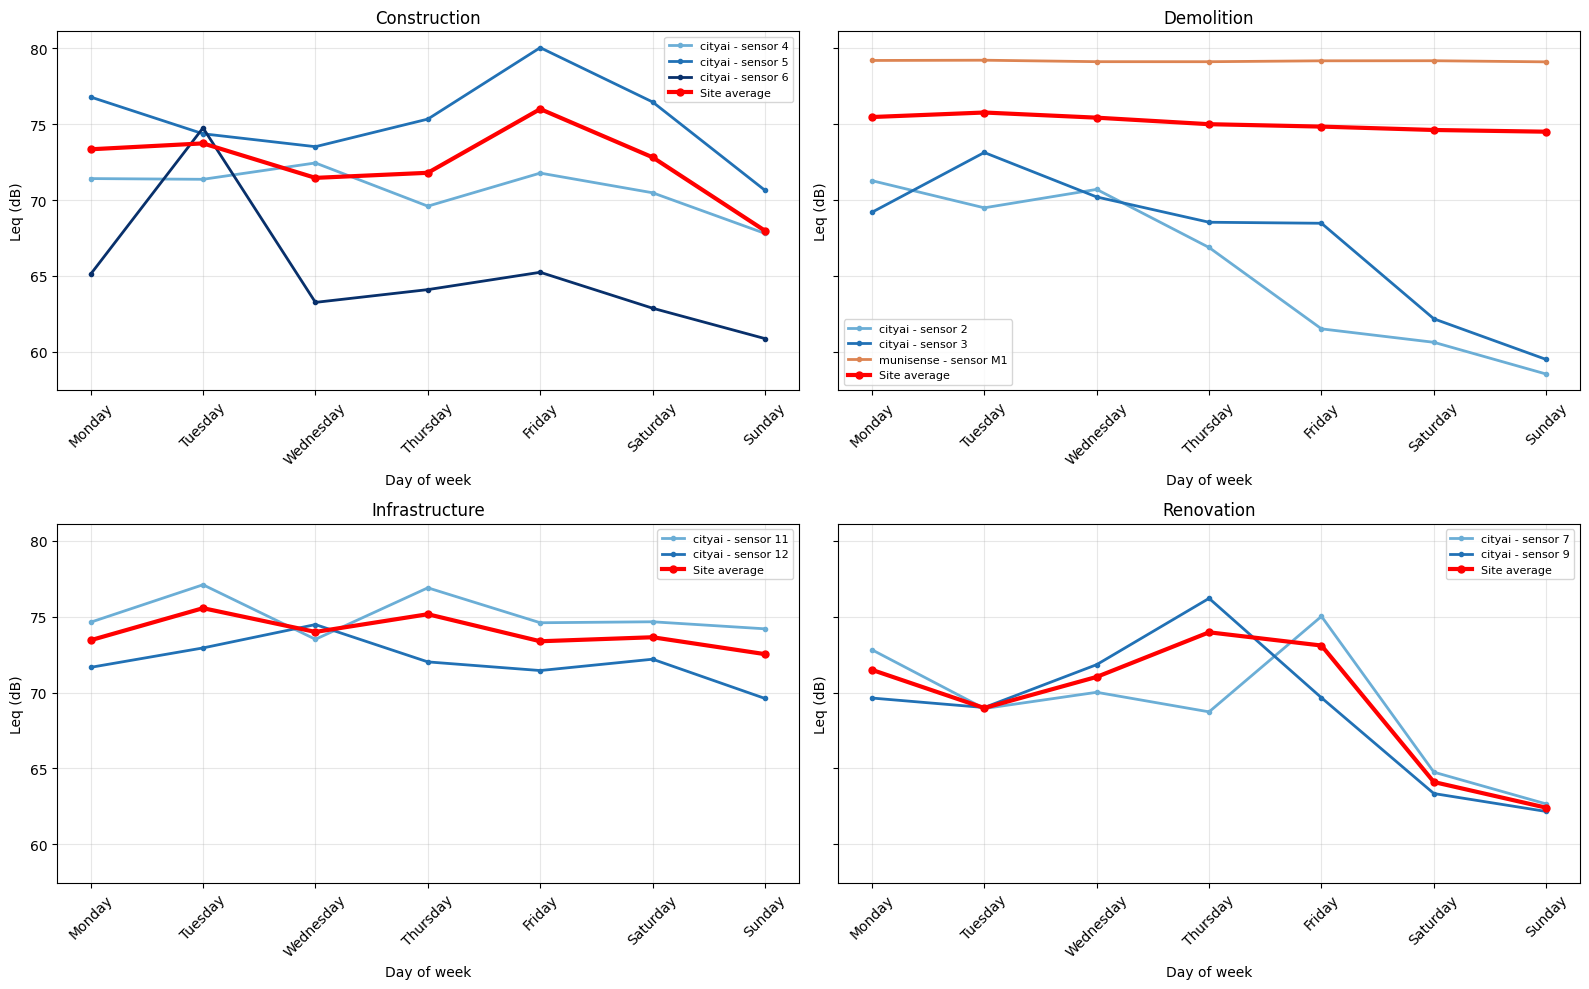

In [5]:
cityai_shades = ['#6BAED6', '#2171B5', '#08306B']

def get_color(source, sensor, site): #this just gives each sensor its own colour.
    if source == 'munisense':
        return '#DD8452'
    else:
        sensors_at_site = sorted(
            combined[(combined.site == site) & (combined.source == 'cityai')]['sensor'].unique()
        )
        idx = sensors_at_site.index(sensor)
        return cityai_shades[idx % len(cityai_shades)]

# ensures datetime is parsed correctly
combined['datetime'] = pd.to_datetime(combined['datetime'])
combined['day_of_week'] = combined['datetime'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

#  per-sensor by day of week
dow_sensor = (
    combined.groupby(['site', 'source', 'sensor', 'day_of_week'])['avg_spla']
    .mean()
    .reset_index()
)
dow_sensor['Leq'] = 10 * np.log10(dow_sensor['avg_spla'])
dow_sensor['day_of_week'] = pd.Categorical(dow_sensor['day_of_week'], categories=day_order, ordered=True)

# per-site by day of week (raw average across all readings)
dow_site = (
    combined.groupby(['site', 'day_of_week'])['avg_spla']
    .mean()
    .reset_index()
)
dow_site['Leq'] = 10 * np.log10(dow_site['avg_spla'])
dow_site['day_of_week'] = pd.Categorical(dow_site['day_of_week'], categories=day_order, ordered=True)



sites = dow_sensor['site'].dropna().unique()
n_cols = 2
n_rows = int(np.ceil(len(sites) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 5 * n_rows), sharey=True)
axes = np.array(axes).reshape(-1)


for ax, site in zip(axes, sites):
    site_data = dow_sensor[dow_sensor.site == site]
    for (source, sensor), grp in site_data.groupby(['source', 'sensor']):
        grp = grp.sort_values('day_of_week')
        ax.plot(
            grp['day_of_week'], grp['Leq'],
            marker='o', markersize=3, linewidth=2,
            color=get_color(source, sensor, site),
            alpha=1, zorder= 8,
            label=f'{source} - sensor {display_sensor(sensor)}'
        )

    avg_data = dow_site[dow_site.site == site].sort_values('day_of_week')
    ax.plot(
        avg_data['day_of_week'], avg_data['Leq'],
        color='red', linewidth=3, marker='o', markersize=5,
        zorder=10,
        label='Site average'
    )

    ax.set_title(site)
    ax.set_xlabel('Day of week')
    ax.set_ylabel('Leq (dB)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(sites):]:
    ax.axis('off')

plt.tight_layout()
#plt.savefig('day_of_week_pattern_by_site.png', dpi=150)
plt.show()

#### Observations
##### Construction
1. Peaks on Friday, Saturday, human noise causing it?
2. Sensor 6 acts a bit strange, weird peak on Tuesday.
3. Sensors 4 and 5 are very aligned
##### Demolition
1. All dip on the weekends, sensor 3 most significantly. Location probably plays a role
2. Similar trends between Munisense and sensor 3, sensor 2 actually kind of stands out.
3. Munisense is much lower than both others during the week, but about the same on weekends: are cityAI sensors more sensitive to construction? Could it be due to placement?
##### Infrastructure
1. Loud all week but lower on weekends - busy area
2. Really weird trend on Wednesday, why?
##### Renovation
1. Huge dip on weekends, why? Construction noise exclusively, or traffic?
2. Very similar pattern between sensors

#### Week of Project Analysis

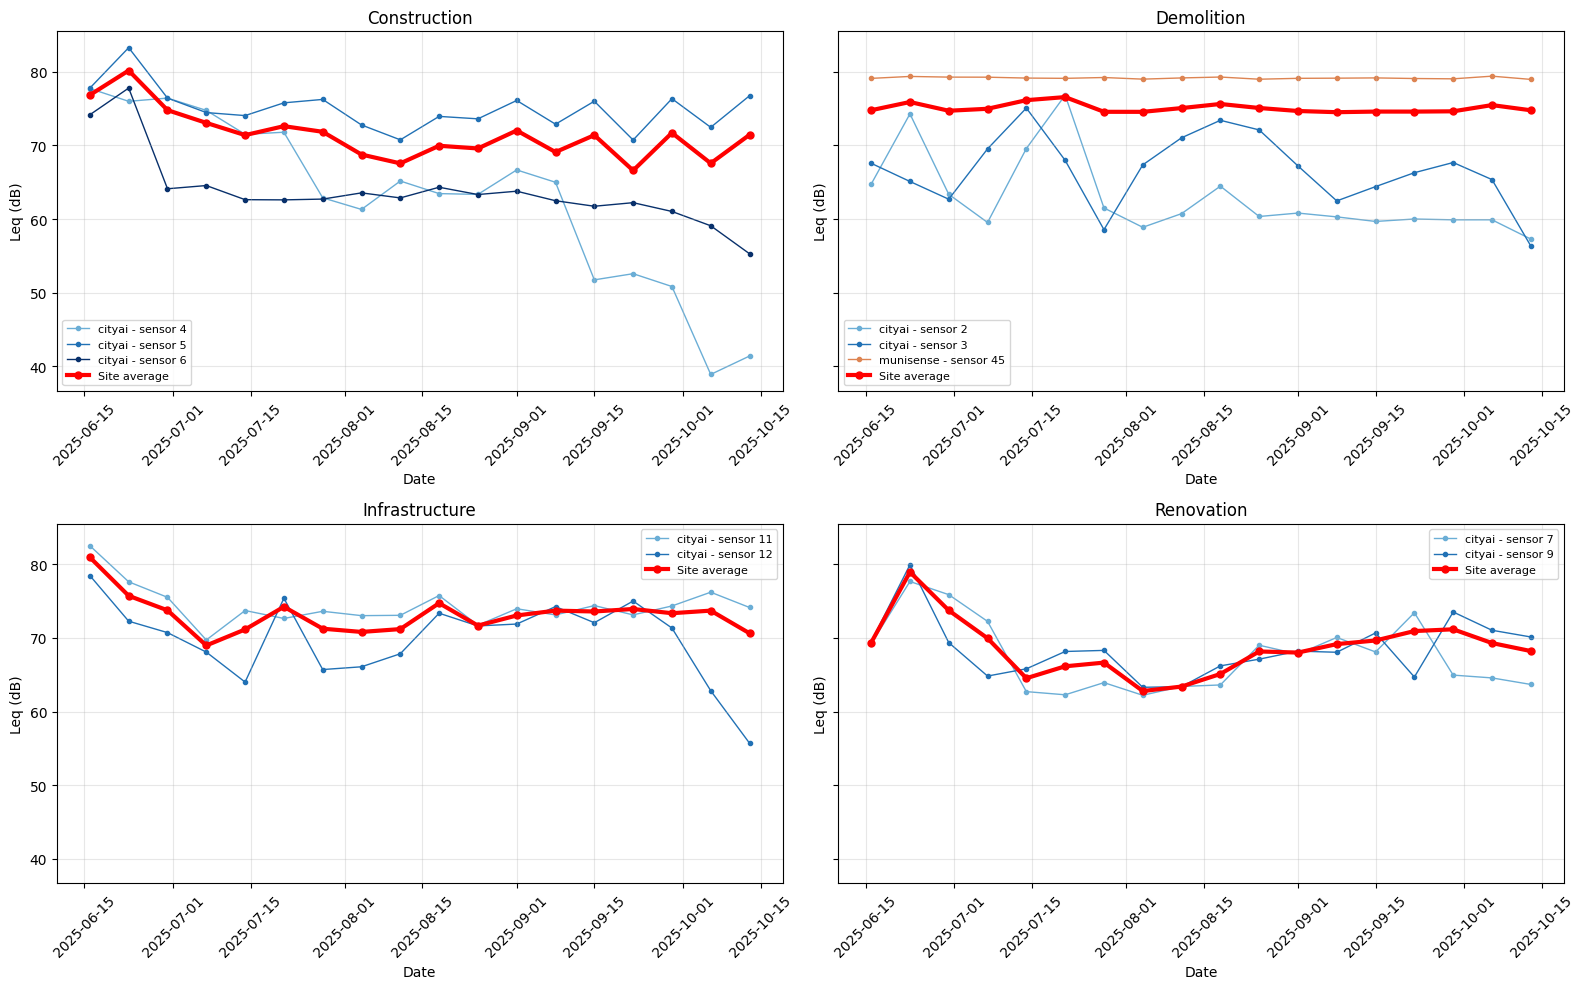

In [6]:
# ensure datetime is parsed
combined['week'] = combined['datetime'].dt.to_period('W').dt.start_time  # week start date

# per-sensor by week
week_sensor = (
    combined.groupby(['site', 'source', 'sensor', 'week'])['avg_spla']
    .mean()
    .reset_index()
)
week_sensor['Leq'] = 10 * np.log10(week_sensor['avg_spla'])

# per-site by week (raw average across all readings)
week_site = (
    combined.groupby(['site', 'week'])['avg_spla']
    .mean()
    .reset_index()
)
week_site['Leq'] = 10 * np.log10(week_site['avg_spla'])

#  plot: grid layout, 2 per row
sites = week_sensor['site'].dropna().unique()
n_cols = 2
n_rows = int(np.ceil(len(sites) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 5 * n_rows), sharey=True)
axes = np.array(axes).reshape(-1)


for ax, site in zip(axes, sites):
    site_data = week_sensor[week_sensor.site == site]
    for (source, sensor), grp in site_data.groupby(['source', 'sensor']):
        grp = grp.sort_values('week')
        ax.plot(
            grp['week'], grp['Leq'],
            marker='o', markersize=3, linewidth=1,
            color=get_color(source, sensor, site),
            alpha=1, zorder=1,
            label=f'{source} - sensor {sensor}'
        )

    avg_data = week_site[week_site.site == site].sort_values('week')
    ax.plot(
        avg_data['week'], avg_data['Leq'],
        color='red', linewidth=3, marker='o', markersize=5,
        zorder=10,
        label='Site average'
    )

    ax.set_title(site)
    ax.set_xlabel('Date')
    ax.set_ylabel('Leq (dB)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(sites):]:
    ax.axis('off')

plt.tight_layout()
#plt.savefig('weekly_trend_by_site.png', dpi=150)
plt.show()

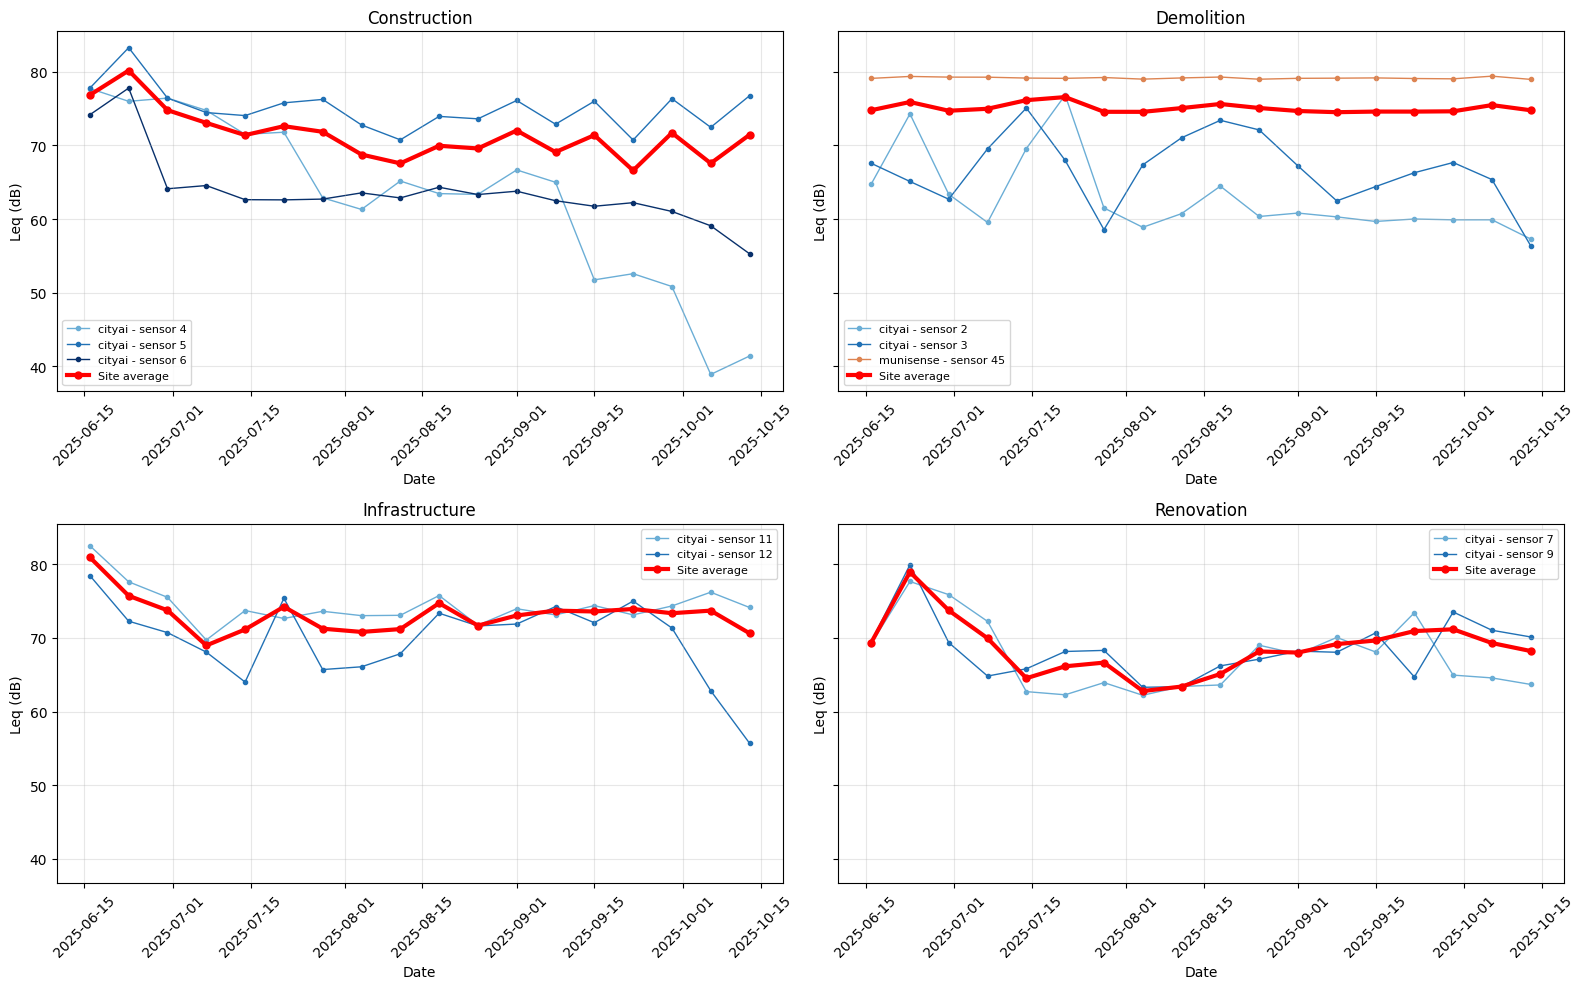

week                             2025-06-16  2025-06-23  2025-06-30  \
site           source    sensor                                       
Construction   cityai    4             77.7        76.0        76.4   
                         5             77.8        83.3        76.4   
                         6             74.2        77.8        64.1   
Demolition     cityai    2             64.7        74.3        63.4   
                         3             67.6        65.1        62.7   
               munisense 45            79.1        79.4        79.3   
Infrastructure cityai    11            82.5        77.6        75.5   
                         12            78.5        72.3        70.7   
Renovation     cityai    7             69.2        77.7        75.9   
                         9             69.5        79.9        69.4   

week                             2025-07-07  2025-07-14  2025-07-21  \
site           source    sensor                                       
Construction   cityai    4             74.7        71.5        71.8   
                         5             74.5        74.0        75.8   
                         6             64.5        62.6        62.6   
Demolition     cityai    2             59.5        69.6        76.8   
                         3             69.5        75.1        68.0   
               munisense 45            79.3        79.1        79.1   
Infrastructure cityai    11            69.7        73.7        72.6   
                         12            68.1        64.0        75.4   
Renovation     cityai    7             72.2        62.7        62.3   
                         9             64.8        65.8        68.2   

week                             2025-07-28  2025-08-04  2025-08-11  \
site           source    sensor                                       
Construction   cityai    4             62.9        61.3        65.2   
                         5             76.2        72.8        70.8   
                         6             62.7        63.6        62.9   
Demolition     cityai    2             61.5        58.9        60.7   
                         3             58.6        67.4        71.0   
               munisense 45            79.2        79.0        79.2   
Infrastructure cityai    11            73.6        73.0        73.1   
                         12            65.7        66.1        67.8   
Renovation     cityai    7             63.9        62.2        63.4   
                         9             68.3        63.3        63.4   

week                             2025-08-18  2025-08-25  2025-09-01  \
site           source    sensor                                       
Construction   cityai    4             63.5        63.3        66.7   
                         5             73.9        73.6        76.1   
                         6             64.3        63.3        63.8   
Demolition     cityai    2             64.5        60.3        60.8   
                         3             73.4        72.1        67.2   
               munisense 45            79.3        79.0        79.1   
Infrastructure cityai    11            75.7        71.7        74.0   
                         12            73.3        71.6        71.9   
Renovation     cityai    7             63.6        69.0        67.8   
                         9             66.2        67.1        68.2   

week                             2025-09-08  2025-09-15  2025-09-22  \
site           source    sensor                                       
Construction   cityai    4             65.0        51.7        52.6   
                         5             72.9        76.0        70.7   
                         6             62.5        61.7        62.2   
Demolition     cityai    2             60.3        59.7        60.0   
                         3             62.5        64.4        66.3   
               munisense 45            79.1        79.2        79.1   
Infrastructure citya

In [7]:
combined['week'] = combined['datetime'].dt.to_period('W').dt.start_time

week_sensor = (
    combined.groupby(['site', 'source', 'sensor', 'week'])['avg_spla']
    .mean()
    .reset_index()
)
week_sensor['Leq'] = 10 * np.log10(week_sensor['avg_spla'])

week_site = (
    combined.groupby(['site', 'week'])['avg_spla']
    .mean()
    .reset_index()
)
week_site['Leq'] = 10 * np.log10(week_site['avg_spla'])

sites = week_sensor['site'].dropna().unique()
n_cols = 2
n_rows = int(np.ceil(len(sites) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 5 * n_rows), sharey=True)
axes = np.array(axes).reshape(-1)

for ax, site in zip(axes, sites):
    site_data = week_sensor[week_sensor.site == site]
    for (source, sensor), grp in site_data.groupby(['source', 'sensor']):
        grp = grp.sort_values('week')
        ax.plot(
            grp['week'], grp['Leq'],
            marker='o', markersize=3, linewidth=1,
            color=get_color(source, sensor, site),
            alpha=1, zorder=1,
            label=f'{source} - sensor {sensor}'
        )

    avg_data = week_site[week_site.site == site].sort_values('week')
    ax.plot(
        avg_data['week'], avg_data['Leq'],
        color='red', linewidth=3, marker='o', markersize=5,
        zorder=10,
        label='Site average'
    )

    ax.set_title(site)
    ax.set_xlabel('Date')
    ax.set_ylabel('Leq (dB)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(sites):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

week_sensor_table = week_sensor.pivot_table(
    index=['site', 'source', 'sensor'],
    columns='week',
    values='Leq'
).round(1)

week_site_table = week_site.pivot_table(
    index='site',
    columns='week',
    values='Leq'
).round(1)

week_sensor_table

#### Observations
##### Construction
1. Huge dip for sensor 4 at the end of the project, why? Smaller dip for sensor 6, no issue with sensor 5
##### Demolition
1. Munisense goes on longer
2. Peak in the cityAI sensors in July, but not munisense, why?
3. Sensor 3 has a lot higher values in August, October, why?
##### Infrastructure
1. Similar trend overall, but sensor 12 is strange, random peak in July, huge dip in October
##### Renovation
1. Very similar pattern overall, not much to say.

The graph below details the whole project day-by-day, to get a more granular view of the project.

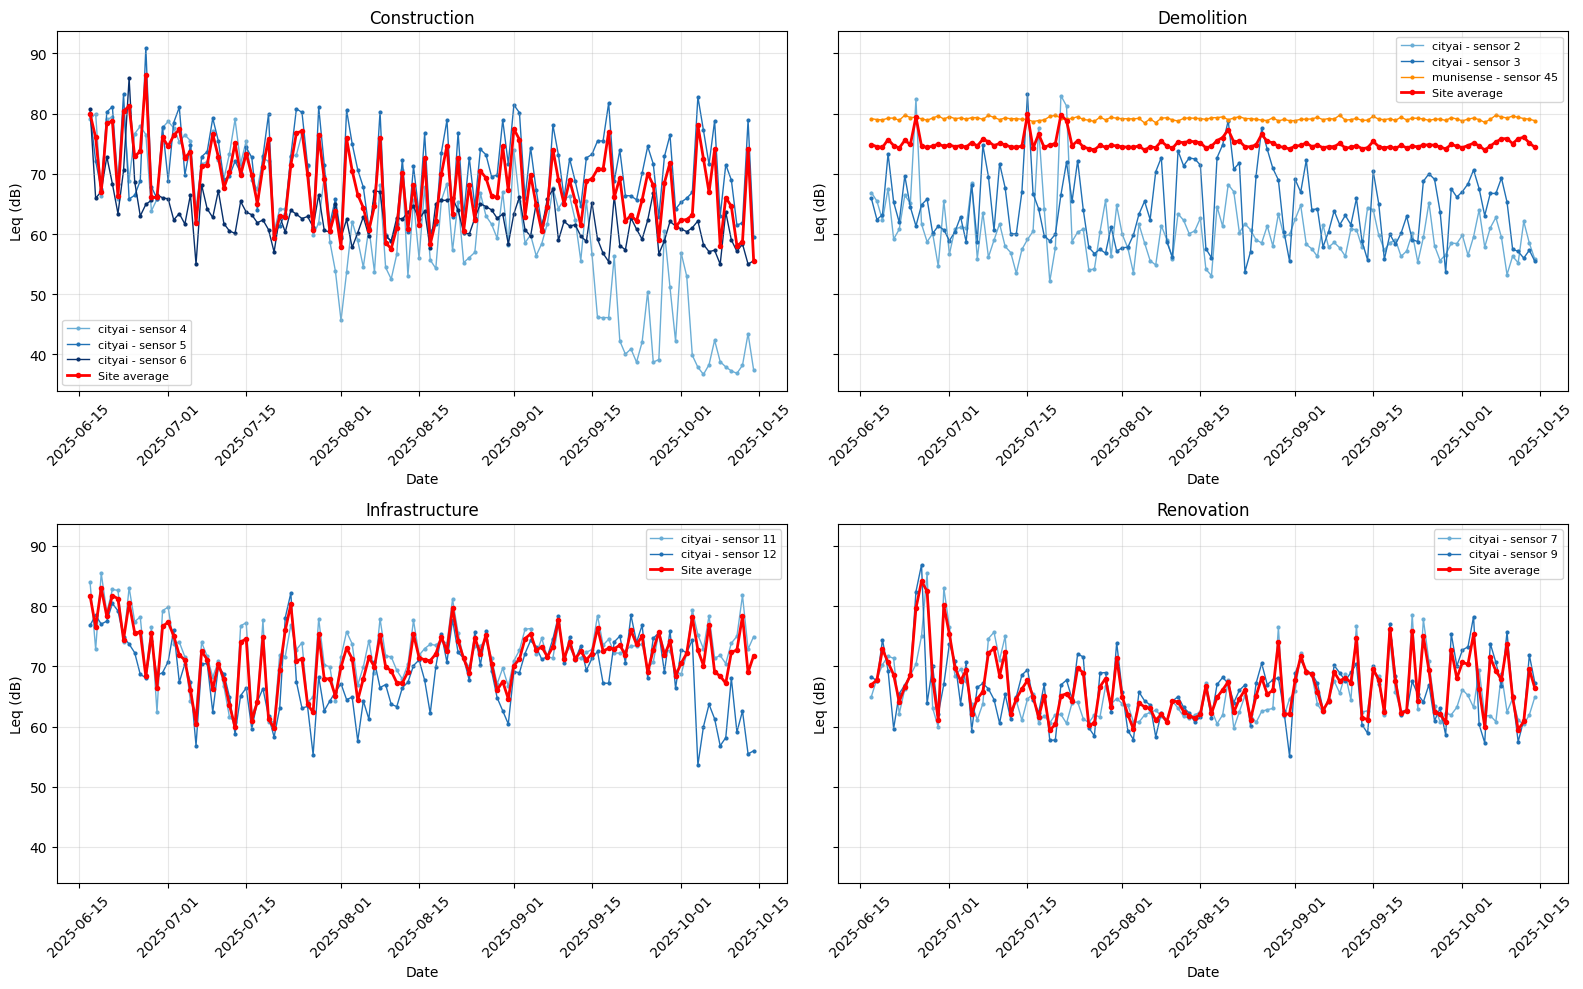

In [8]:
combined['day'] = combined['datetime'].dt.normalize()

day_sensor = (
    combined.groupby(['site', 'source', 'sensor', 'day'])['avg_spla']
    .mean()
    .reset_index()
)
day_sensor['Leq'] = 10 * np.log10(day_sensor['avg_spla'])

day_site = (
    combined.groupby(['site', 'day'])['avg_spla']
    .mean()
    .reset_index()
)
day_site['Leq'] = 10 * np.log10(day_site['avg_spla'])

blue_shades = ['#6BAED6', '#2171B5', '#08306B']

def get_color(source, sensor, site):
    if source == 'munisense':
        return '#FF8C00'  # orange
    else:
        sensors_at_site = sorted(
            combined[(combined.site == site) & (combined.source == 'cityai')]['sensor'].unique()
        )
        idx = sensors_at_site.index(sensor)
        return blue_shades[idx % len(blue_shades)]

sites = day_sensor['site'].dropna().unique()
n_cols = 2
n_rows = int(np.ceil(len(sites) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 5 * n_rows), sharey=True)
axes = np.array(axes).reshape(-1)

for ax, site in zip(axes, sites):
    site_data = day_sensor[day_sensor.site == site]
    for (source, sensor), grp in site_data.groupby(['source', 'sensor']):
        grp = grp.sort_values('day')
        ax.plot(
            grp['day'], grp['Leq'],
            marker='o', markersize=2, linewidth=1,
            color=get_color(source, sensor, site),
            alpha=1, zorder=1,
            label=f'{source} - sensor {sensor}'
        )

    avg_data = day_site[day_site.site == site].sort_values('day')
    ax.plot(
        avg_data['day'], avg_data['Leq'],
        color='red', linewidth=2, marker='o', markersize=3,
        zorder=10,
        label='Site average'
    )

    ax.set_title(site)
    ax.set_xlabel('Date')
    ax.set_ylabel('Leq (dB)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(sites):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [9]:
day_sensor_summary = (
    day_sensor.groupby(['site', 'source', 'sensor'])['Leq']
    .agg(['min', 'max', 'mean', 'std'])
    .round(1)
)

day_sensor_summary

min   max  mean   std
site           source    sensor                        
Construction   cityai    4       36.7  80.4  60.4  12.5
                         5       58.8  91.0  70.7   6.8
                         6       55.0  85.9  62.6   4.4
Demolition     cityai    2       52.1  83.0  60.4   5.2
                         3       53.6  83.2  64.3   6.1
               munisense 45      78.5  79.8  79.2   0.3
Infrastructure cityai    11      60.8  85.5  72.6   4.9
                         12      53.6  82.2  68.6   6.2
Renovation     cityai    7       59.7  85.5  65.4   5.1
                         9       55.1  86.9  66.2   5.3

The next graph looks at hour of day.

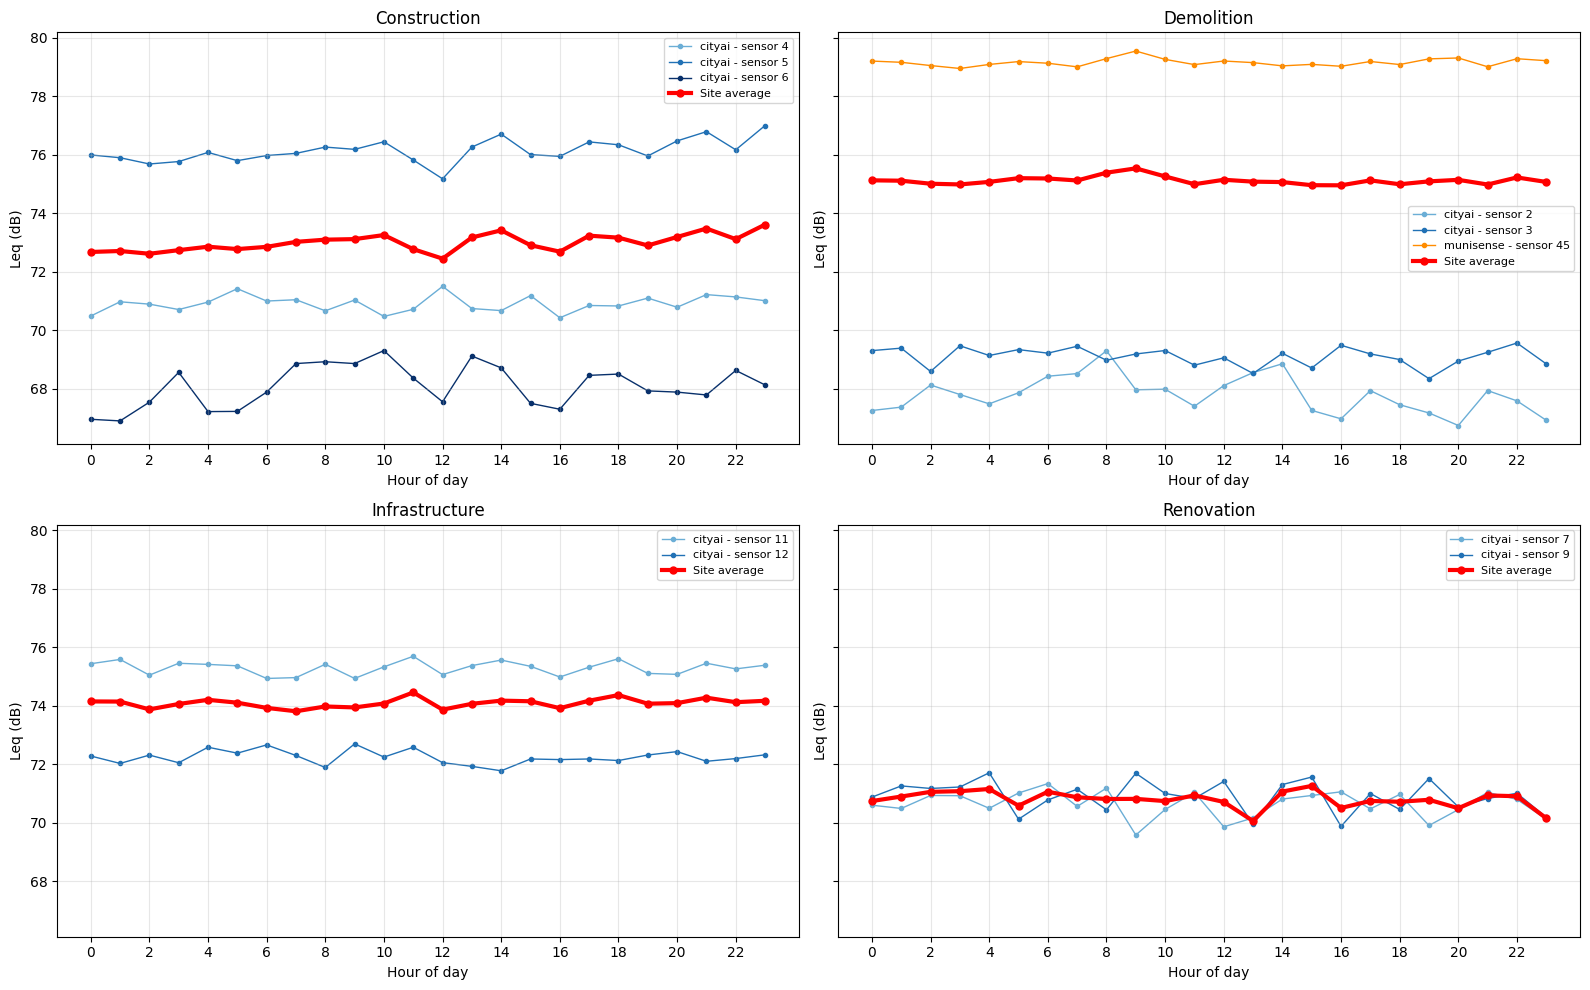

In [10]:
combined['hour'] = combined['datetime'].dt.hour

diurnal_sensor = (
    combined.groupby(['site', 'source', 'sensor', 'hour'])['avg_spla']
    .mean()
    .reset_index()
)
diurnal_sensor['Leq'] = 10 * np.log10(diurnal_sensor['avg_spla'])

diurnal_site = (
    combined.groupby(['site', 'hour'])['avg_spla']
    .mean()
    .reset_index()
)
diurnal_site['Leq'] = 10 * np.log10(diurnal_site['avg_spla'])

sites = diurnal_sensor['site'].dropna().unique()
n_cols = 2
n_rows = int(np.ceil(len(sites) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 5 * n_rows), sharey=True)
axes = np.array(axes).reshape(-1)

for ax, site in zip(axes, sites):
    site_data = diurnal_sensor[diurnal_sensor.site == site]
    for (source, sensor), grp in site_data.groupby(['source', 'sensor']):
        grp = grp.sort_values('hour')
        ax.plot(
            grp['hour'], grp['Leq'],
            marker='o', markersize=3, linewidth=1,
            color=get_color(source, sensor, site),
            alpha=1, zorder=1,
            label=f'{source} - sensor {sensor}'
        )

    avg_data = diurnal_site[diurnal_site.site == site].sort_values('hour')
    ax.plot(
        avg_data['hour'], avg_data['Leq'],
        color='red', linewidth=3, marker='o', markersize=5,
        zorder=10,
        label='Site average'
    )

    ax.set_title(site)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Leq (dB)')
    ax.set_xticks(range(0, 24, 2))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(sites):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

The code below just allows to get the actual values shown in the graph above.

In [11]:
combined['hour'] = combined['datetime'].dt.hour

diurnal_sensor = (
    combined.groupby(['site', 'source', 'sensor', 'hour'])['avg_spla']
    .mean()
    .reset_index()
)
diurnal_sensor['Leq'] = 10 * np.log10(diurnal_sensor['avg_spla'])

diurnal_site = (
    combined.groupby(['site', 'hour'])['avg_spla']
    .mean()
    .reset_index()
)
diurnal_site['Leq'] = 10 * np.log10(diurnal_site['avg_spla'])

diurnal_sensor_table = diurnal_sensor.pivot_table(
    index=['site', 'source', 'sensor'],
    columns='hour',
    values='Leq'
).round(1)

diurnal_site_table = diurnal_site.pivot_table(
    index='site',
    columns='hour',
    values='Leq'
).round(1)

print(diurnal_sensor_table.to_string())

hour                               0     1     2     3     4     5     6     7     8     9     10    11    12    13    14    15    16    17    18    19    20    21    22    23
site           source    sensor                                                                                                                                                
Construction   cityai    4       70.5  71.0  70.9  70.7  71.0  71.4  71.0  71.0  70.7  71.0  70.5  70.7  71.5  70.7  70.7  71.2  70.4  70.8  70.8  71.1  70.8  71.2  71.1  71.0
                         5       76.0  75.9  75.7  75.8  76.1  75.8  76.0  76.0  76.3  76.2  76.4  75.8  75.2  76.3  76.7  76.0  75.9  76.4  76.3  76.0  76.5  76.8  76.2  77.0
                         6       67.0  66.9  67.5  68.6  67.2  67.2  67.9  68.9  68.9  68.9  69.3  68.4  67.6  69.1  68.7  67.5  67.3  68.5  68.5  67.9  67.9  67.8  68.6  68.1
Demolition     cityai    2       67.3  67.4  68.1  67.8  67.5  67.9  68.4  68.5  69.3  68.0  68.0  67.4  68.1  68.6  68.

#### Observations
##### Construction
1. Similar trend for all, peak for sensors 5 and 6 at around 10 but not 4, strange
##### Demolition
1. A bit messier, especially sensor 2. For some reason there's a drop at midday, why? Could be work stops but then why does it not show in the others?
2. Munisense far more consistant
##### Infrastructure
1. Very similar pattern for all, overall super loud though even at night
##### Renovation
1. Also similar pattern, almost exactly the same which is interesting. Could be nice to wonder why these are so similar, but those are construction or demolition very different. Also, major difference between day and night (almost 30dba!!)

### Noise Events

this part of the code has three sub-parts: counts, noise level and sharpness. The table below displays the statistics for each.

In [12]:
df_CityAI_sources['site'] = df_CityAI_sources['sensor'].map(site_map_cityai)

stats_by_sensor = (
    df_CityAI_sources.groupby(['sensor', 'site'])
    .agg(
        count=('avg_spl_a', 'count'),
        mean_linear=('avg_spl_a', 'mean'),
        mean_sharpness=('avg_sharpness', 'mean')
    )
    .reset_index()
)
stats_by_sensor['avg_dba'] = 10 * np.log10(stats_by_sensor['mean_linear'])

print("By sensor:")
print(stats_by_sensor[['sensor', 'site', 'count', 'avg_dba', 'mean_sharpness']].to_string())

stats_by_label = (
    df_CityAI_sources.groupby('label')
    .agg(
        count=('avg_spl_a', 'count'),
        mean_linear=('avg_spl_a', 'mean'),
        mean_sharpness=('avg_sharpness', 'mean')
    )
    .reset_index()
)
stats_by_label['avg_dba'] = 10 * np.log10(stats_by_label['mean_linear'])

print("\nBy label:")
print(stats_by_label[['label', 'count', 'avg_dba', 'mean_sharpness']].sort_values('count', ascending=False).to_string())

By sensor:
   sensor            site    count    avg_dba  mean_sharpness
0       2      Demolition  3122876  86.201510        2.392878
1       3      Demolition  3071406  85.391091        2.451751
2       4    Construction  3206788  91.455684        2.693535
3       5    Construction  3124951  96.826046        2.679380
4       6    Construction  3236830  84.067942        2.975252
5       7      Renovation  2600327  87.809009        2.746922
6       9      Renovation  2751559  88.958887        2.882974
7      11  Infrastructure  3061260  95.064310        2.819312
8      12  Infrastructure  2660299  90.922458        2.967684

By label:
            label    count    avg_dba  mean_sharpness
0   AngleGrinding  2443664  91.690735        2.729661
3           Human  2441336  91.682510        2.729877
7         Reverse  2441333  91.684048        2.727039
1           Drill  2441070  91.685756        2.729197
2       Generator  2439354  91.698111        2.728306
6          Piling  2439059  91.691

In [13]:
df_CityAI_sources['time'] = pd.to_datetime(df_CityAI_sources['time'])
df_CityAI_sources['hour'] = df_CityAI_sources['time'].dt.hour
daytime_events = df_CityAI_sources[df_CityAI_sources['hour'].between(7, 19)].copy()

df_CityAI['datetime'] = pd.to_datetime(df_CityAI['datetime'])
df_CityAI['hour'] = df_CityAI['datetime'].dt.hour
daytime_stream = df_CityAI[df_CityAI['hour'].between(7, 19)].copy()

site_daytime_leq = (
    daytime_stream.groupby('site')['avg_spla']
    .mean()
    .apply(lambda x: 10 * np.log10(x))
    .reset_index(name='site_daytime_avg_dba')
)

stats_by_sensor = (
    daytime_events.groupby(['sensor', 'site'])
    .agg(count=('avg_spl_a', 'count'), mean_linear=('avg_spl_a', 'mean'), mean_sharpness=('avg_sharpness', 'mean'))
    .reset_index()
)
stats_by_sensor['avg_dba'] = 10 * np.log10(stats_by_sensor['mean_linear'])
stats_by_sensor = pd.merge(stats_by_sensor, site_daytime_leq, on='site')

print("By sensor (daytime only):")
print(stats_by_sensor[['sensor', 'site', 'count', 'avg_dba', 'mean_sharpness', 'site_daytime_avg_dba']].to_string())

stats_by_label_site = (
    daytime_events.groupby(['site', 'label'])
    .agg(count=('avg_spl_a', 'count'), mean_linear=('avg_spl_a', 'mean'), mean_sharpness=('avg_sharpness', 'mean'))
    .reset_index()
)
stats_by_label_site['avg_dba'] = 10 * np.log10(stats_by_label_site['mean_linear'])
stats_by_label_site = pd.merge(stats_by_label_site, site_daytime_leq, on='site')

print("\nBy label + site (daytime only):")
print(stats_by_label_site[['site', 'label', 'count', 'avg_dba', 'mean_sharpness', 'site_daytime_avg_dba']]
      .sort_values(['site', 'count'], ascending=[True, False])
      .to_string())

stats_by_label = (
    daytime_events.groupby('label')
    .agg(count=('avg_spl_a', 'count'), mean_linear=('avg_spl_a', 'mean'), mean_sharpness=('avg_sharpness', 'mean'))
    .reset_index()
)
stats_by_label['avg_dba'] = 10 * np.log10(stats_by_label['mean_linear'])

overall_daytime_dba = 10 * np.log10(daytime_stream['avg_spla'].mean())
stats_by_label['overall_daytime_avg_dba'] = overall_daytime_dba

print("\nBy label (pooled, daytime only):")
print(stats_by_label[['label', 'count', 'avg_dba', 'mean_sharpness', 'overall_daytime_avg_dba']]
      .sort_values('count', ascending=False)
      .to_string())

By sensor (daytime only):
   sensor            site    count    avg_dba  mean_sharpness  site_daytime_avg_dba
0       2      Demolition  1689638  86.572090        2.444552             68.549303
1       3      Demolition  1672112  85.756449        2.502209             68.549303
2       4    Construction  1741673  91.779957        2.735740             73.021830
3       5    Construction  1700116  97.181794        2.742129             73.021830
4       6    Construction  1756053  84.417839        3.020221             73.021830
5       7      Renovation  1409368  88.157219        2.793613             70.779590
6       9      Renovation  1489991  89.331960        2.942347             70.779590
7      11  Infrastructure  1666289  95.323082        2.878927             74.082259
8      12  Infrastructure  1424472  91.232955        3.034490             74.082259

By label + site (daytime only):
              site          label   count    avg_dba  mean_sharpness  site_daytime_avg_dba
2     Cons

#### By Hour

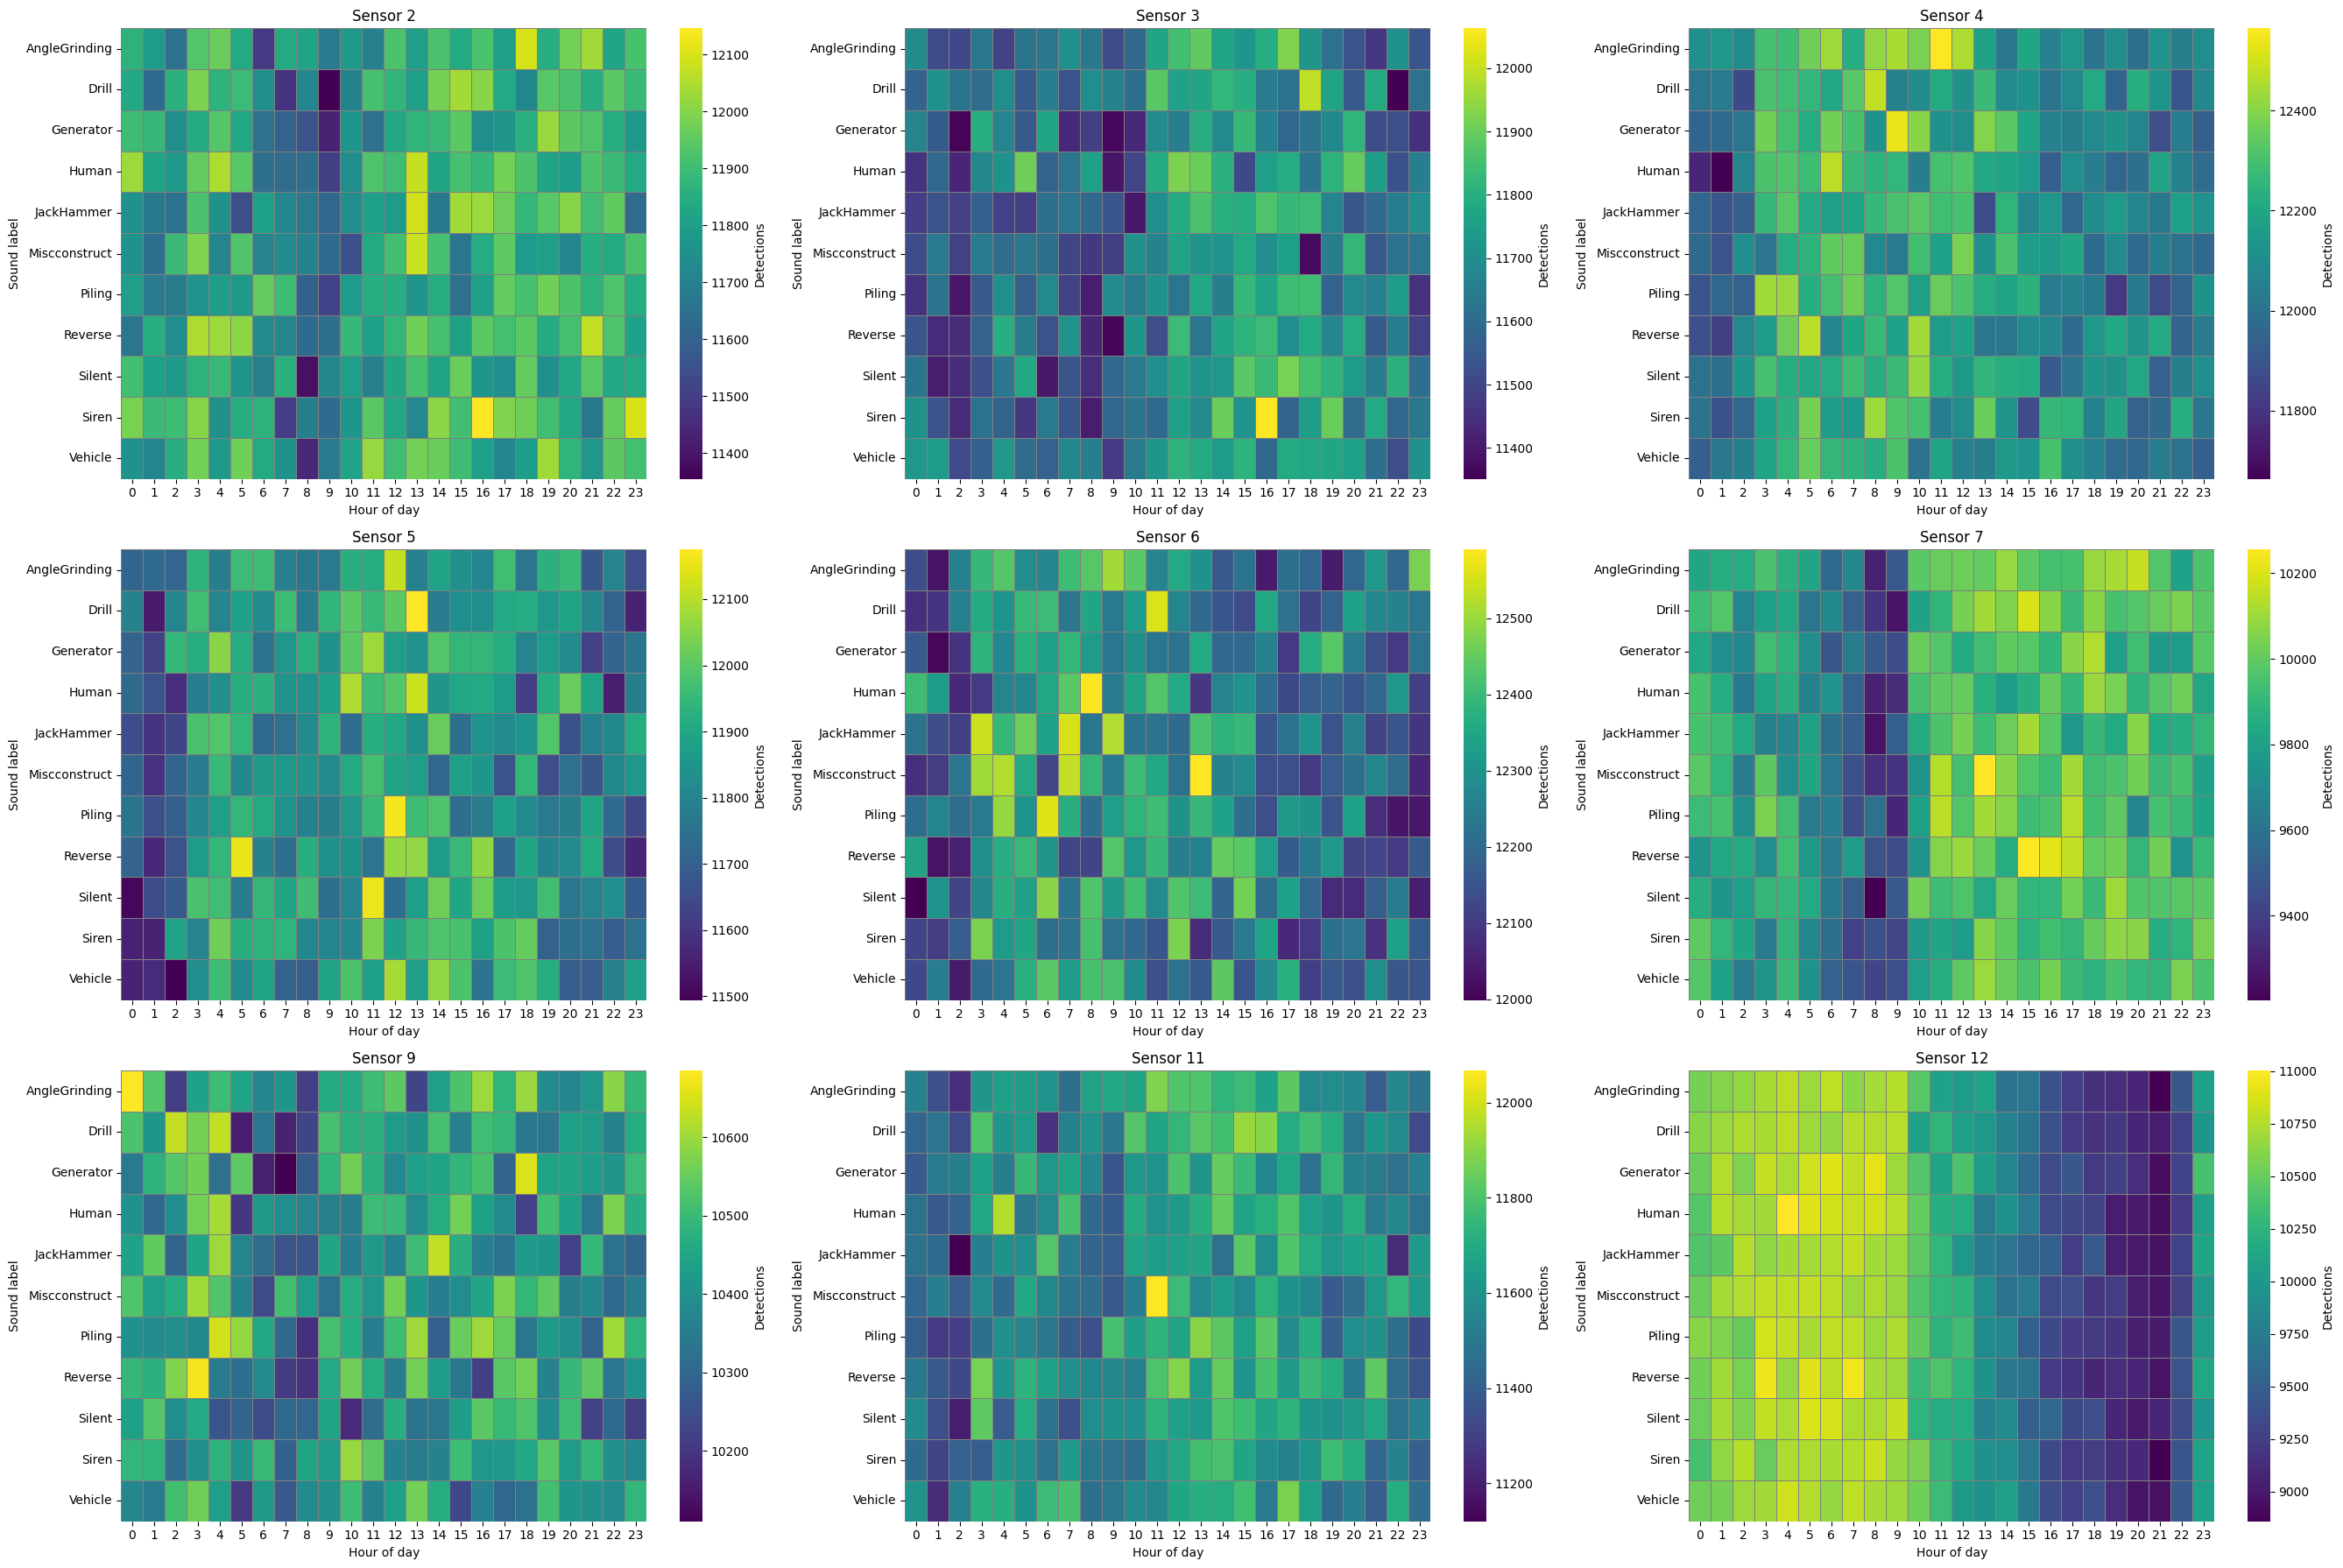

In [14]:
counts = (
    df_CityAI_sources
    .groupby(['sensor', 'label', 'hour'])
    .size()
    .reset_index(name='count')
)

sensors = sorted(counts['sensor'].unique())
n_cols = 3
n_rows = int(np.ceil(len(sensors) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(9 * n_cols, 6 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, sensor in zip(axes, sensors):
    sensor_data = counts[counts.sensor == sensor]

    pivot = sensor_data.pivot_table(
        index='label', columns='hour', values='count',
        fill_value=0
    )
    pivot = pivot.reindex(columns=range(24), fill_value=0)

    sns.heatmap(
        pivot, ax=ax, cmap='viridis', cbar_kws={'label': 'Detections'},
        linewidths=0.5, linecolor='gray'
    )
    ax.set_title(f'Sensor {sensor}')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Sound label')

for ax in axes[len(sensors):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

#### Obversations
1. For all Silent and Vehicles dominate, silent values are always stronger at night (makes sense).

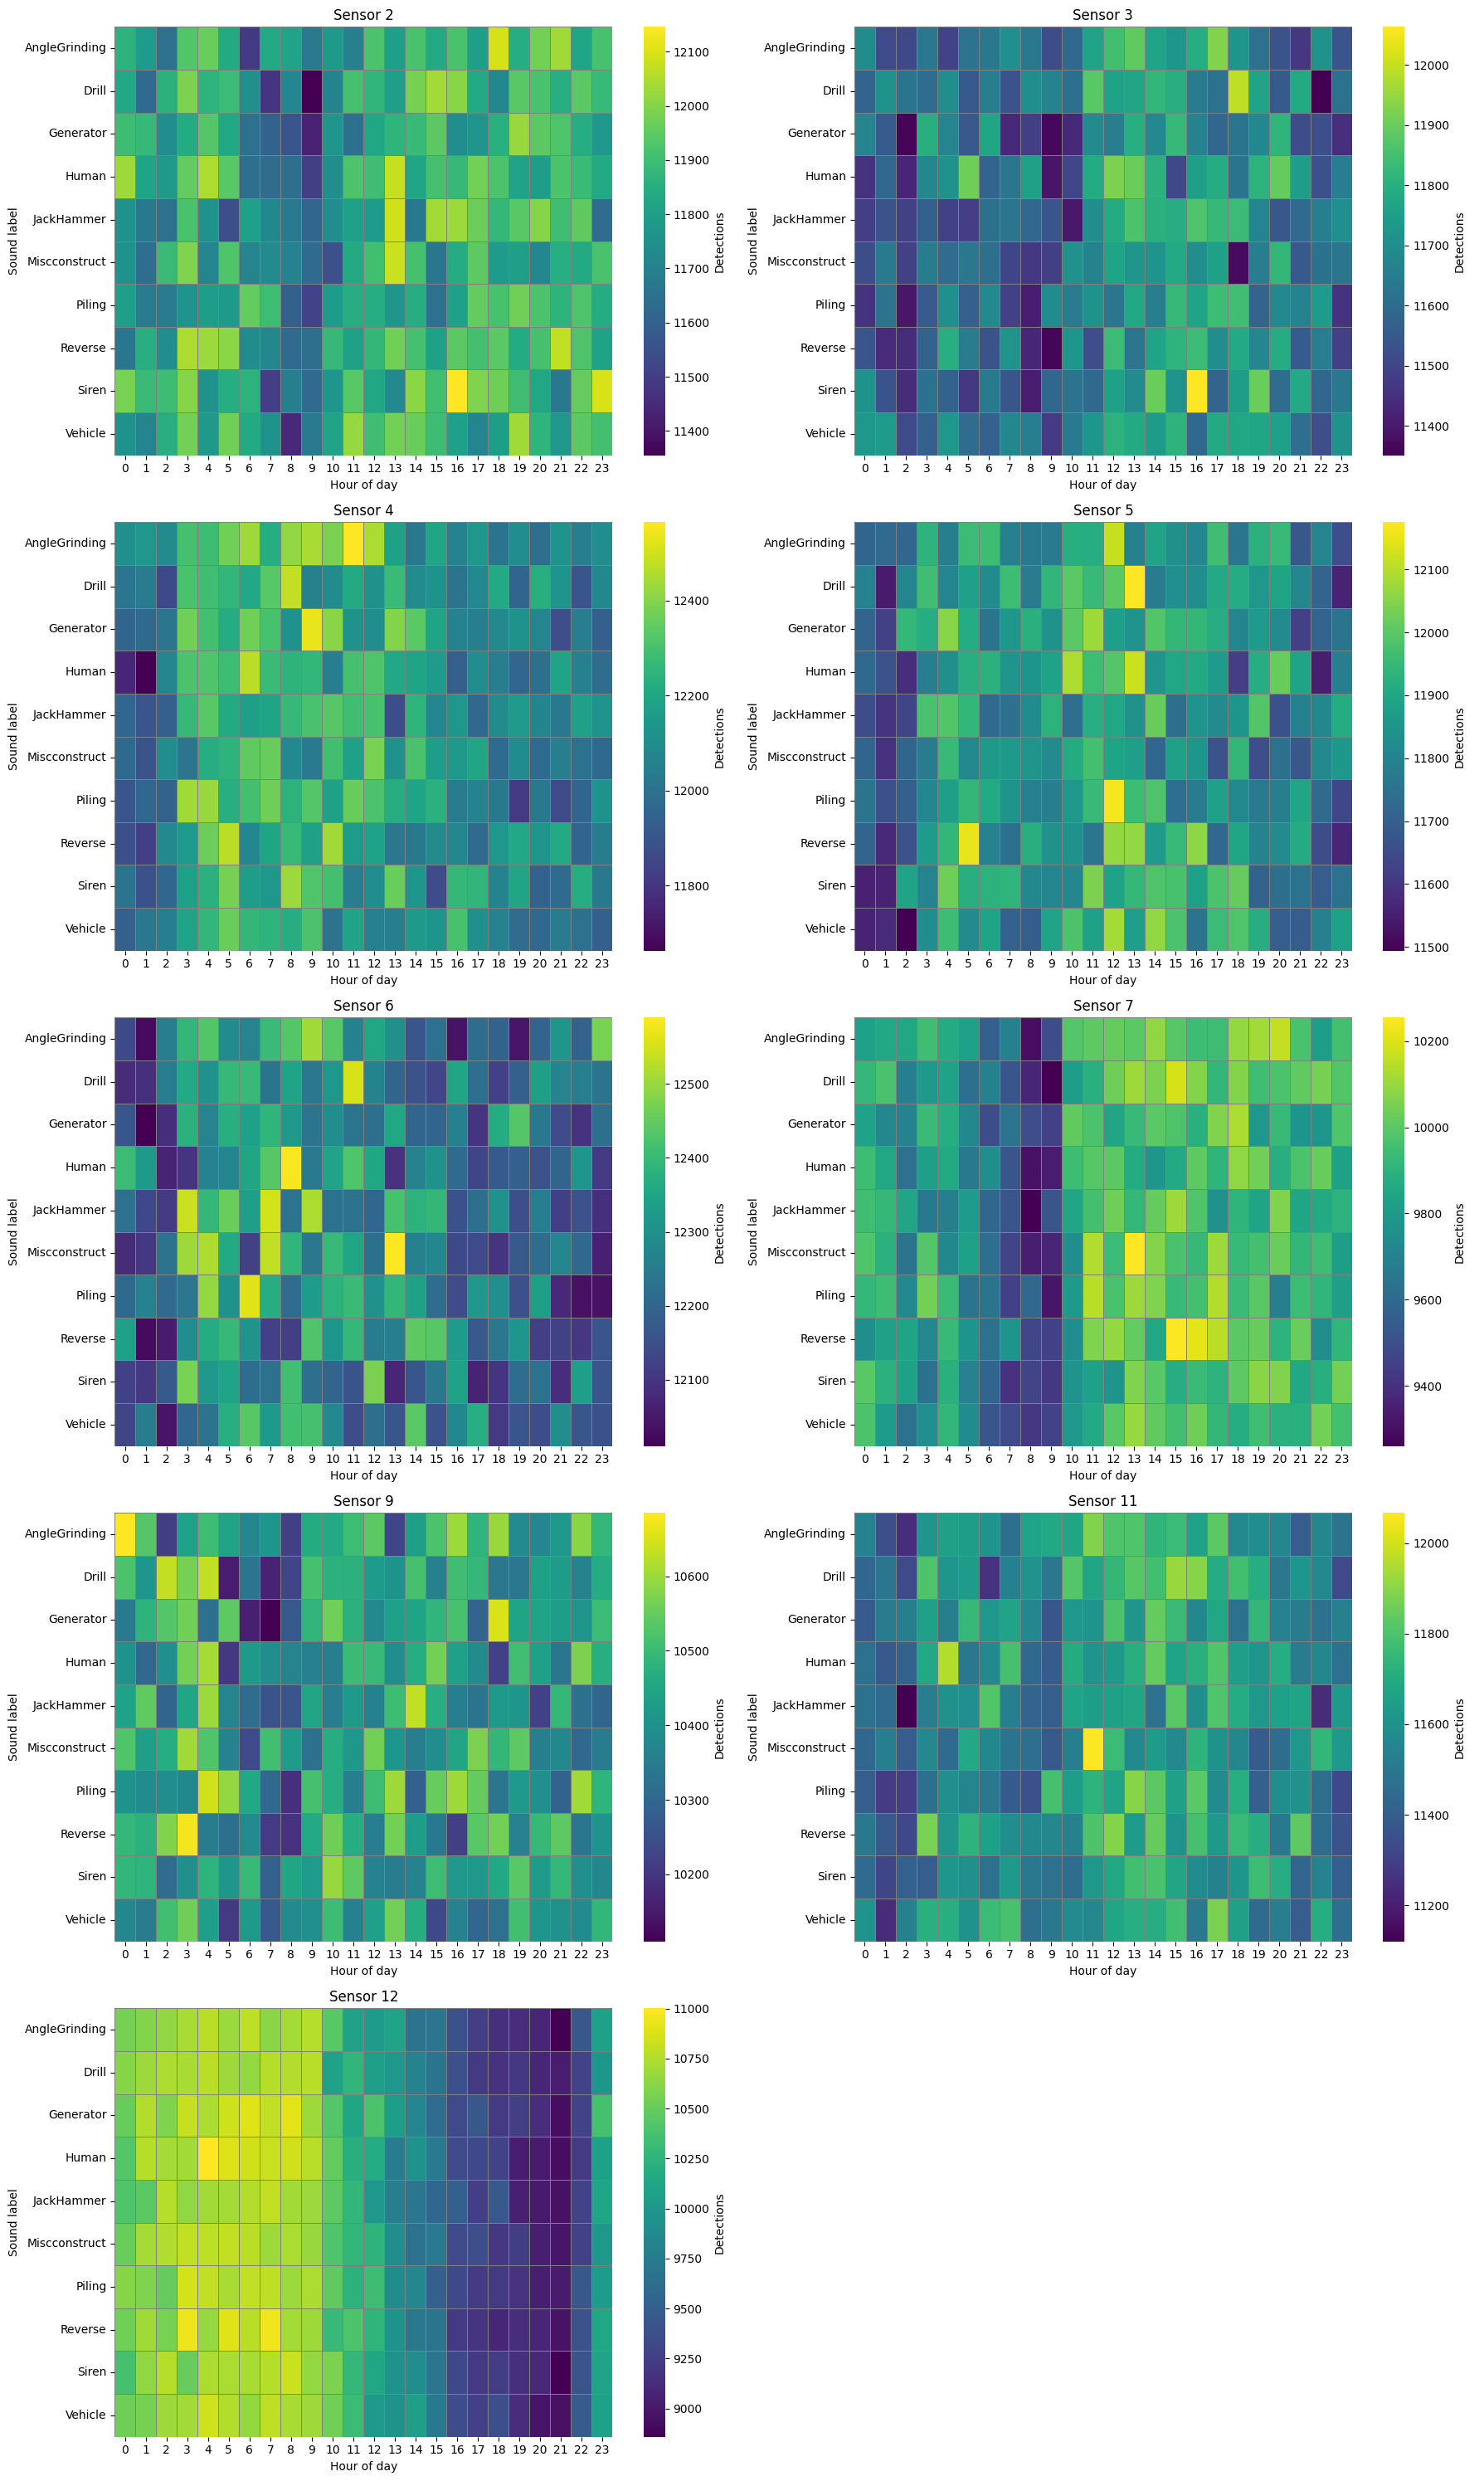

In [15]:
exclude_labels = ['silent']
df_filtered = df_CityAI_sources[~df_CityAI_sources['label'].str.lower().isin(exclude_labels)]

counts = (
    df_filtered
    .groupby(['sensor', 'label', 'hour'])
    .size()
    .reset_index(name='count')
)

sensors = sorted(counts['sensor'].unique())
n_cols = 2
n_rows = int(np.ceil(len(sensors) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(9 * n_cols, 6 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, sensor in zip(axes, sensors):
    sensor_data = counts[counts.sensor == sensor]

    pivot = sensor_data.pivot_table(
        index='label', columns='hour', values='count',
        fill_value=0
    )
    pivot = pivot.reindex(columns=range(24), fill_value=0)

    sns.heatmap(
        pivot, ax=ax, cmap='viridis', cbar_kws={'label': 'Detections'},
        linewidths=0.5, linecolor='gray'
    )
    ax.set_title(f'Sensor {sensor}')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Sound label')

for ax in axes[len(sensors):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

##### Observation
1. Vehicles are most important during midday and  early afternoon, except for sensor 2 where it's morning for some reason? Pretty significant differences here between sensors 2 and 3, could it explain some of the differences? It's weird, because also sensor 3 was on average louder! Why??

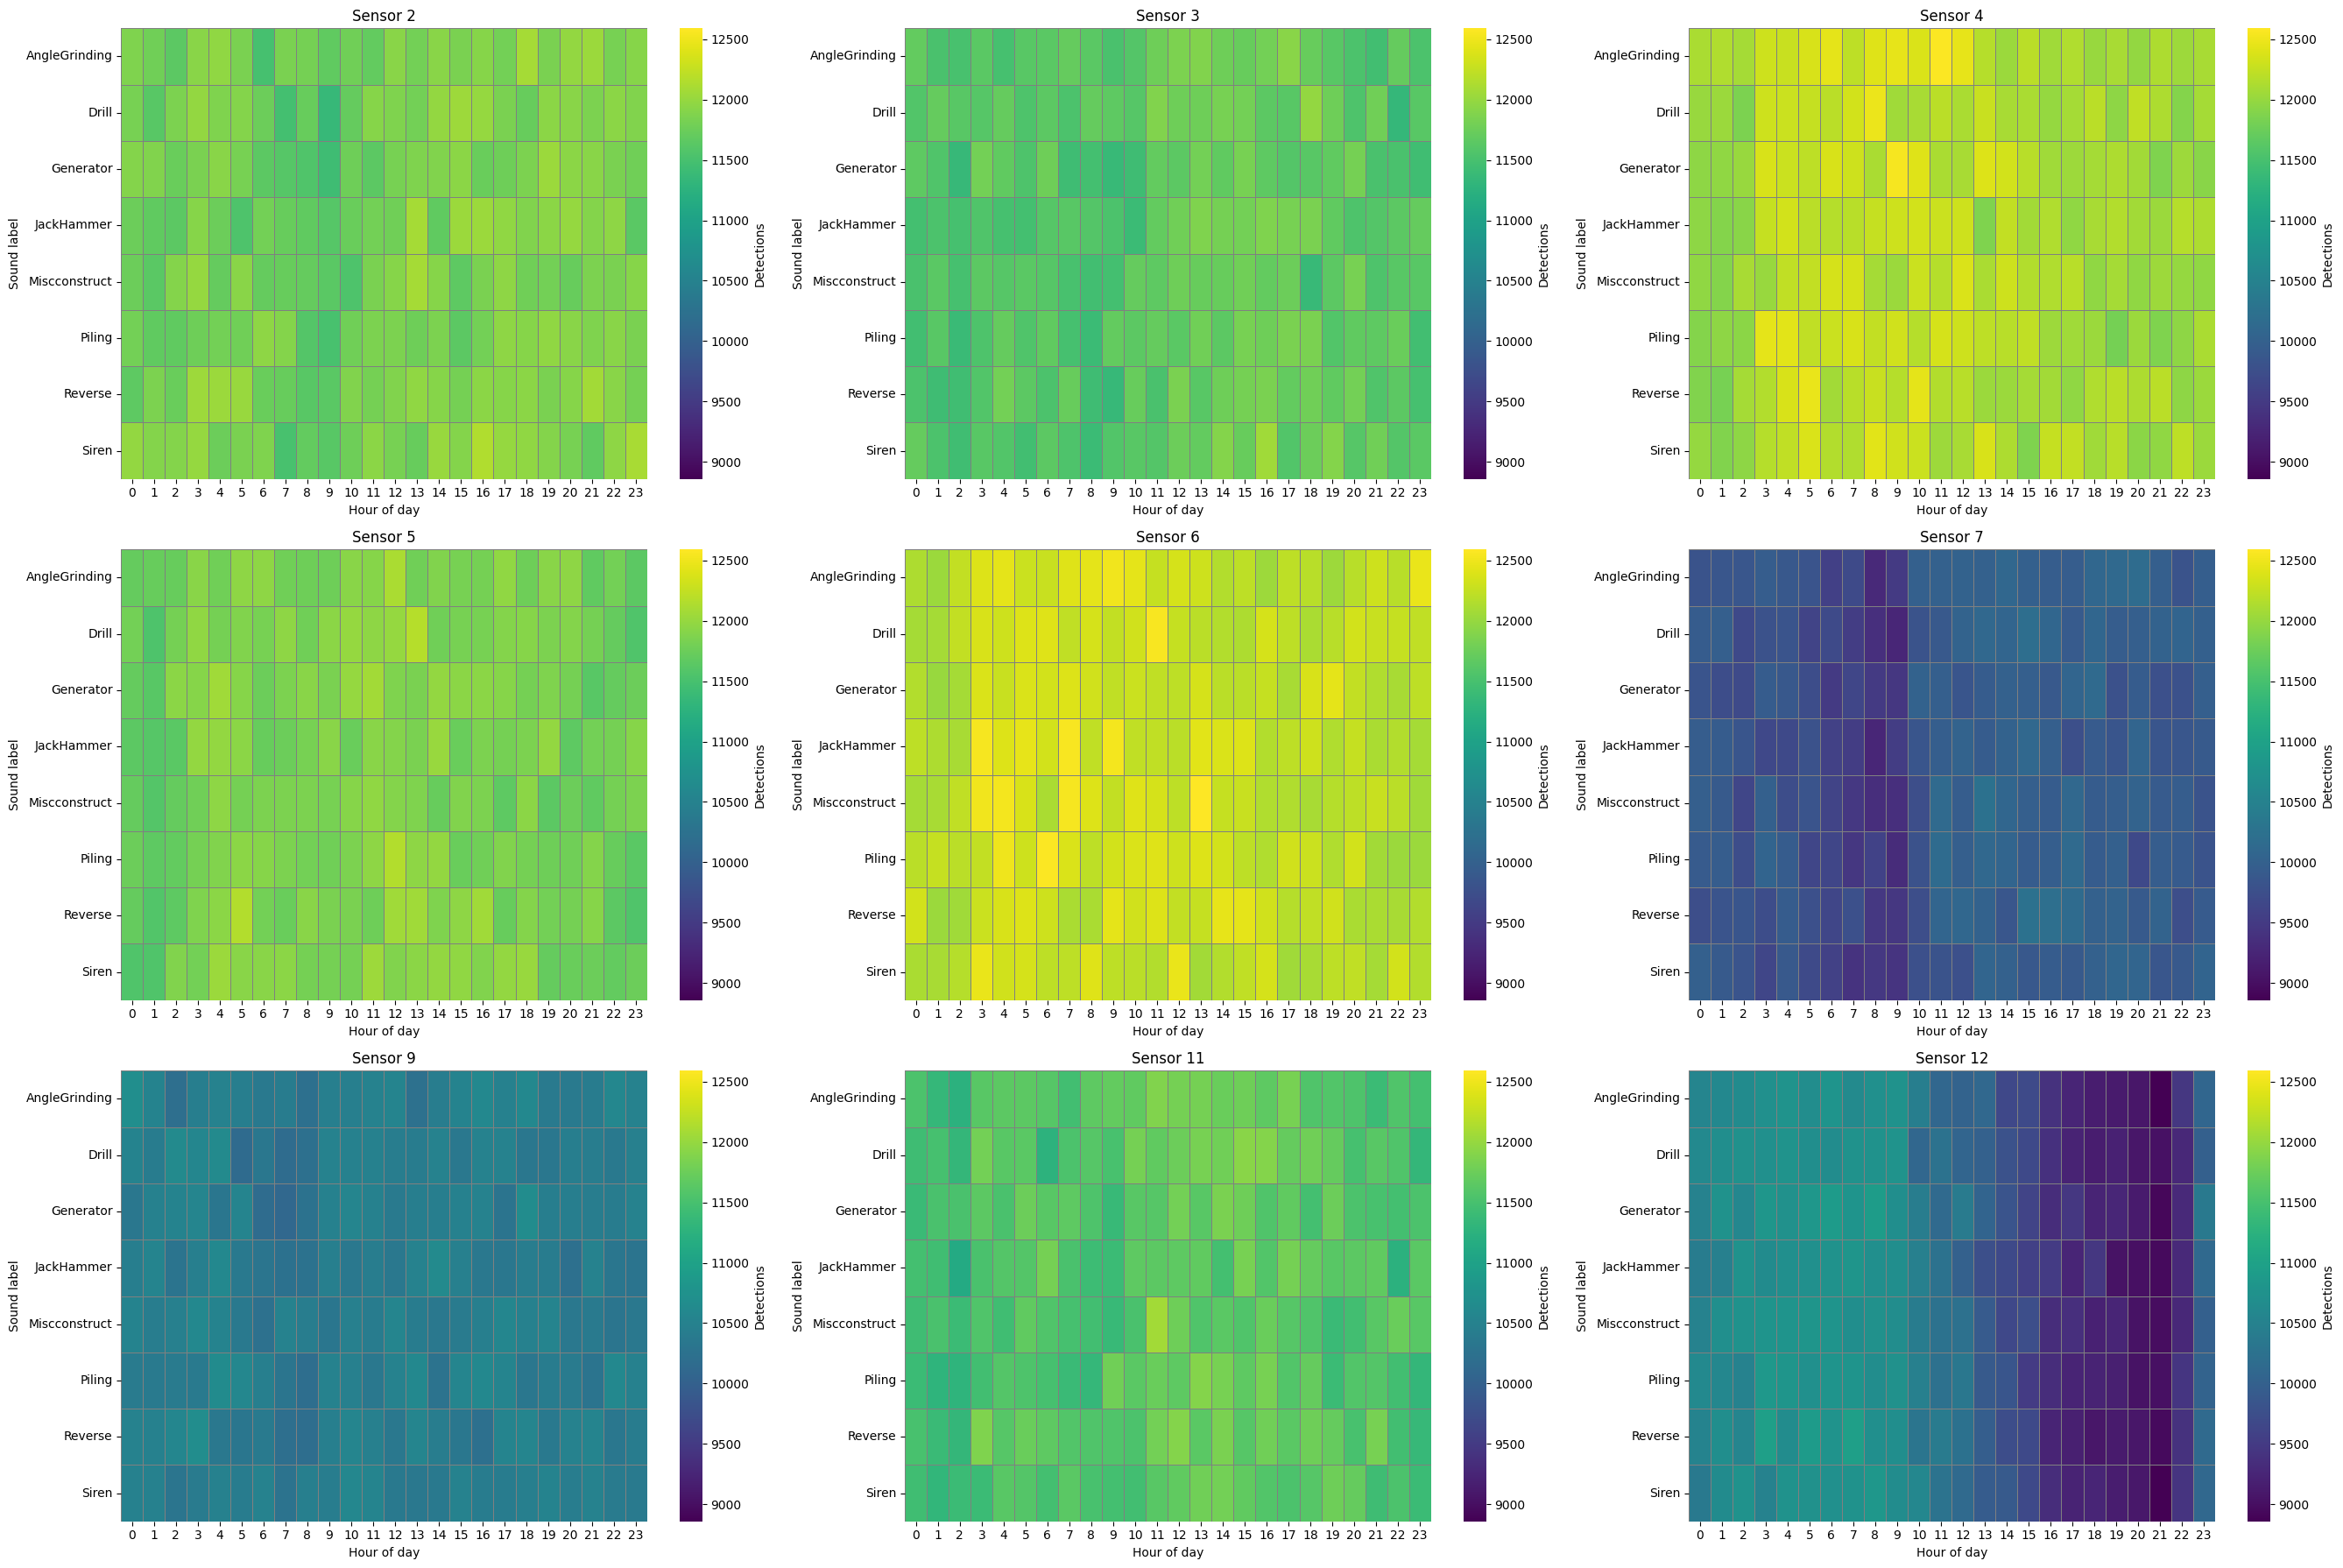

In [16]:
exclude_labels = ['silent', 'vehicle', 'human']
df_filtered = df_CityAI_sources[~df_CityAI_sources['label'].str.lower().isin(exclude_labels)]

counts = (
    df_filtered
    .groupby(['sensor', 'label', 'hour'])
    .size()
    .reset_index(name='count')
)

vmin = counts['count'].min()
vmax = counts['count'].max()

sensors = sorted(counts['sensor'].unique())
n_cols = 3
n_rows = int(np.ceil(len(sensors) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(9 * n_cols, 6 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, sensor in zip(axes, sensors):
    sensor_data = counts[counts.sensor == sensor]

    pivot = sensor_data.pivot_table(
        index='label', columns='hour', values='count',
        fill_value=0
    )
    pivot = pivot.reindex(columns=range(24), fill_value=0)

    sns.heatmap(
        pivot, ax=ax, cmap='viridis', vmin=vmin, vmax=vmax,
        cbar_kws={'label': 'Detections'},
        linewidths=0.5, linecolor='gray'
    )
    ax.set_title(f'Sensor {sensor}')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Sound label')

for ax in axes[len(sensors):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

#### Obvservations
##### Demolition
1. Drill, jackhammer and human are most important
2. Sensor 2 picks up drill far more often, while sensor 3 picks up jackhammer and humans, more, and generally picks up noise events later in the day. I need to compare with time of day analysis and resident opinion later
##### Construction
1. Humans completely outweigh the rest, especially in the evening, with drill and jackhammer picked up still very significantly. Really high number of overall detections compared to other sites (more than 25k vs 10/15k!!!)
##### Renovation
1. Human, drill and sirens are most important, although number of  detections is very low (less than 10k, max 6k for sensor 9. Points to very quiet neighbourhood.
##### Infrastructure
1. Humans and jackhammers most common, drills, sirens and anglegrinding too to an extant.

Other values measured with the noise events were the sharpness and loudness of each event. Their analysis is detailed below.

#### dBa and Sharpness

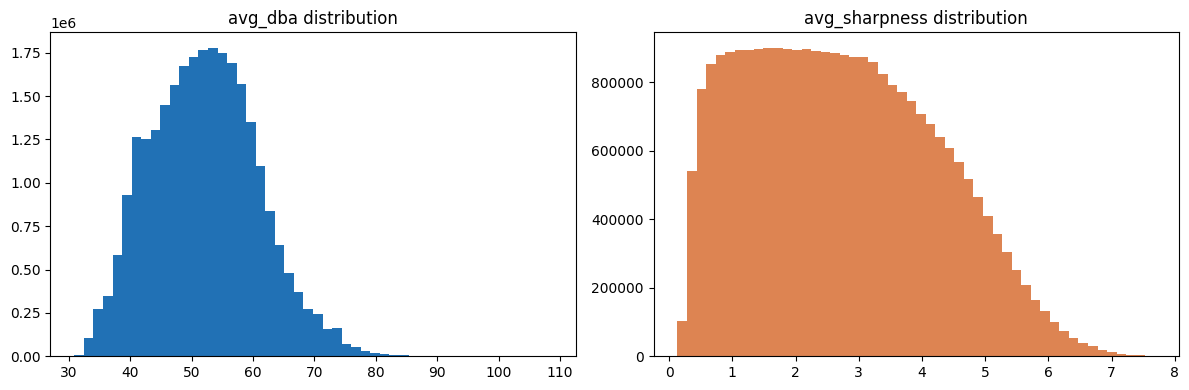

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_CityAI_sources['avg_dba'].dropna(), bins=50, color='#2171B5')
axes[0].set_title('avg_dba distribution')
axes[1].hist(df_CityAI_sources['avg_sharpness'].dropna(), bins=50, color='#DD8452')
axes[1].set_title('avg_sharpness distribution')
plt.tight_layout()
plt.show()

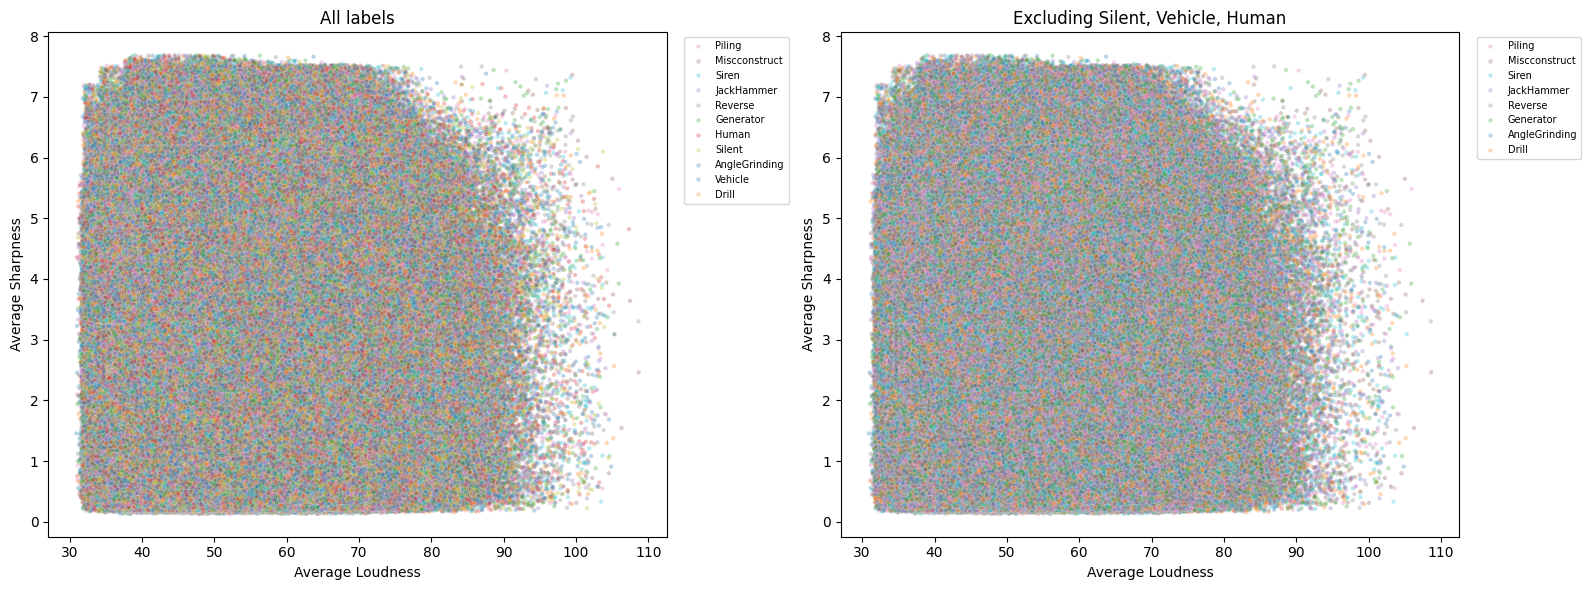

In [18]:
all_labels = sorted(df_CityAI_sources['label'].unique())
palette = dict(zip(all_labels, sns.color_palette('tab10', len(all_labels))))

df_construction_only = df_CityAI_sources[~df_CityAI_sources['label'].str.lower().isin(exclude_labels)]

def label_stats(df):
    stats = (
        df.groupby('label')
        .agg(count=('avg_spl_a', 'count'), mean_linear=('avg_spl_a', 'mean'), mean_sharpness=('avg_sharpness', 'mean'))
        .reset_index()
    )
    stats['avg_dba'] = 10 * np.log10(stats['mean_linear'])
    return stats

stats_all = label_stats(df_CityAI_sources)
stats_construction = label_stats(df_construction_only)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_CityAI_sources, x='avg_dba', y='avg_sharpness', hue='label',
                 palette=palette, alpha=0.3, s=10, ax=axes[0])
axes[0].set_title('All labels')
axes[0].set_xlabel('Average Loudness')
axes[0].set_ylabel('Average Sharpness')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

sns.scatterplot(data=df_construction_only, x='avg_dba', y='avg_sharpness', hue='label',
                 palette=palette, alpha=0.3, s=10, ax=axes[1])
axes[1].set_title('Excluding Silent, Vehicle, Human')
axes[1].set_xlabel('Average Loudness')
axes[1].set_ylabel('Average Sharpness')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

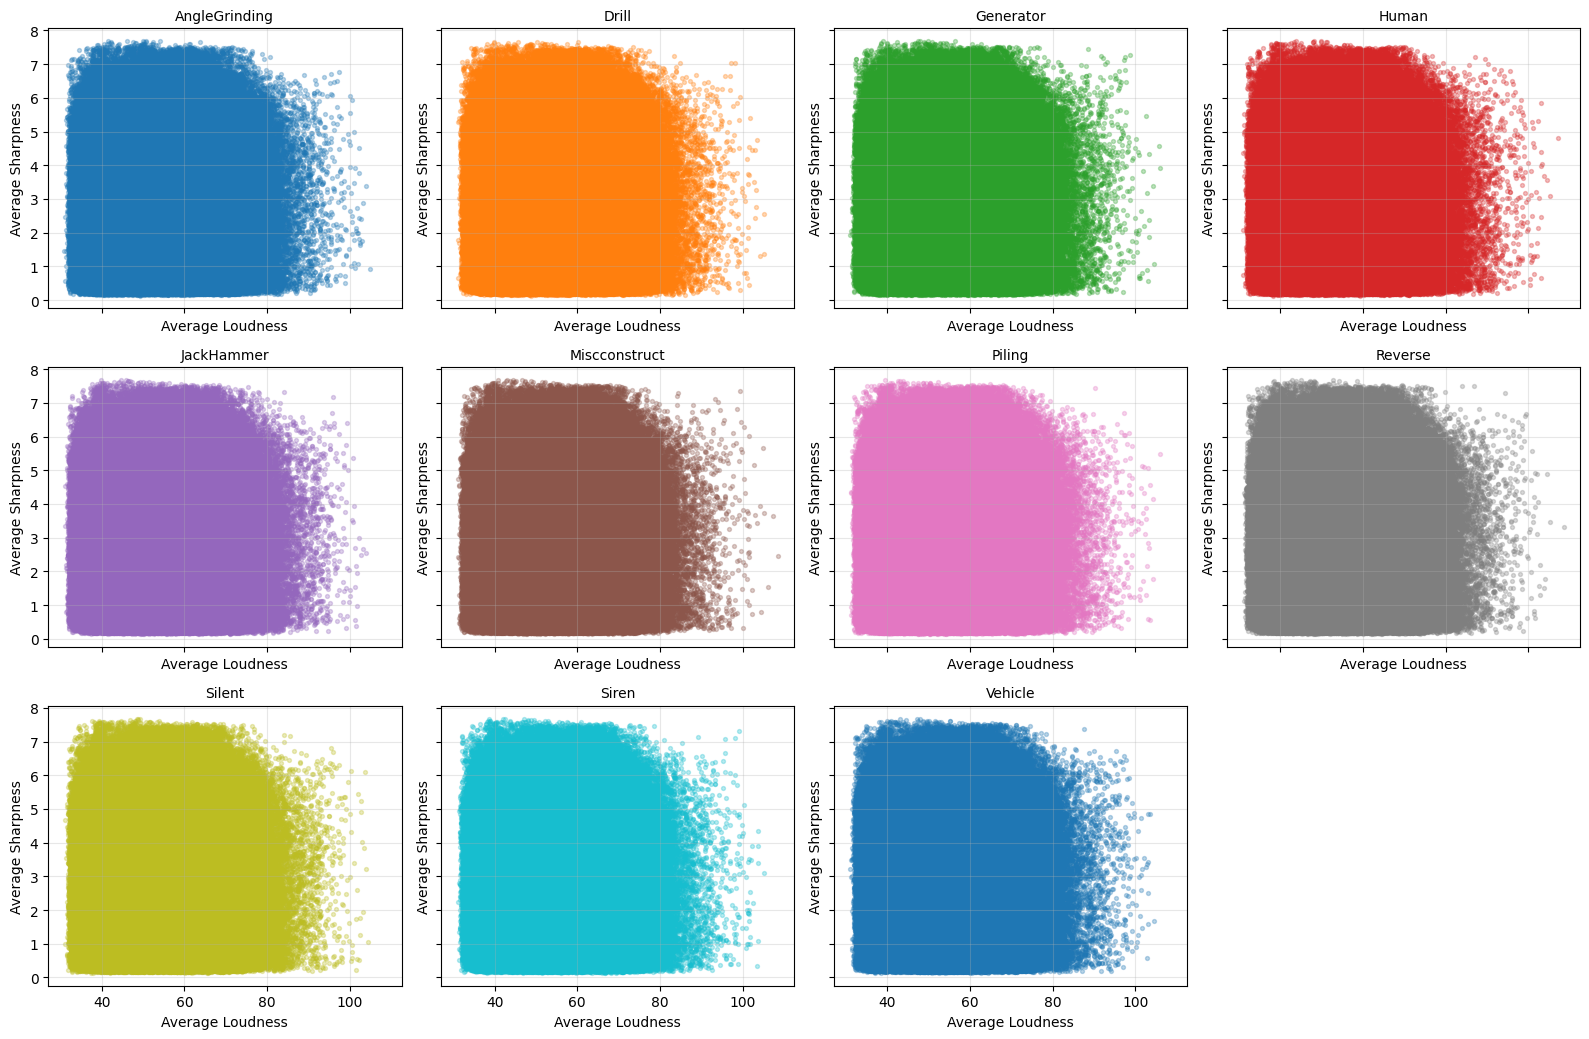

In [19]:
n_cols = 4
n_rows = int(np.ceil(len(all_labels) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, label in zip(axes, all_labels):
    label_data = df_CityAI_sources[df_CityAI_sources['label'] == label]
    ax.scatter(
        label_data['avg_dba'], label_data['avg_sharpness'],
        color=palette[label], alpha=0.3, s=8
    )
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Average Loudness')
    ax.set_ylabel('Average Sharpness')
    ax.grid(alpha=0.3)

for ax in axes[len(all_labels):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

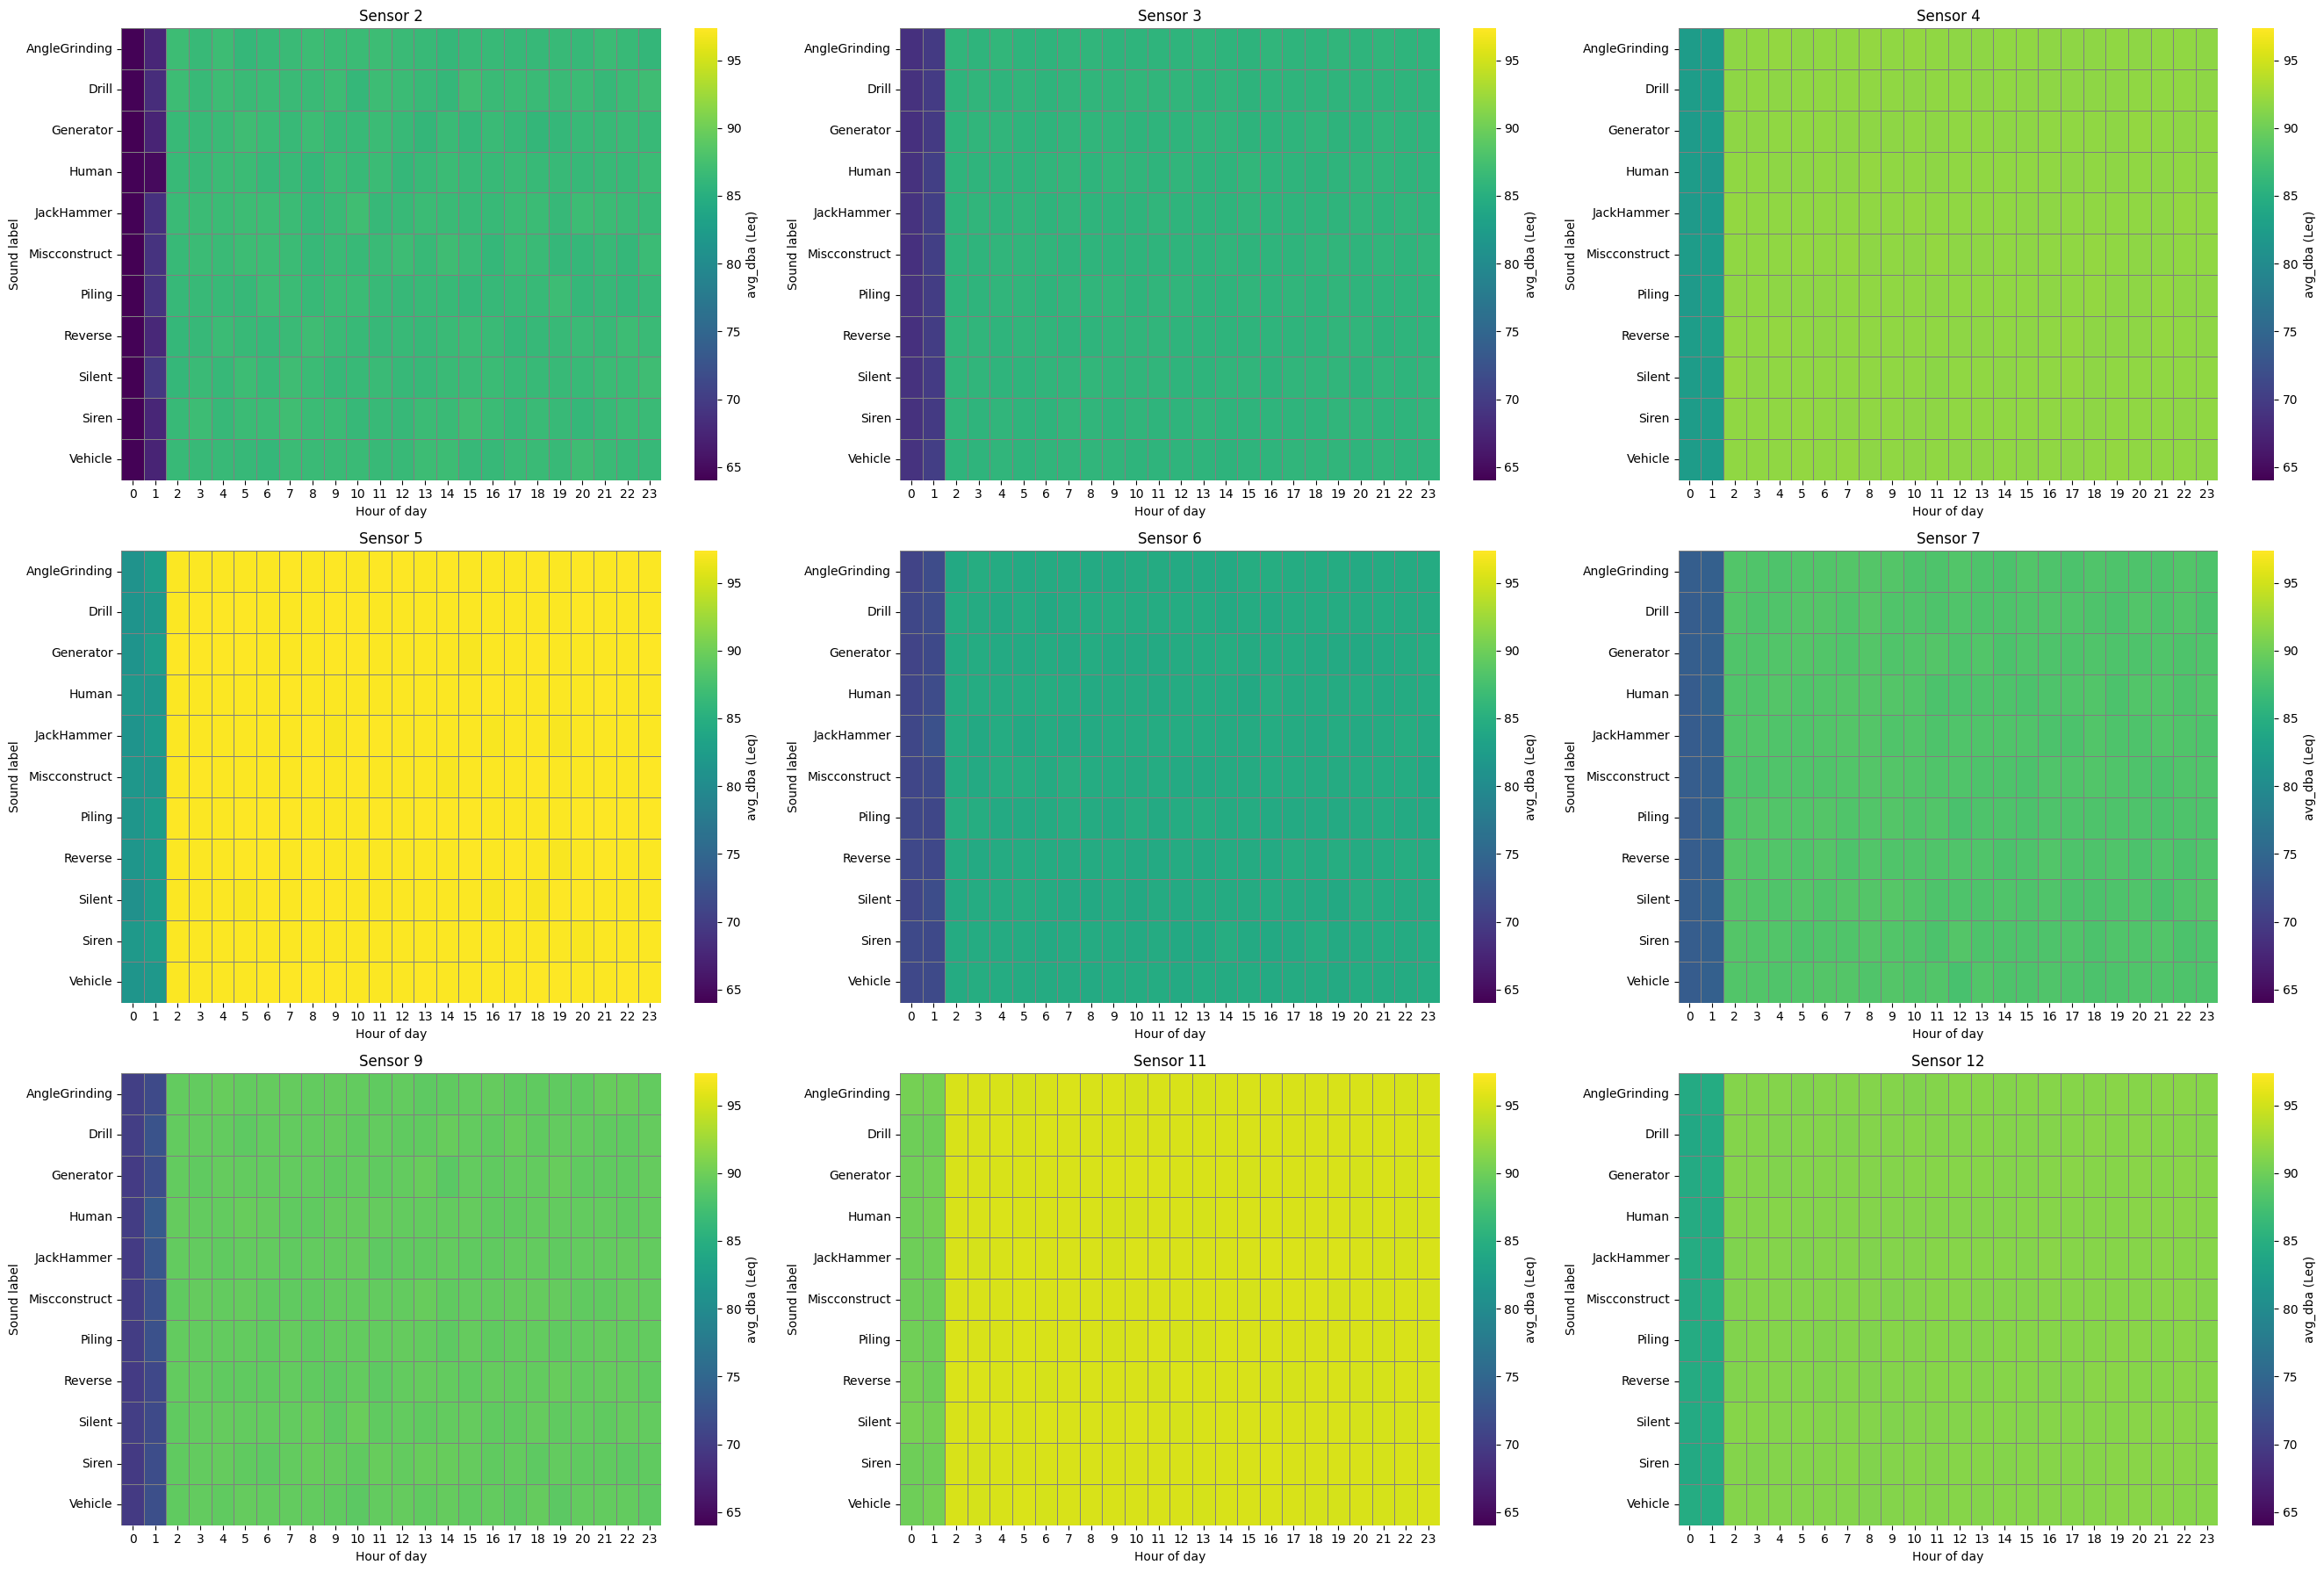

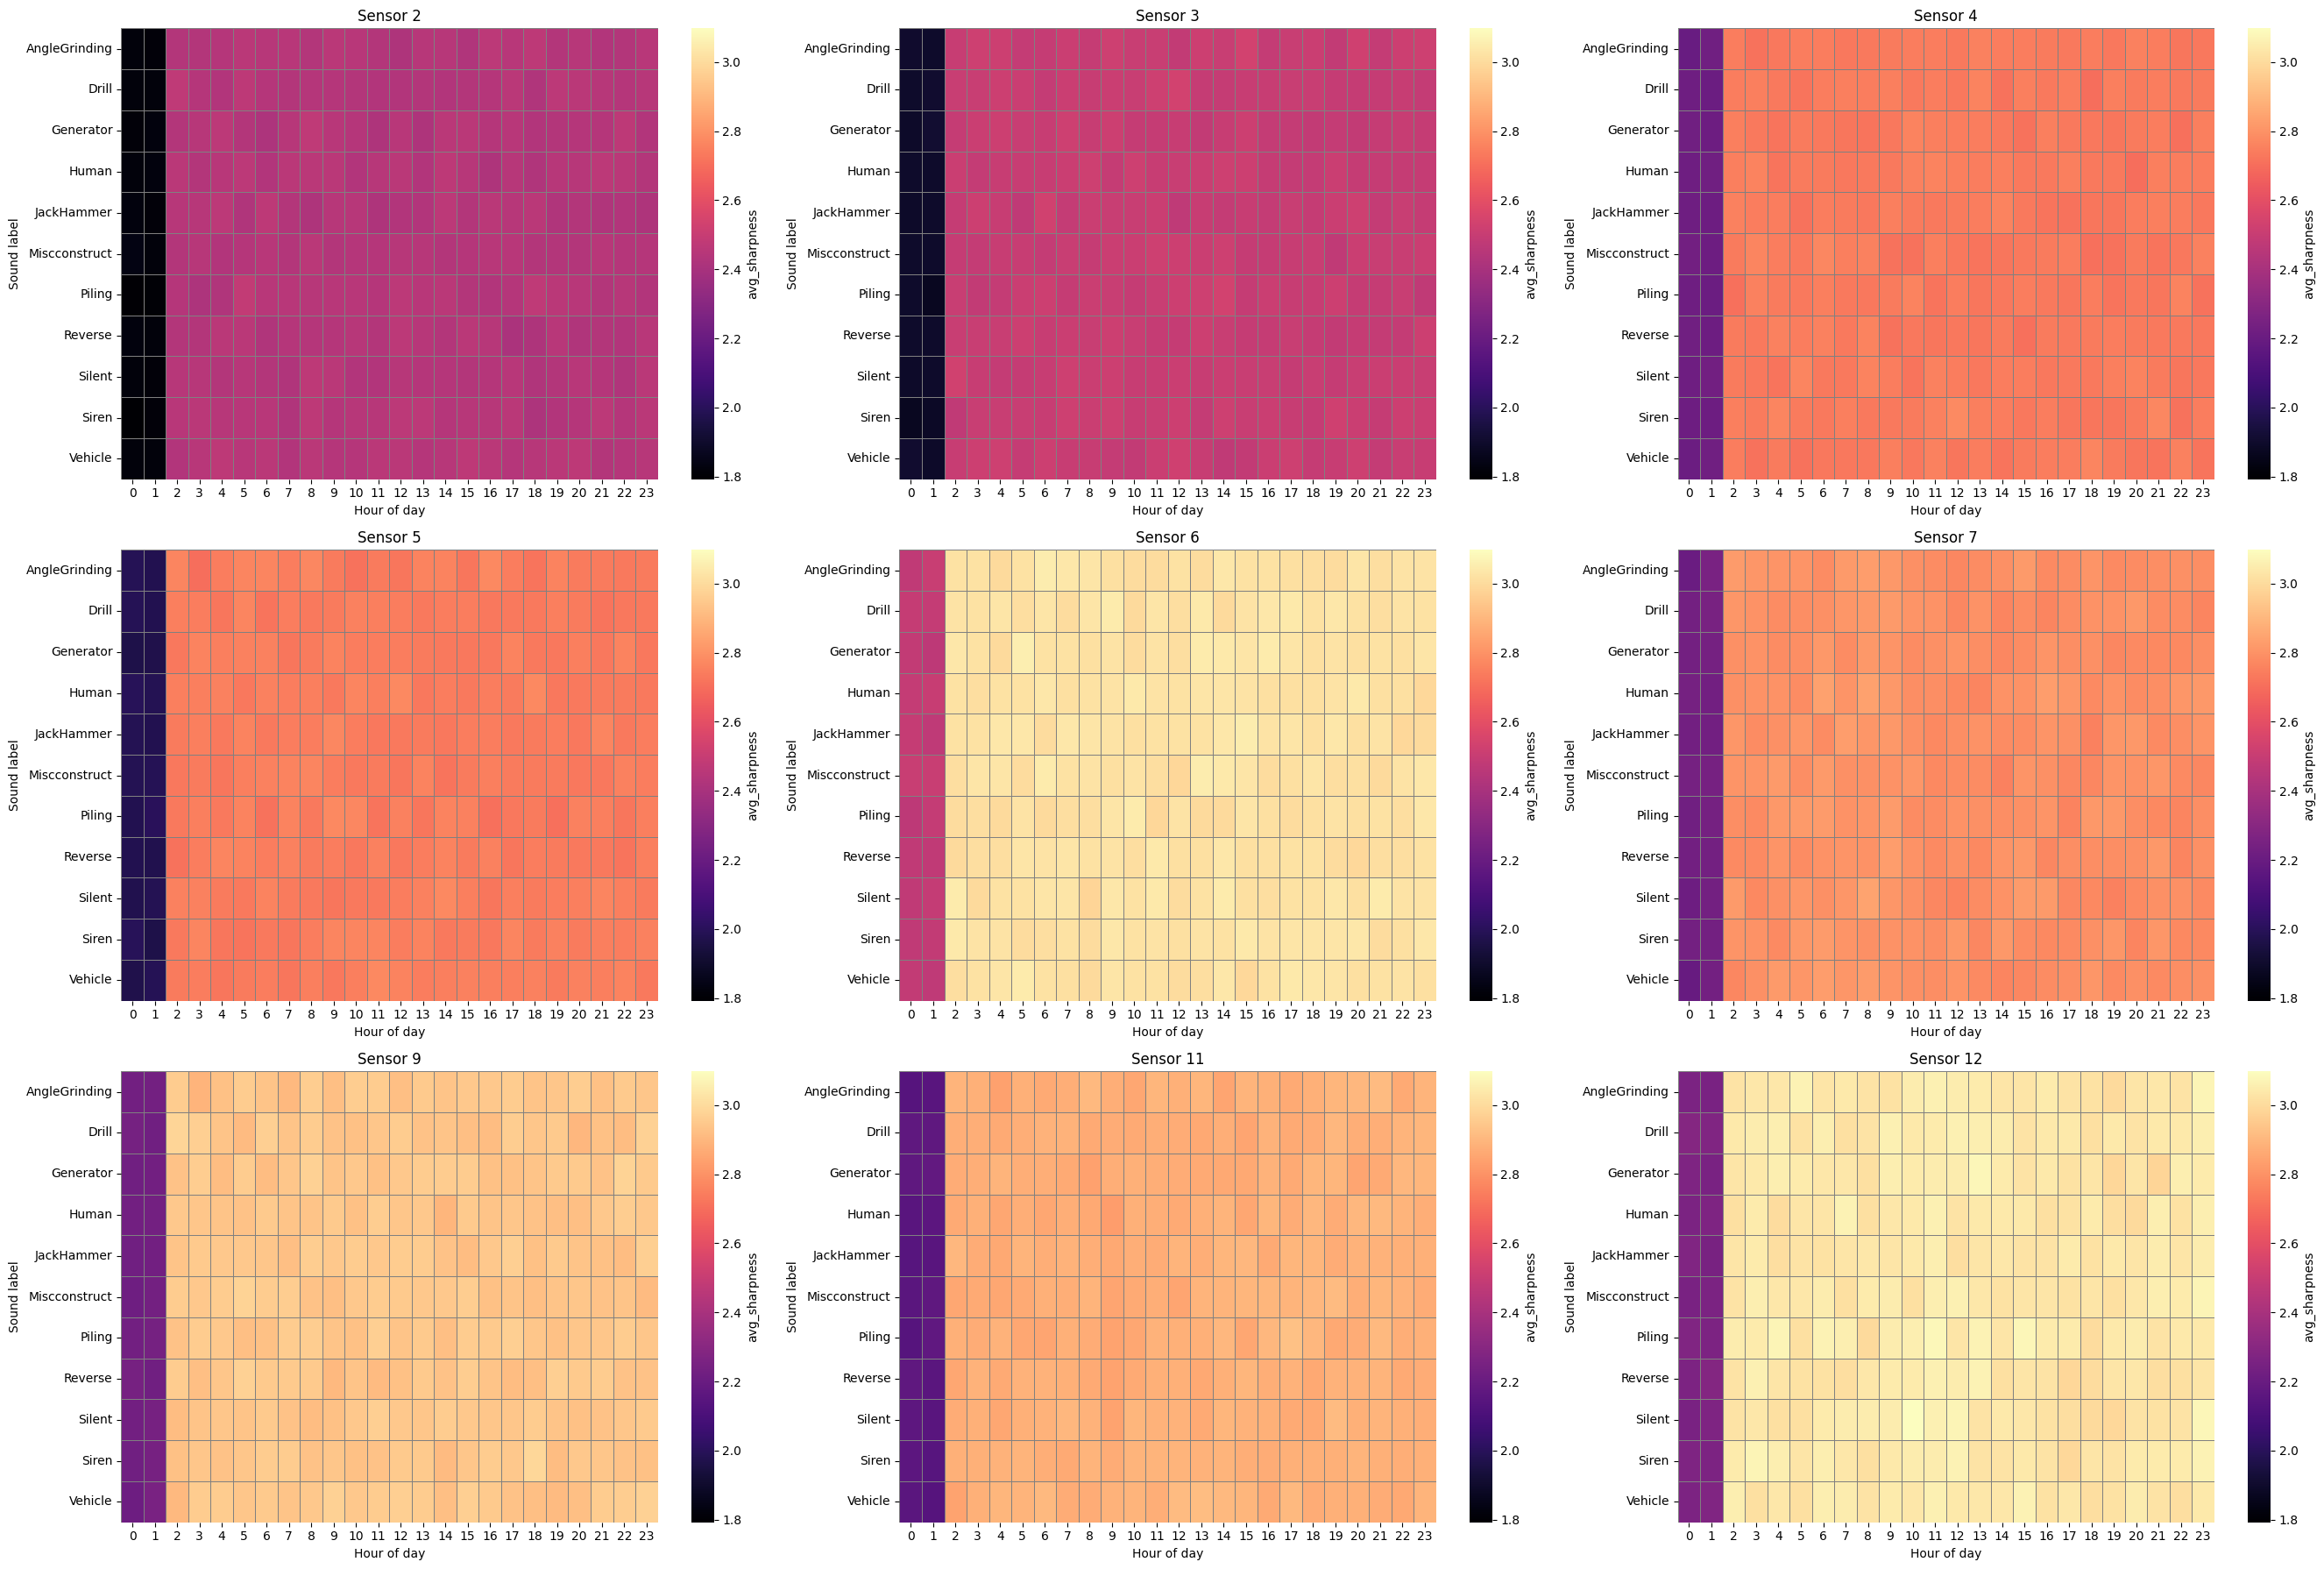

In [20]:
df_filtered = df_CityAI_sources

for metric, cmap in [('avg_spl_a', 'viridis'), ('avg_sharpness', 'magma')]:
    pivot_data = (
        df_filtered.groupby(['sensor', 'label', 'hour'])[metric]
        .mean()
        .reset_index()
    )

    if metric == 'avg_spl_a':
        pivot_data['value'] = 10 * np.log10(pivot_data[metric])
        label_name = 'avg_dba (Leq)'
    else:
        pivot_data['value'] = pivot_data[metric]
        label_name = metric

    vmin = pivot_data['value'].min()
    vmax = pivot_data['value'].max()

    sensors = sorted(pivot_data['sensor'].unique())
    n_cols = 3
    n_rows = int(np.ceil(len(sensors) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(9 * n_cols, 6 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, sensor in zip(axes, sensors):
        sensor_data = pivot_data[pivot_data.sensor == sensor]
        pivot = sensor_data.pivot_table(index='label', columns='hour', values='value')
        pivot = pivot.reindex(columns=range(24))

        sns.heatmap(
            pivot, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
            cbar_kws={'label': label_name}, linewidths=0.5, linecolor='gray'
        )
        ax.set_title(f'Sensor {sensor}')
        ax.set_xlabel('Hour of day')
        ax.set_ylabel('Sound label')

    for ax in axes[len(sensors):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

#### Observations

##### Loudness

1. Angle grinding is loud at about the times you'd think - midday.
2. Sensors 4 and 5 pick up sirens as really loud, but not 6 for some reason.

##### Sharpness

1. Angle Grinding is super sharp. Probably too sharp and throughout night, shows it's probably not very good.
2. Some things are missing data on sharpness, particularly generator and misconstruct
3. Siren and Angle Grinding are loudest on average. Sensors 2 and 3 have a wildly different profile somehow,
4. Sensor 12 has a lot of angle grinding in the morning?

In [21]:
event_by_label = (
    df_CityAI_sources.groupby('label')
    .agg(mean_linear=('avg_spl_a', 'mean'), n=('avg_spl_a', 'count'))
    .reset_index()
)
event_by_label['event_dba'] = 10 * np.log10(event_by_label['mean_linear'])

stream_overall_dba = 10 * np.log10(df_CityAI[df_CityAI.sensor != 10]['avg_spla'].mean())

event_by_label['stream_overall_dba'] = stream_overall_dba
event_by_label['difference_db'] = event_by_label['event_dba'] - stream_overall_dba

print(event_by_label[['label', 'n', 'event_dba', 'stream_overall_dba', 'difference_db']].sort_values('event_dba', ascending=False).to_string())

            label        n  event_dba  stream_overall_dba  difference_db
2       Generator  2439354  91.698111           72.193076      19.505035
6          Piling  2439059  91.691835           72.193076      19.498759
0   AngleGrinding  2443664  91.690735           72.193076      19.497659
4      JackHammer  2436649  91.685776           72.193076      19.492700
1           Drill  2441070  91.685756           72.193076      19.492679
8          Silent  2438828  91.685643           72.193076      19.492567
7         Reverse  2441333  91.684048           72.193076      19.490972
10        Vehicle  2438797  91.683725           72.193076      19.490649
3           Human  2441336  91.682510           72.193076      19.489433
9           Siren  2438664  91.682355           72.193076      19.489279
5   Miscconstruct  2437542  91.682146           72.193076      19.489070


#### Observation
1. All are above average, except silent. This makes sense, since values below 55 are categorised as silent, so it skews it up naturally (events that aren't loud are just kicked out).
2. The most interesting here is AngleGrinding being super loud. Checks out with sharpness found later. This is despite it being very uncommon.
3. Siren is both quite common and loud as well, but makes sense.
4. Drilling was over-picked up as we can see from the crazy high n (over 100k above the next biggest construction noise) and from the temporal patterns as it showed up after 5pm or whatever. Yet it's not super loud. Suggests maybe a lot of random noise was picked up.

#### Analysis by Week

In [23]:
df_CityAI_sources['time'] = pd.to_datetime(df_CityAI_sources['time'])
df_CityAI_sources['hour'] = df_CityAI_sources['time'].dt.hour
df_CityAI_sources['day_of_week'] = df_CityAI_sources['time'].dt.day_name()

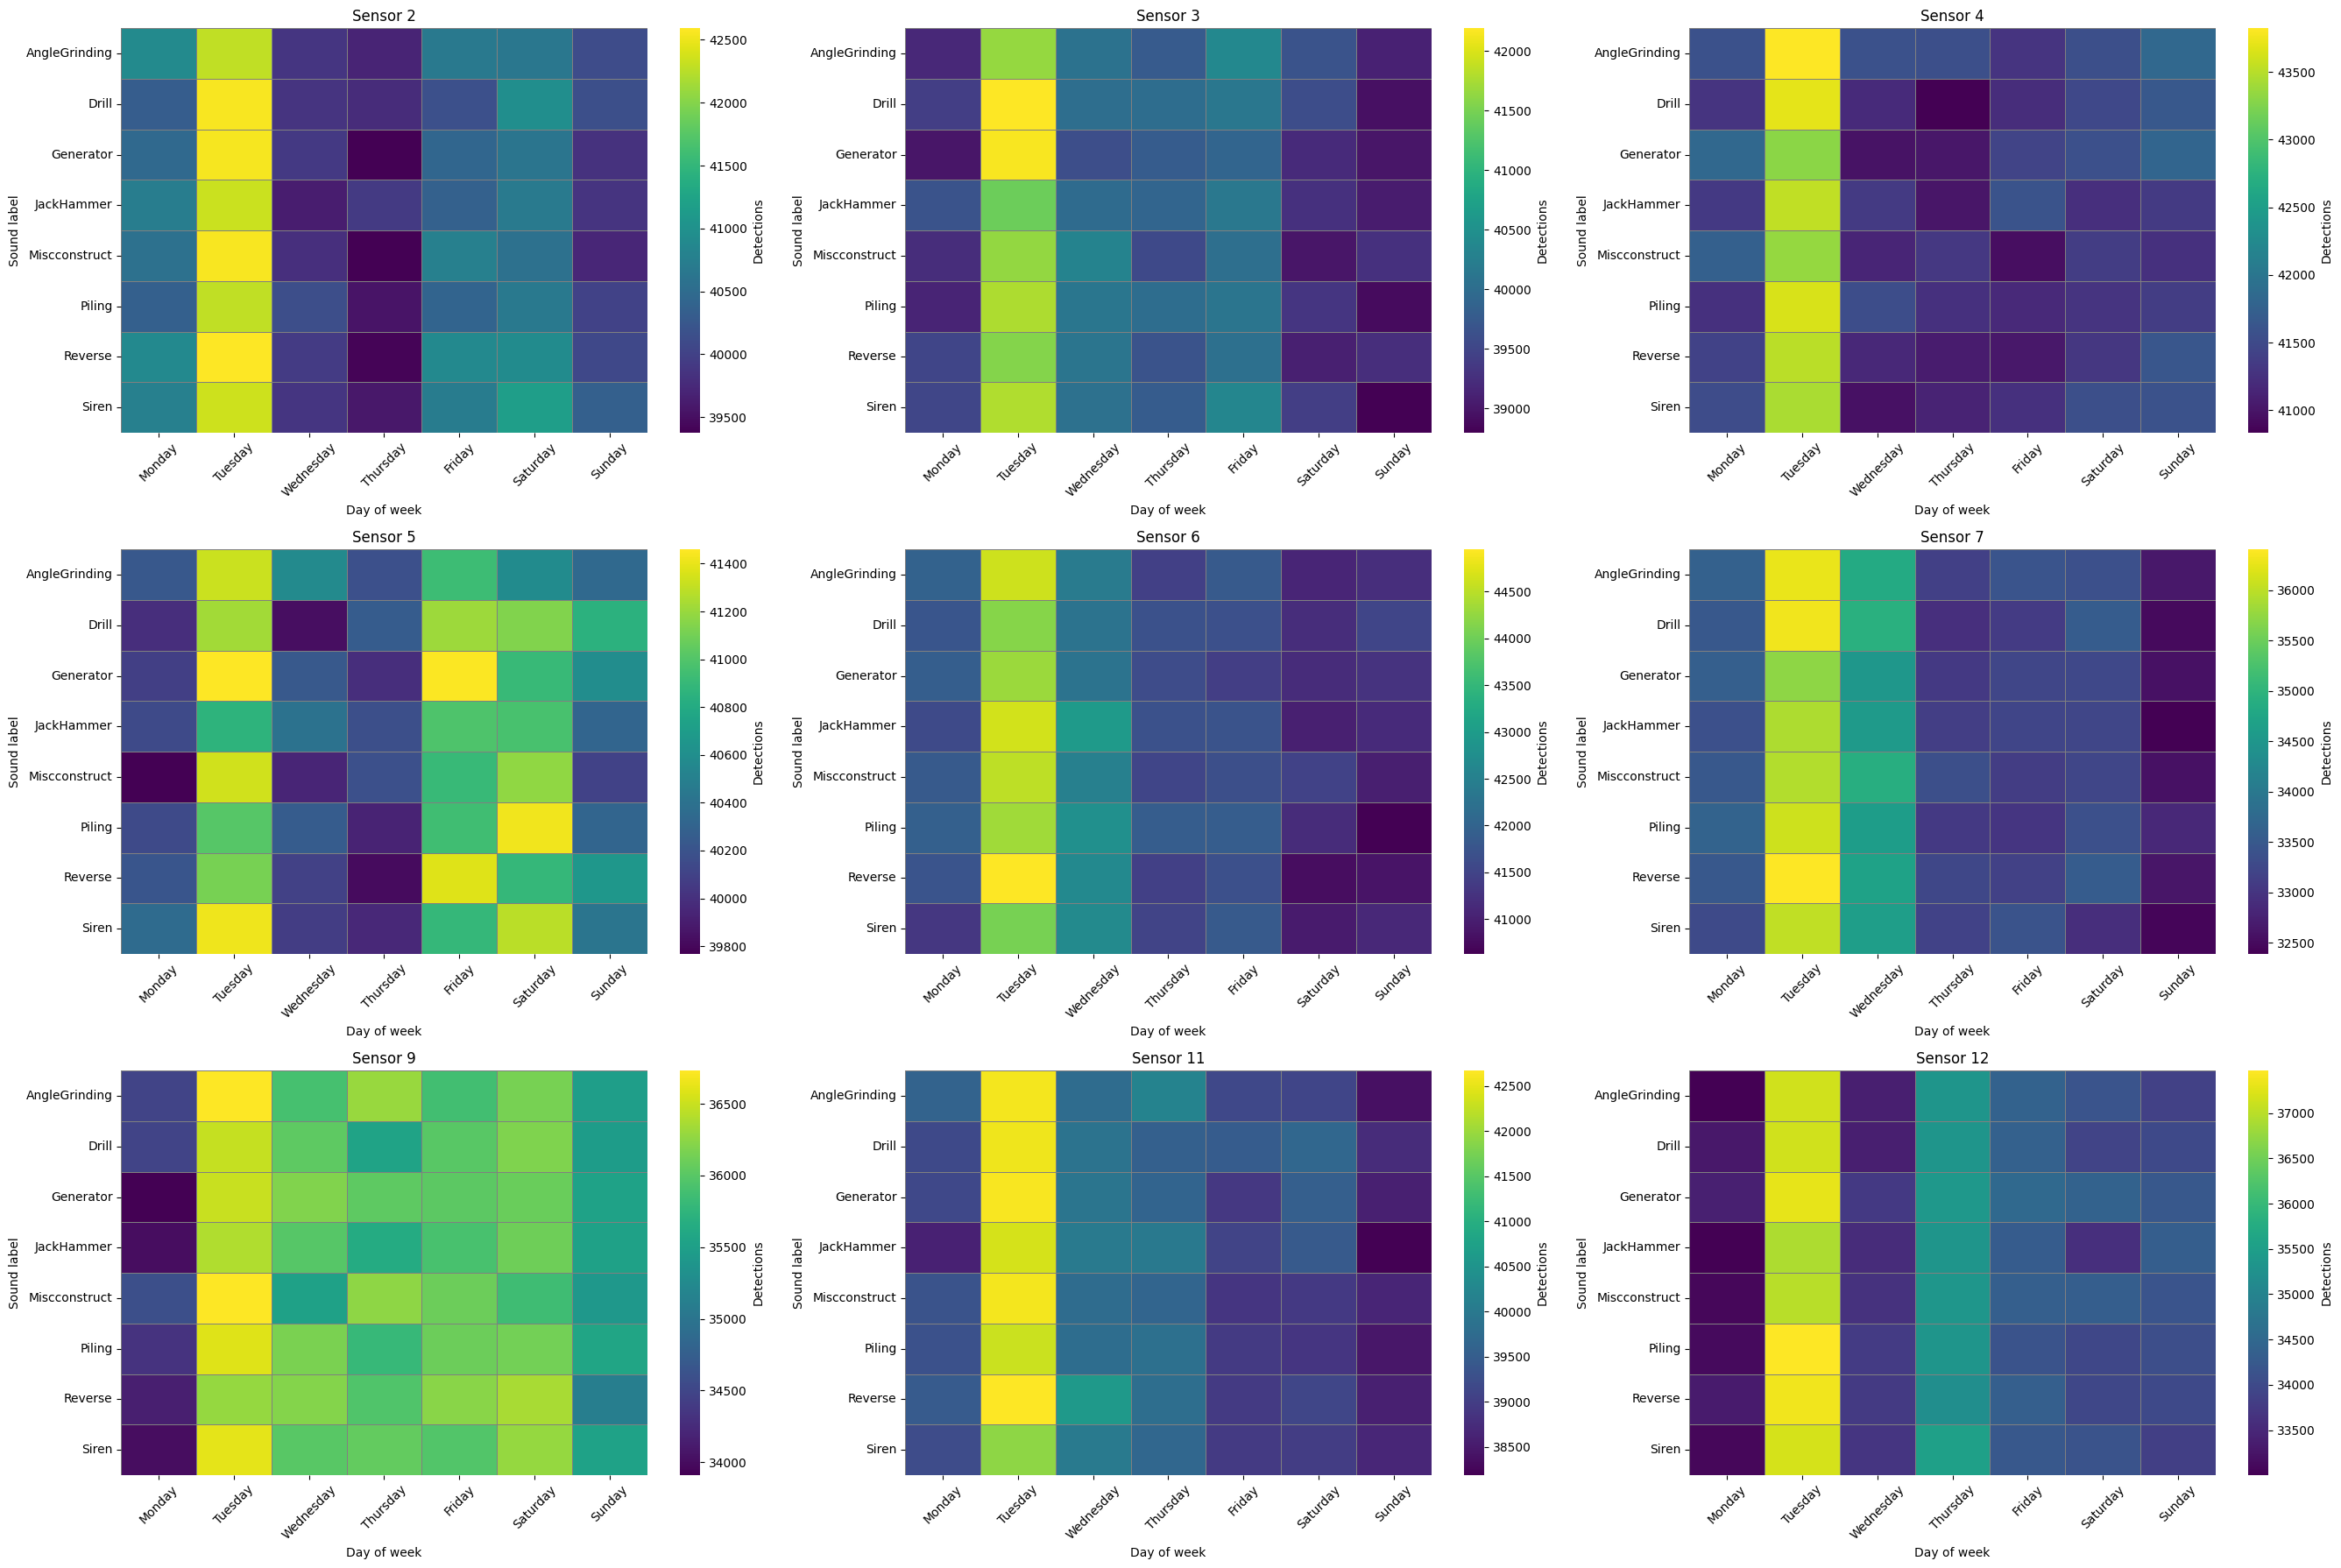

In [24]:
exclude_labels = ['silent', 'vehicle', 'human', 'vehicles']
df_filtered = df_CityAI_sources[~df_CityAI_sources['label'].str.lower().isin(exclude_labels)]

counts = (
    df_filtered
    .groupby(['sensor', 'label', 'day_of_week'])
    .size()
    .reset_index(name='count')
)

sensors = sorted(counts['sensor'].unique())
n_cols = 3
n_rows = int(np.ceil(len(sensors) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(9 * n_cols, 6 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, sensor in zip(axes, sensors):
    sensor_data = counts[counts.sensor == sensor]

    pivot = sensor_data.pivot_table(
        index='label', columns='day_of_week', values='count',
        fill_value=0
    )
    pivot = pivot.reindex(columns=day_order, fill_value=0)

    sns.heatmap(
        pivot, ax=ax, cmap='viridis', cbar_kws={'label': 'Detections'},
        linewidths=0.5, linecolor='gray'
    )
    ax.set_title(f'Sensor {sensor}')
    ax.set_xlabel('Day of week')
    ax.set_ylabel('Sound label')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(sensors):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

#### Observations
##### Demolition
1. More events during week, less on weekends.
2. Interestingly, human, drill and jackhammer do get detected on weekends, while other noises like piling and reverse do not, suggesting the device is maybe a bit too sensitive to some construction noises than others.
##### Construction
1. Human noise again dominates
2. Most construction noise is less present on weekdays
3. Need to study without human noise because total events are super numerous
##### Renovation
1. Same pattern as others, human noise dominates, construction noise less picked up on during weekends, but sirens are more prevalent
##### Infrastructure
1. Human and Jackhammer totally dominate even on weekends, with a slight reduction of jackhammer on weekend. Seems the machine might be getting confused on jackhammer, which could explain why it's so prevalent across all compared to others. I'd need to find a study on what noises in construction are most common and loud.

#### Further Analysis

As detailed in the thesis, some strange patterns identified were further analysed with the available noise event data. They are presented here.

##### Sensor 2 11am - 1pm dip

In [25]:
def get_period(hour):
    if 11 <= hour < 13:
        return 'window_11_13'
    elif 7 <= hour < 16:
        return 'daytime_rest'
    else:
        return 'other'

df_CityAI_sources['period'] = df_CityAI_sources['hour'].apply(get_period)

sensor_data = df_CityAI_sources[
    (df_CityAI_sources['sensor'].isin([2, 3])) &
    (df_CityAI_sources['period'].isin(['window_11_13', 'daytime_rest']))
].copy()

construction_labels = ['Drill', 'JackHammer', 'Piling', 'AngleGrinding', 'Generator', 'Reverse', 'Miscconstruct']

totals = (
    sensor_data.groupby(['sensor', 'period'])
    .size()
    .reset_index(name='total_events')
)

all_results = []

for label_name, condition in [
    ('Silent', lambda d: d['label'] == 'Silent'),
    ('Human', lambda d: d['label'] == 'Human'),
    ('Vehicle', lambda d: d['label'] == 'Vehicle'),
    ('Construction', lambda d: d['label'].isin(construction_labels)),
]:
    subset = sensor_data[condition(sensor_data)]

    stats = (
        subset.groupby(['sensor', 'period'])
        .agg(count=('avg_spl_a', 'count'), mean_linear=('avg_spl_a', 'mean'), mean_sharpness=('avg_sharpness', 'mean'))
        .reset_index()
    )
    stats['avg_dba'] = 10 * np.log10(stats['mean_linear'])
    stats['label'] = label_name

    result = pd.merge(totals, stats, on=['sensor', 'period'], how='left')
    result['pct_of_total'] = result['count'] / result['total_events'] * 100
    all_results.append(result)

combined_results = pd.concat(all_results, ignore_index=True)

summary_table = combined_results.pivot_table(
    index=['sensor', 'label'],
    columns='period',
    values='pct_of_total'
).round(1)
summary_table = summary_table[['window_11_13', 'daytime_rest']]

summary_table

period               window_11_13  daytime_rest
sensor label                                   
2      Construction          63.5          63.6
       Human                  9.1           9.1
       Silent                 9.0           9.1
       Vehicle                9.2           9.1
3      Construction          63.6          63.6
       Human                  9.2           9.1
       Silent                 9.1           9.1
       Vehicle                9.1           9.1

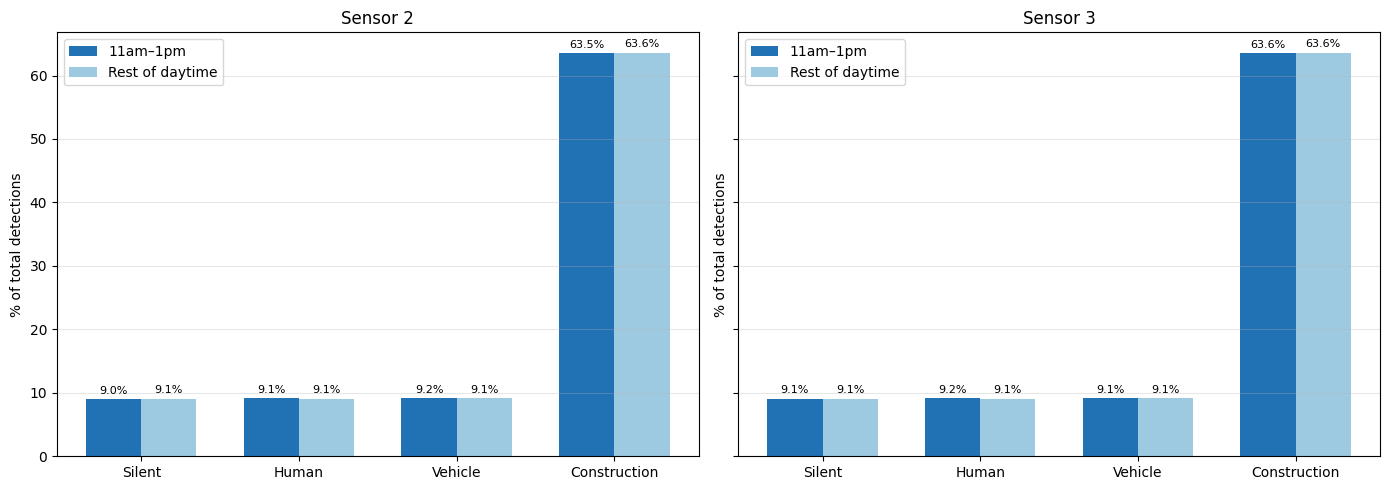

In [26]:
label_order = ['Silent', 'Human', 'Vehicle', 'Construction']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, sensor in zip(axes, [2, 3]):
    sensor_results = combined_results[combined_results.sensor == sensor]
    x = np.arange(len(label_order))
    width = 0.35

    window_vals = [sensor_results[(sensor_results.label == l) & (sensor_results.period == 'window_11_13')]['pct_of_total'].values[0] for l in label_order]
    rest_vals = [sensor_results[(sensor_results.label == l) & (sensor_results.period == 'daytime_rest')]['pct_of_total'].values[0] for l in label_order]

    bars1 = ax.bar(x - width/2, window_vals, width, label='11am\u20131pm', color='#2171B5')
    bars2 = ax.bar(x + width/2, rest_vals, width, label='Rest of daytime', color='#9ECAE1')

    for bar, val in zip(bars1, window_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', va='bottom', color='black', fontsize=8)
    for bar, val in zip(bars2, rest_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', va='bottom', color='black', fontsize=8)

    ax.set_title(f'Sensor {sensor}')
    ax.set_xticks(x)
    ax.set_xticklabels(label_order)
    ax.set_ylabel('% of total detections')
    ax.legend()
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Sensor 6 Tuesday peak

In [27]:
sensor6_data = df_CityAI_sources[df_CityAI_sources['sensor'] == 6].copy()

sensor6_data['is_tuesday'] = sensor6_data['day_of_week'] == 'Tuesday'

label_breakdown = (
    sensor6_data.groupby(['is_tuesday', 'label'])
    .agg(count=('avg_spl_a', 'count'), mean_linear=('avg_spl_a', 'mean'))
    .reset_index()
)
label_breakdown['avg_dba'] = 10 * np.log10(label_breakdown['mean_linear'])

label_breakdown['pct_of_group_total'] = label_breakdown.groupby('is_tuesday')['count'].transform(lambda x: x / x.sum() * 100)

print("Label breakdown, Sensor 6: Tuesday vs other days:")
print(label_breakdown[['is_tuesday', 'label', 'count', 'pct_of_group_total', 'avg_dba']].sort_values(['is_tuesday', 'count'], ascending=[True, False]).to_string())

by_day = (
    sensor6_data.groupby(['day_of_week', 'label'])
    .agg(count=('avg_spl_a', 'count'), mean_linear=('avg_spl_a', 'mean'))
    .reset_index()
)
by_day['avg_dba'] = 10 * np.log10(by_day['mean_linear'])
by_day['day_of_week'] = pd.Categorical(by_day['day_of_week'], categories=day_order, ordered=True)

pivot_count = by_day.pivot_table(index='label', columns='day_of_week', values='count', fill_value=0)
print("\nFull day-of-week detection counts by label, Sensor 6:")
print(pivot_count.to_string())

pivot_dba = by_day.pivot_table(index='label', columns='day_of_week', values='avg_dba')
print("\nFull day-of-week avg dBA by label, Sensor 6:")
print(pivot_dba.to_string())

Label breakdown, Sensor 6: Tuesday vs other days:
    is_tuesday          label   count  pct_of_group_total    avg_dba
6        False         Piling  250289            9.104603  82.119401
8        False         Silent  250274            9.104057  82.132257
1        False          Drill  250139            9.099147  82.105739
4        False     JackHammer  250138            9.099110  82.098501
3        False          Human  250123            9.098565  82.117203
10       False        Vehicle  250009            9.094418  82.117710
5        False  Miscconstruct  249982            9.093436  82.127670
0        False  AngleGrinding  249930            9.091544  82.133343
2        False      Generator  249617            9.080158  82.122824
9        False          Siren  249378            9.071464  82.111374
7        False        Reverse  249159            9.063498  82.139567
18        True        Reverse   44951            9.215198  88.834172
15        True     JackHammer   44655            9.15

In [28]:
df_CityAI_sources['is_tuesday'] = df_CityAI_sources['day_of_week'] == 'Tuesday'
df_CityAI_sources['is_day'] = df_CityAI_sources['hour'].between(7, 18)

sensor6_data = df_CityAI_sources[df_CityAI_sources['sensor'] == 6].copy()

totals = (
    sensor6_data.groupby(['is_tuesday', 'is_day'])
    .size()
    .reset_index(name='total_events')
)

grouped = (
    sensor6_data.groupby(['is_tuesday', 'is_day', 'label'])
    .agg(count=('avg_spl_a', 'count'), mean_linear=('avg_spl_a', 'mean'), mean_sharpness=('avg_sharpness', 'mean'))
    .reset_index()
)
grouped['avg_dba'] = 10 * np.log10(grouped['mean_linear'])

result = pd.merge(grouped, totals, on=['is_tuesday', 'is_day'])
result['pct_of_total'] = result['count'] / result['total_events'] * 100

print(result[['is_tuesday', 'is_day', 'label', 'count', 'pct_of_total', 'avg_dba', 'mean_sharpness']]
      .sort_values(['is_day', 'is_tuesday', 'pct_of_total'], ascending=[False, True, False])
      .to_string())

    is_tuesday  is_day          label   count  pct_of_total    avg_dba  mean_sharpness
19       False    True         Silent  125823      9.130723  82.486608        3.030331
15       False    True     JackHammer  125457      9.104163  82.465709        3.034778
16       False    True  Miscconstruct  125431      9.102276  82.489816        3.028271
17       False    True         Piling  125376      9.098285  82.482882        3.021537
14       False    True          Human  125347      9.096180  82.485629        3.031447
21       False    True        Vehicle  125315      9.093858  82.485437        3.029199
12       False    True          Drill  125229      9.087617  82.457936        3.029335
11       False    True  AngleGrinding  125137      9.080941  82.490213        3.027291
18       False    True        Reverse  125067      9.075861  82.509260        3.029225
13       False    True      Generator  125010      9.071725  82.482685        3.035396
20       False    True          Siren  1248

In [29]:
tuesday_ag = df_CityAI_sources[
    (df_CityAI_sources['sensor'] == 6) &
    (df_CityAI_sources['label'] == 'AngleGrinding') &
    (df_CityAI_sources['day_of_week'] == 'Tuesday')
]
print(tuesday_ag['avg_spl_a'].apply(lambda x: 10*np.log10(x)).describe())

count    44623.000000
mean        81.728772
std          8.677774
min         37.152936
25%         78.641998
50%         83.466613
75%         86.338021
max        102.965657
Name: avg_spl_a, dtype: float64


In [30]:
sensor6_data = df_CityAI_sources[df_CityAI_sources['sensor'] == 6].copy()

n_tuesdays = sensor6_data[sensor6_data.is_tuesday]['time'].dt.normalize().nunique()
n_other_days = sensor6_data[~sensor6_data.is_tuesday]['time'].dt.normalize().nunique()

def hourly_avg_per_day(df, label=None):
    data = df if label is None else df[df.label == label]
    hourly = (
        data.groupby(['is_tuesday', 'hour'])
        .size()
        .reset_index(name='count')
    )
    hourly['avg_per_day'] = hourly.apply(
        lambda row: row['count'] / n_tuesdays if row['is_tuesday'] else row['count'] / n_other_days,
        axis=1
    )
    pivot = hourly.pivot(index='hour', columns='is_tuesday', values='avg_per_day')
    pivot.columns = ['other_days_avg', 'tuesday_avg']
    return pivot

print("Total detections per hour (avg per day), Tuesday vs other days:")
print(hourly_avg_per_day(sensor6_data).to_string())

print("\nJackHammer detections per hour (avg per day), Tuesday vs other days:")
print(hourly_avg_per_day(sensor6_data, 'JackHammer').to_string())

print("\nVehicle detections per hour (avg per day), Tuesday vs other days:")
print(hourly_avg_per_day(sensor6_data, 'Vehicle').to_string())

print("\nAngleGrinding detections per hour (avg per day), Tuesday vs other days:")
print(hourly_avg_per_day(sensor6_data, 'AngleGrinding').to_string())

Total detections per hour (avg per day), Tuesday vs other days:
      other_days_avg  tuesday_avg
hour                             
0        1114.352941  1123.722222
1        1111.931373  1123.611111
2        1111.588235  1122.722222
3        1130.509804  1136.166667
4        1133.264706  1132.277778
5        1132.980392  1130.333333
6        1132.686275  1127.222222
7        1131.882353  1131.277778
8        1133.166667  1128.722222
9        1131.254902  1128.444444
10       1130.058824  1130.500000
11       1128.500000  1129.888889
12       1127.039216  1129.777778
13       1126.921569  1127.666667
14       1124.009804  1130.944444
15       1124.205882  1131.666667
16       1119.225490  1127.333333
17       1116.813725  1131.277778
18       1116.901961  1125.666667
19       1114.921569  1130.888889
20       1117.166667  1129.888889
21       1114.911765  1130.111111
22       1115.058824  1130.944444
23       1112.068627  1128.500000

JackHammer detections per hour (avg per day), Tuesd

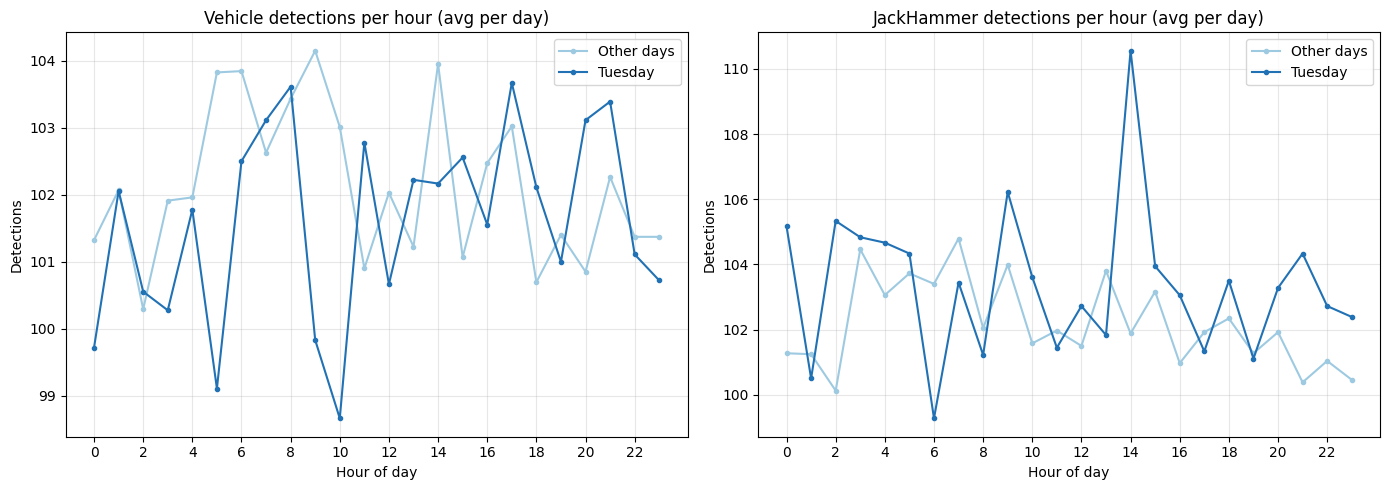

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax, label in zip(axes, ['Vehicle', 'JackHammer']):
    pivot = hourly_avg_per_day(sensor6_data, label)
    ax.plot(pivot.index, pivot['other_days_avg'], marker='o', markersize=3, label='Other days', color='#9ECAE1')
    ax.plot(pivot.index, pivot['tuesday_avg'], marker='o', markersize=3, label='Tuesday', color='#2171B5')
    ax.set_title(f'{label} detections per hour (avg per day)')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Detections')
    ax.set_xticks(range(0, 24, 2))
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

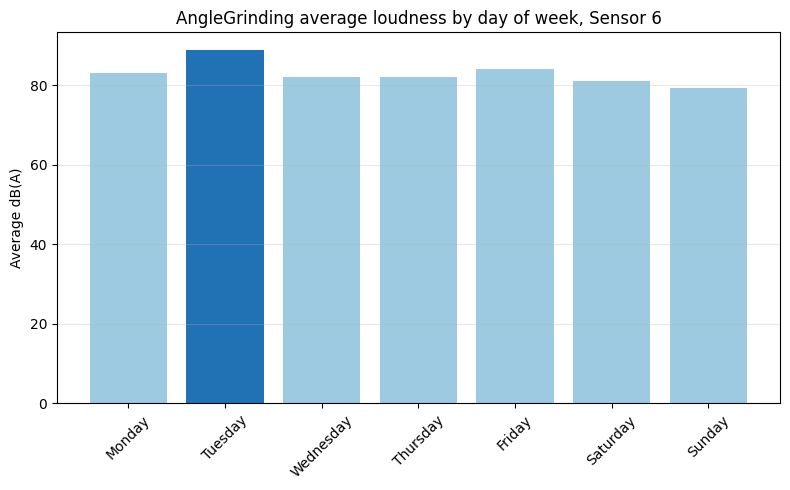

In [32]:
plt.figure(figsize=(8, 5))
ag_by_day = pivot_dba.loc['AngleGrinding']
colors = ['#2171B5' if day == 'Tuesday' else '#9ECAE1' for day in ag_by_day.index]
plt.bar(ag_by_day.index, ag_by_day.values, color=colors)
plt.ylabel('Average dB(A)')
plt.title('AngleGrinding average loudness by day of week, Sensor 6')
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

#### Dip at end of project for sensors 4, 6 and 12

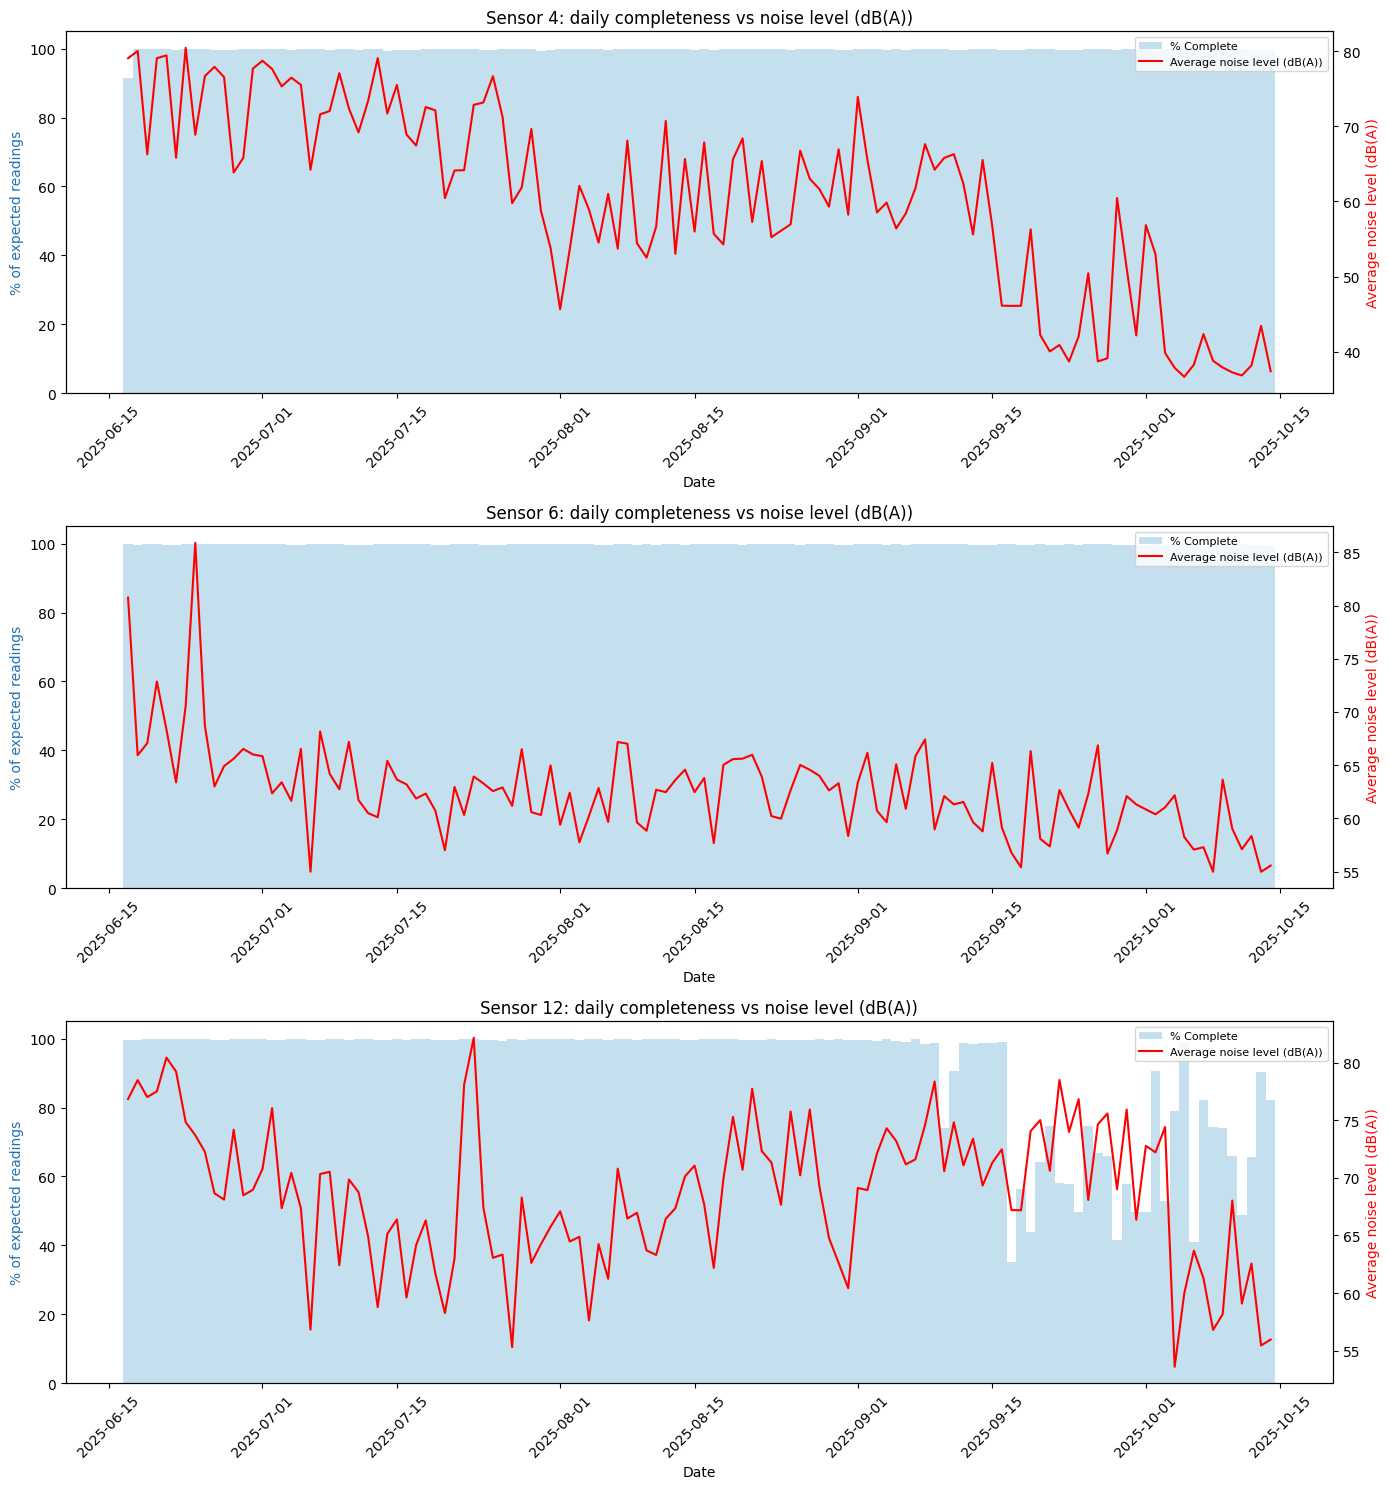

In [33]:
sensors_to_check = [4, 6, 12]

df_CityAI['date'] = df_CityAI['datetime'].dt.normalize()

fig, axes = plt.subplots(len(sensors_to_check), 1, figsize=(14, 5 * len(sensors_to_check)), sharex=False)

for ax, sensor in zip(axes, sensors_to_check):
    sensor_data = df_CityAI[df_CityAI.sensor == sensor].copy()

    daily_counts = sensor_data.groupby('date').size()
    daily_pct_complete = (daily_counts / 1440 * 100)

    daily_leq = (
        sensor_data.groupby('date')['avg_spla']
        .mean()
        .apply(lambda x: 10 * np.log10(x))
    )

    ax2 = ax.twinx()

    ax.bar(daily_pct_complete.index, daily_pct_complete.values, color='#9ECAE1', alpha=0.6, label='% Complete', width=1)
    ax2.plot(daily_leq.index, daily_leq.values, color='red', linewidth=1.5, label='Average noise level (dB(A))')

    ax.set_ylabel('% of expected readings', color='#2171B5')
    ax2.set_ylabel('Average noise level (dB(A))', color='red')
    ax.set_title(f'Sensor {sensor}: daily completeness vs noise level (dB(A))')
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', rotation=45)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [34]:
def label_composition_over_time(sensor_id, split_date):
    """
    Compares label composition (% of total detections) before vs after split_date,
    plus count and energy-correct avg dBA per label in each period.
    """
    data = df_CityAI_sources[df_CityAI_sources['sensor'] == sensor_id].copy()
    data['time'] = pd.to_datetime(data['time'])
    data['period'] = np.where(data['time'] < split_date, 'before', 'after')

    totals = data.groupby('period').size().reset_index(name='total_events')

    stats = (
        data.groupby(['period', 'label'])
        .agg(count=('avg_spl_a', 'count'), mean_linear=('avg_spl_a', 'mean'))
        .reset_index()
    )
    stats['avg_dba'] = 10 * np.log10(stats['mean_linear'])

    result = pd.merge(stats, totals, on='period')
    result['pct_of_total'] = result['count'] / result['total_events'] * 100

    print(f"\n=== Sensor {sensor_id}: label composition before/after {split_date} ===")
    print(result[['period', 'label', 'count', 'pct_of_total', 'avg_dba']]
          .sort_values(['period', 'pct_of_total'], ascending=[True, False])
          .to_string())

label_composition_over_time(4, '2025-08-01')   # sensor 4: decline starts roughly late July/early Aug
label_composition_over_time(6, '2025-08-01')   # sensor 6: same split for comparison, even if stable
label_composition_over_time(12, '2025-09-15')  # sensor 12: completeness/Leq drop starts mid-Sept


=== Sensor 4: label composition before/after 2025-08-01 ===
    period          label   count  pct_of_total    avg_dba
0    after  AngleGrinding  183539      9.128768  83.969957
2    after      Generator  183192      9.111509  83.967408
8    after         Silent  183083      9.106088  83.921171
1    after          Drill  183012      9.102557  83.925143
3    after          Human  182867      9.095345  83.995037
4    after     JackHammer  182785      9.091266  83.966058
9    after          Siren  182777      9.090868  83.983107
6    after         Piling  182386      9.071421  83.957749
7    after        Reverse  182386      9.071421  83.988053
10   after        Vehicle  182275      9.065900  83.953892
5    after  Miscconstruct  182249      9.064607  83.953982
11  before  AngleGrinding  109655      9.166600  95.220433
17  before         Piling  109128      9.122546  95.215997
16  before  Miscconstruct  108841      9.098554  95.217714
18  before        Reverse  108754      9.091281  95.21

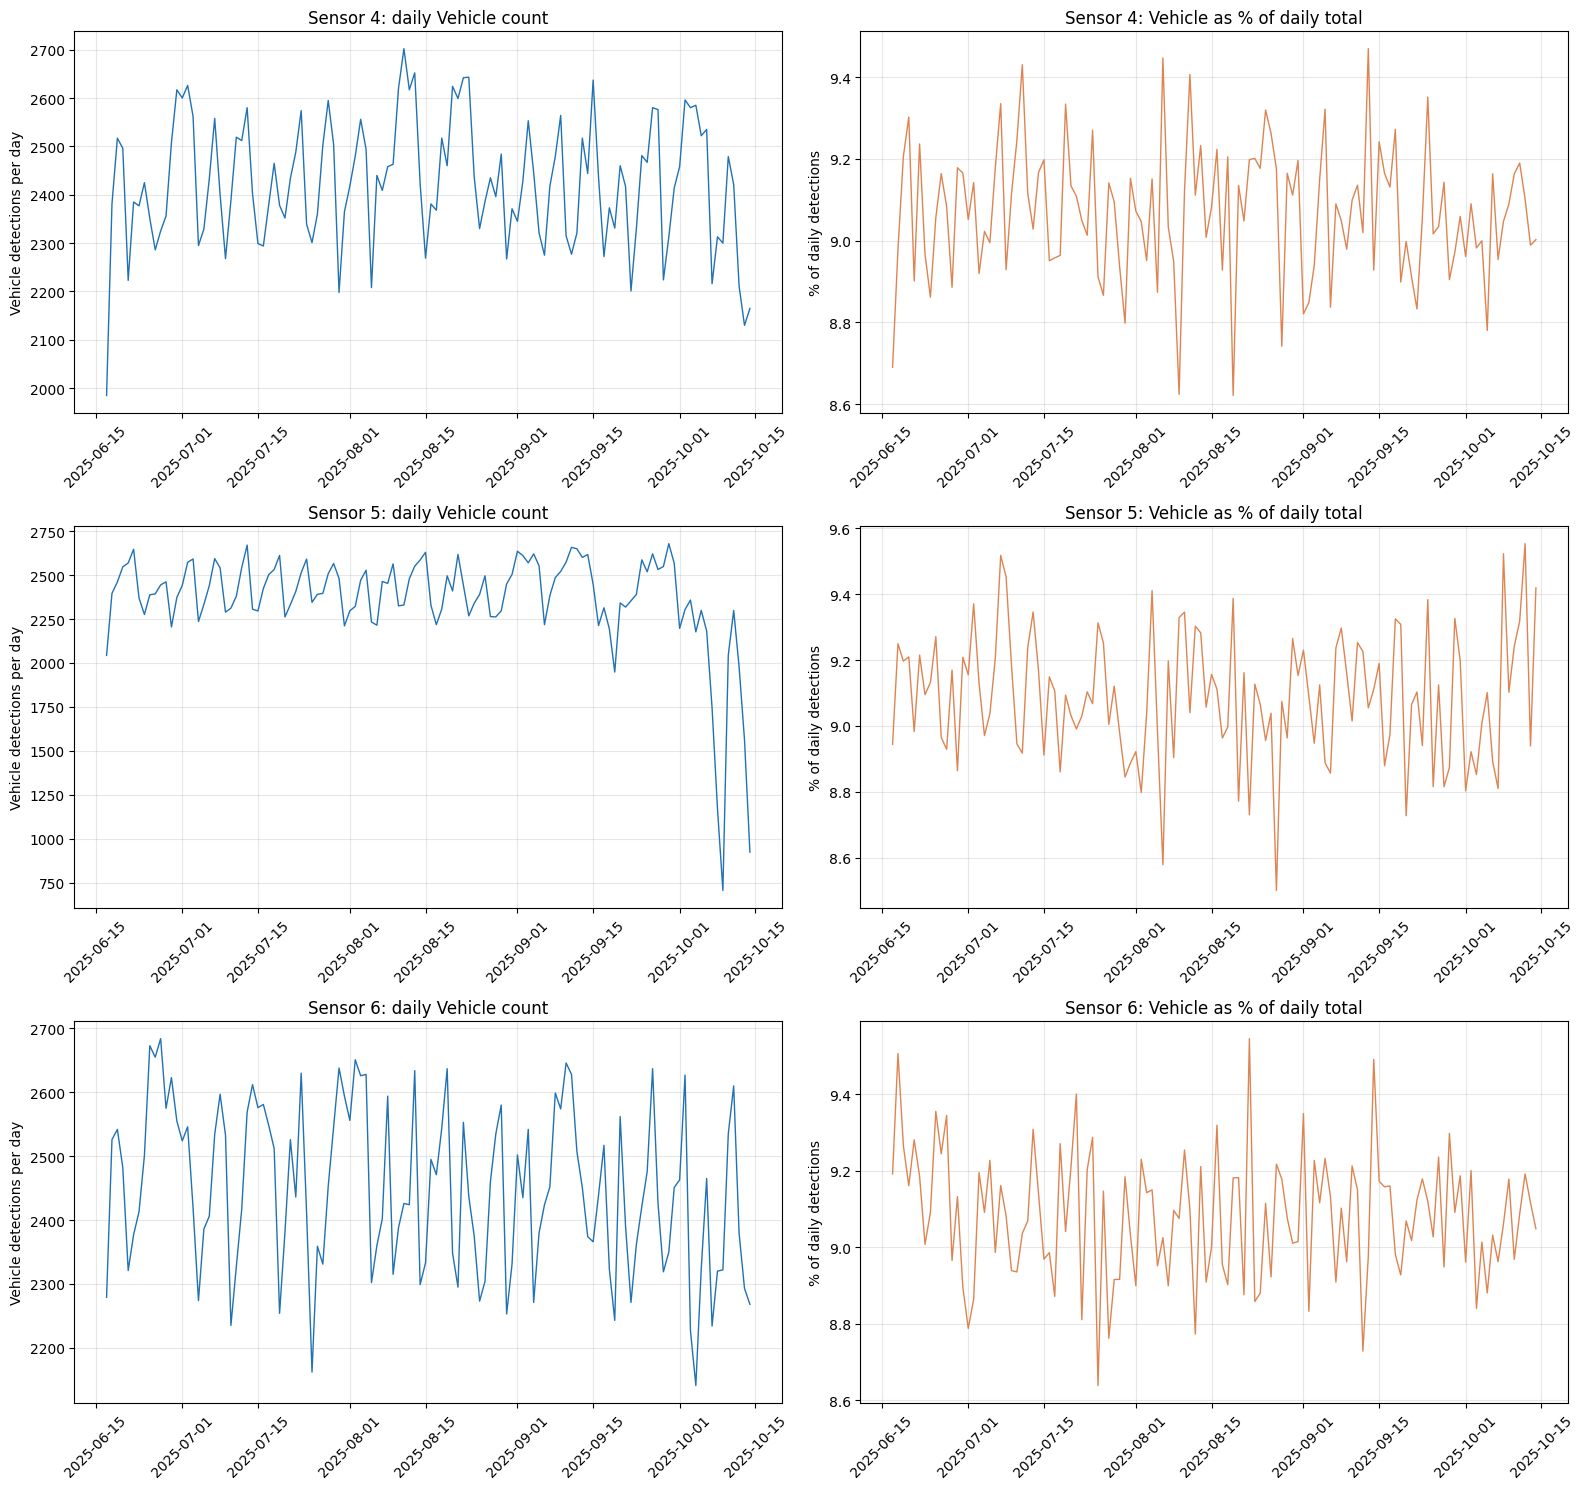

In [35]:
sensors_to_check = [4, 5, 6]

fig, axes = plt.subplots(len(sensors_to_check), 2, figsize=(16, 5 * len(sensors_to_check)))

for row, sensor in enumerate(sensors_to_check):
    sensor_data = df_CityAI_sources[df_CityAI_sources['sensor'] == sensor].copy()
    sensor_data['date'] = sensor_data['time'].dt.normalize()

    daily_vehicle = (
        sensor_data[sensor_data['label'] == 'Vehicle']
        .groupby('date')
        .size()
        .reset_index(name='vehicle_count')
    )
    daily_total = (
        sensor_data
        .groupby('date')
        .size()
        .reset_index(name='total_count')
    )
    daily = pd.merge(daily_total, daily_vehicle, on='date', how='left')
    daily['vehicle_count'] = daily['vehicle_count'].fillna(0)
    daily['pct_vehicle'] = daily['vehicle_count'] / daily['total_count'] * 100

    ax1 = axes[row, 0]
    ax2 = axes[row, 1]

    ax1.plot(daily['date'], daily['vehicle_count'], color='#2171B5', linewidth=1)
    ax1.set_ylabel('Vehicle detections per day')
    ax1.set_title(f'Sensor {sensor}: daily Vehicle count')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(alpha=0.3)

    ax2.plot(daily['date'], daily['pct_vehicle'], color='#DD8452', linewidth=1)
    ax2.set_ylabel('% of daily detections')
    ax2.set_title(f'Sensor {sensor}: Vehicle as % of daily total')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

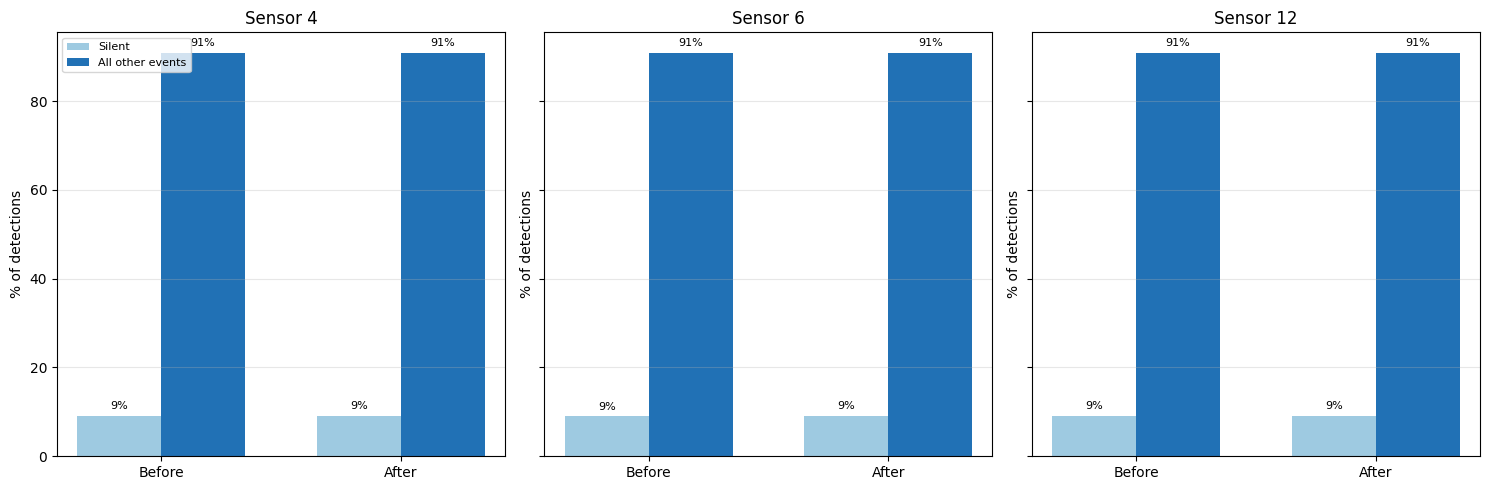

In [36]:
sensor_splits = [(4, '2025-08-01'), (6, '2025-08-01'), (12, '2025-08-01')]

def silent_vs_rest(sensor_id, split_date):
    data = df_CityAI_sources[df_CityAI_sources['sensor'] == sensor_id].copy()
    data['time'] = pd.to_datetime(data['time'])
    data['period'] = np.where(data['time'] < split_date, 'before', 'after')
    data['group'] = np.where(data['label'] == 'Silent', 'Silent', 'All other events')

    totals = data.groupby('period').size().reset_index(name='total_events')
    grouped = data.groupby(['period', 'group']).size().reset_index(name='count')
    result = pd.merge(grouped, totals, on='period')
    result['pct'] = result['count'] / result['total_events'] * 100
    result['sensor'] = sensor_id
    return result

all_results = pd.concat([silent_vs_rest(s, d) for s, d in sensor_splits], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (sensor, split) in zip(axes, sensor_splits):
    sensor_data = all_results[all_results.sensor == sensor]
    x = np.arange(2)
    width = 0.35

    silent_vals = [
        sensor_data[(sensor_data.group == 'Silent') & (sensor_data.period == 'before')]['pct'].values[0],
        sensor_data[(sensor_data.group == 'Silent') & (sensor_data.period == 'after')]['pct'].values[0],
    ]
    rest_vals = [
        sensor_data[(sensor_data.group == 'All other events') & (sensor_data.period == 'before')]['pct'].values[0],
        sensor_data[(sensor_data.group == 'All other events') & (sensor_data.period == 'after')]['pct'].values[0],
    ]

    bars1 = ax.bar(x - width/2, silent_vals, width, label='Silent', color='#9ECAE1')
    bars2 = ax.bar(x + width/2, rest_vals, width, label='All other events', color='#2171B5')

    for bar, val in zip(bars1, silent_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}%', ha='center', va='bottom', fontsize=8)
    for bar, val in zip(bars2, rest_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}%', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(['Before', 'After'])
    ax.set_title(f'Sensor {sensor}')
    ax.set_ylabel('% of detections')
    ax.grid(alpha=0.3, axis='y')

axes[0].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

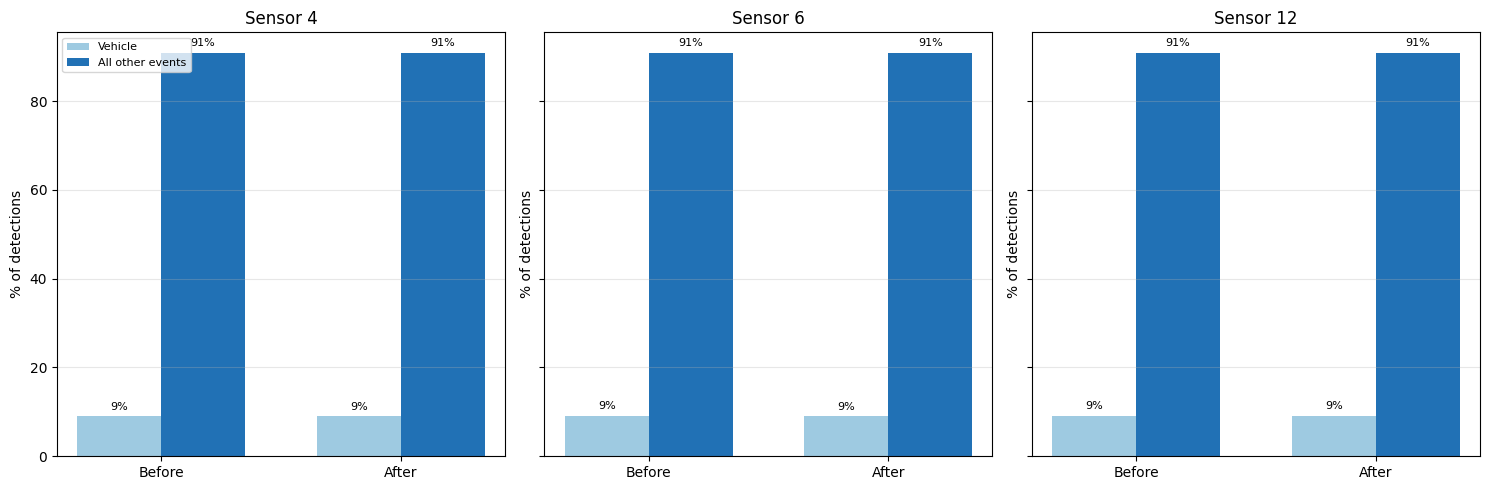

In [37]:
sensor_splits = [(4, '2025-08-01'), (6, '2025-08-01'), (12, '2025-08-01')]

def vehicle_vs_rest(sensor_id, split_date):
    data = df_CityAI_sources[df_CityAI_sources['sensor'] == sensor_id].copy()
    data['time'] = pd.to_datetime(data['time'])
    data['period'] = np.where(data['time'] < split_date, 'before', 'after')
    data['group'] = np.where(data['label'] == 'Vehicle', 'Vehicle', 'All other events')

    totals = data.groupby('period').size().reset_index(name='total_events')
    grouped = data.groupby(['period', 'group']).size().reset_index(name='count')
    result = pd.merge(grouped, totals, on='period')
    result['pct'] = result['count'] / result['total_events'] * 100
    result['sensor'] = sensor_id
    return result

all_results = pd.concat([vehicle_vs_rest(s, d) for s, d in sensor_splits], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (sensor, split) in zip(axes, sensor_splits):
    sensor_data = all_results[all_results.sensor == sensor]
    x = np.arange(2)
    width = 0.35

    vehicle_vals = [
        sensor_data[(sensor_data.group == 'Vehicle') & (sensor_data.period == 'before')]['pct'].values[0],
        sensor_data[(sensor_data.group == 'Vehicle') & (sensor_data.period == 'after')]['pct'].values[0],
    ]
    rest_vals = [
        sensor_data[(sensor_data.group == 'All other events') & (sensor_data.period == 'before')]['pct'].values[0],
        sensor_data[(sensor_data.group == 'All other events') & (sensor_data.period == 'after')]['pct'].values[0],
    ]

    bars1 = ax.bar(x - width/2, vehicle_vals, width, label='Vehicle', color='#9ECAE1')
    bars2 = ax.bar(x + width/2, rest_vals, width, label='All other events', color='#2171B5')

    for bar, val in zip(bars1, vehicle_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}%', ha='center', va='bottom', fontsize=8)
    for bar, val in zip(bars2, rest_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}%', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(['Before', 'After'])
    ax.set_title(f'Sensor {sensor}')
    ax.set_ylabel('% of detections')
    ax.grid(alpha=0.3, axis='y')

axes[0].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

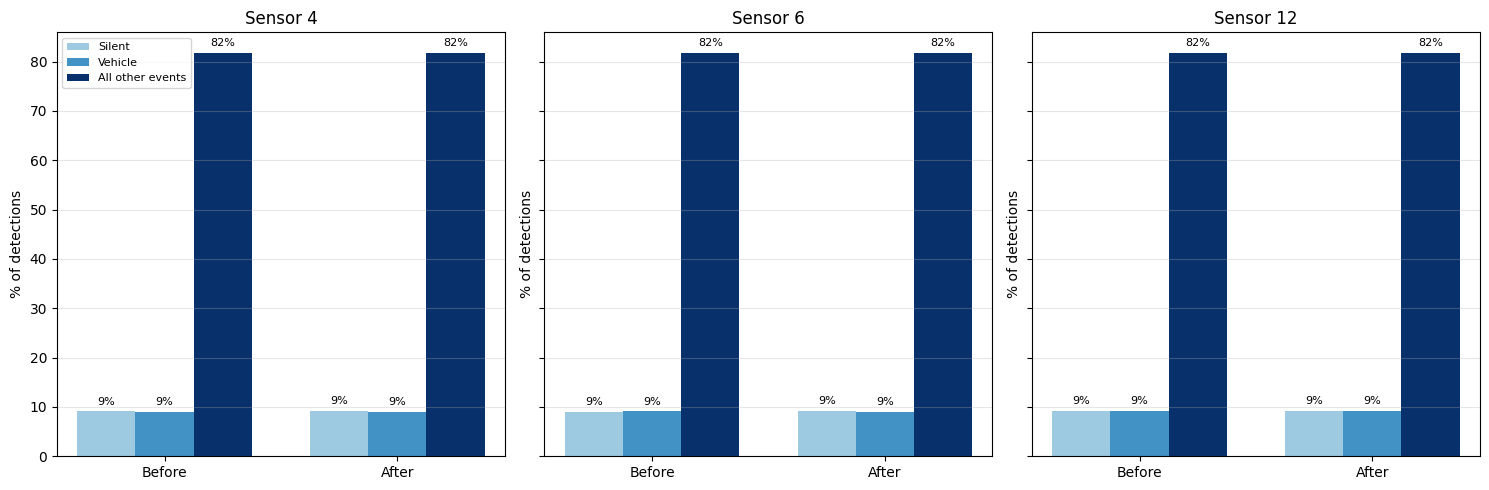

In [38]:
sensor_splits = [(4, '2025-08-01'), (6, '2025-08-01'), (12, '2025-08-01')]

def label_shares(sensor_id, split_date):
    data = df_CityAI_sources[df_CityAI_sources['sensor'] == sensor_id].copy()
    data['time'] = pd.to_datetime(data['time'])
    data['period'] = np.where(data['time'] < split_date, 'before', 'after')
    data['group'] = np.where(
        data['label'] == 'Silent', 'Silent',
        np.where(data['label'] == 'Vehicle', 'Vehicle', 'All other events')
    )

    totals = data.groupby('period').size().reset_index(name='total_events')
    grouped = data.groupby(['period', 'group']).size().reset_index(name='count')
    result = pd.merge(grouped, totals, on='period')
    result['pct'] = result['count'] / result['total_events'] * 100
    result['sensor'] = sensor_id
    return result

all_results = pd.concat([label_shares(s, d) for s, d in sensor_splits], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

groups = ['Silent', 'Vehicle', 'All other events']
colors = ['#9ECAE1', '#4292C6', '#08306B']

for ax, (sensor, split) in zip(axes, sensor_splits):
    sensor_data = all_results[all_results.sensor == sensor]
    x = np.arange(2)
    width = 0.25

    for i, (group, color) in enumerate(zip(groups, colors)):
        vals = [
            sensor_data[(sensor_data.group == group) & (sensor_data.period == 'before')]['pct'].values[0],
            sensor_data[(sensor_data.group == group) & (sensor_data.period == 'after')]['pct'].values[0],
        ]
        offset = (i - 1) * width
        bars = ax.bar(x + offset, vals, width, label=group, color=color)

        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}%', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(['Before', 'After'])
    ax.set_title(f'Sensor {sensor}')
    ax.set_ylabel('% of detections')
    ax.grid(alpha=0.3, axis='y')

axes[0].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

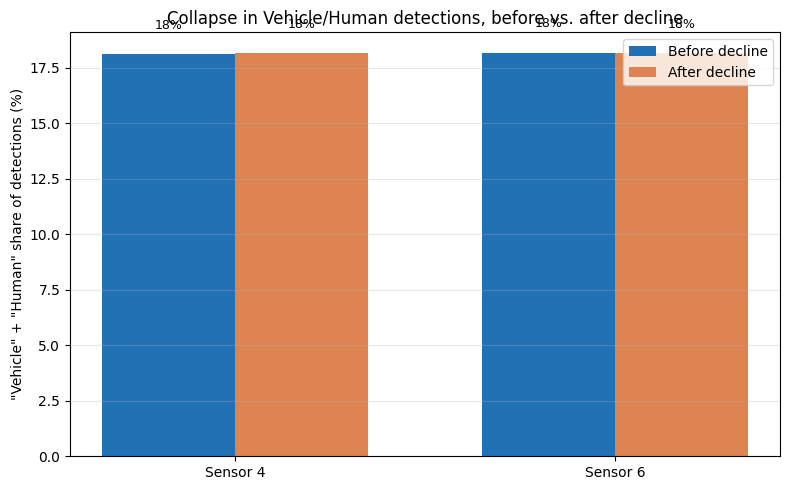

In [39]:
def combined_share_before_after(sensor_id, split_date):
    data = df_CityAI_sources[df_CityAI_sources['sensor'] == sensor_id].copy()
    data['time'] = pd.to_datetime(data['time'])
    data['period'] = np.where(data['time'] < split_date, 'before', 'after')

    totals = data.groupby('period').size().reset_index(name='total_events')
    veh_human = data[data['label'].isin(['Vehicle', 'Human'])].groupby('period').size().reset_index(name='count')

    result = pd.merge(totals, veh_human, on='period')
    result['pct'] = result['count'] / result['total_events'] * 100
    result['sensor'] = sensor_id
    return result

sensor_splits = [(4, '2025-08-01'), (6, '2025-08-01')]
combined_results = pd.concat([combined_share_before_after(s, d) for s, d in sensor_splits], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(sensor_splits))
width = 0.35

before_vals = [combined_results[(combined_results.sensor == s) & (combined_results.period == 'before')]['pct'].values[0] for s, d in sensor_splits]
after_vals = [combined_results[(combined_results.sensor == s) & (combined_results.period == 'after')]['pct'].values[0] for s, d in sensor_splits]

bars1 = ax.bar(x - width/2, before_vals, width, label='Before decline', color='#2171B5')
bars2 = ax.bar(x + width/2, after_vals, width, label='After decline', color='#DD8452')

for bar, val in zip(bars1, before_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}%', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, after_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'Sensor {s}' for s, d in sensor_splits])
ax.set_ylabel('"Vehicle" + "Human" share of detections (%)')
ax.set_title('Collapse in Vehicle/Human detections, before vs. after decline')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

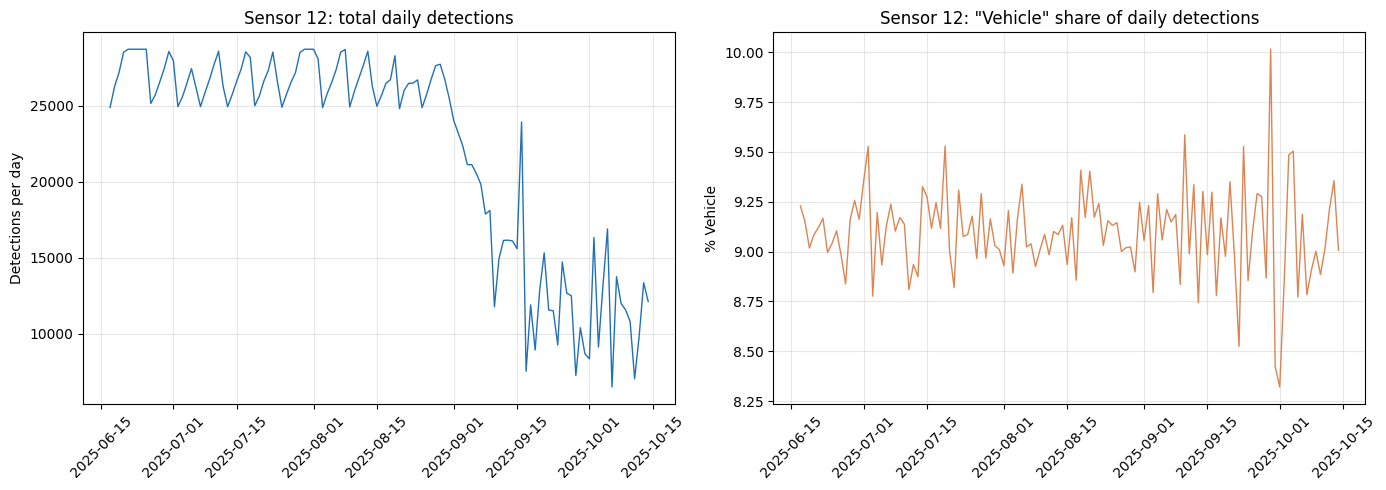

In [40]:
sensor12_data = df_CityAI_sources[df_CityAI_sources['sensor'] == 12].copy()
sensor12_data['date'] = sensor12_data['time'].dt.normalize()

daily_total = sensor12_data.groupby('date').size().reset_index(name='total_count')
daily_vehicle = sensor12_data[sensor12_data['label'] == 'Vehicle'].groupby('date').size().reset_index(name='vehicle_count')
daily = pd.merge(daily_total, daily_vehicle, on='date', how='left')
daily['vehicle_count'] = daily['vehicle_count'].fillna(0)
daily['pct_vehicle'] = daily['vehicle_count'] / daily['total_count'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(daily['date'], daily['total_count'], color='#2171B5', linewidth=1)
axes[0].set_title('Sensor 12: total daily detections')
axes[0].set_ylabel('Detections per day')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

axes[1].plot(daily['date'], daily['pct_vehicle'], color='#DD8452', linewidth=1)
axes[1].set_title('Sensor 12: "Vehicle" share of daily detections')
axes[1].set_ylabel('% Vehicle')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Sensors 11 and 12 gap weekend and time of day

In [41]:
sensor_data = df_CityAI_sources[df_CityAI_sources['sensor'].isin([11, 12])].copy()
sensor_data['is_day'] = sensor_data['hour'].between(7, 19)
sensor_data['is_weekend'] = sensor_data['time'].dt.dayofweek >= 5

vehicle_data = sensor_data[sensor_data['label'] == 'Vehicle'].copy()

vehicle_day_night = (
    vehicle_data.groupby(['sensor', 'is_day'])
    .size()
    .reset_index(name='vehicle_count')
)
total_day_night = (
    sensor_data.groupby(['sensor', 'is_day'])
    .size()
    .reset_index(name='total_count')
)
day_night = pd.merge(vehicle_day_night, total_day_night, on=['sensor', 'is_day'])
day_night['pct_vehicle'] = day_night['vehicle_count'] / day_night['total_count'] * 100

print("Vehicle detections: day vs night, sensor 11 vs 12:")
print(day_night.to_string())

vehicle_weekday_weekend = (
    vehicle_data.groupby(['sensor', 'is_weekend'])
    .size()
    .reset_index(name='vehicle_count')
)
total_weekday_weekend = (
    sensor_data.groupby(['sensor', 'is_weekend'])
    .size()
    .reset_index(name='total_count')
)
weekday_weekend = pd.merge(vehicle_weekday_weekend, total_weekday_weekend, on=['sensor', 'is_weekend'])
weekday_weekend['pct_vehicle'] = weekday_weekend['vehicle_count'] / weekday_weekend['total_count'] * 100

print("\nVehicle detections: weekday vs weekend, sensor 11 vs 12:")
print(weekday_weekend.to_string())

vehicle_dba_day_night = (
    vehicle_data.groupby(['sensor', 'is_day'])
    .agg(mean_linear=('avg_spl_a', 'mean'), n=('avg_spl_a', 'count'))
    .reset_index()
)
vehicle_dba_day_night['avg_dba'] = 10 * np.log10(vehicle_dba_day_night['mean_linear'])

print("\nVehicle avg dBA: day vs night, sensor 11 vs 12:")
print(vehicle_dba_day_night[['sensor', 'is_day', 'n', 'avg_dba']].to_string())

hourly_vehicle = (
    vehicle_data.groupby(['sensor', 'hour'])
    .size()
    .reset_index(name='count')
)
print("\nHourly Vehicle detection counts, sensor 11 vs 12:")
print(hourly_vehicle.pivot(index='hour', columns='sensor', values='count').to_string())


Vehicle detections: day vs night, sensor 11 vs 12:
   sensor  is_day  vehicle_count  total_count  pct_vehicle
0      11   False         127250      1394991     9.121923
1      11    True         151246      1666289     9.076817
2      12   False         112178      1235845     9.077028
3      12    True         129919      1424472     9.120502

Vehicle detections: weekday vs weekend, sensor 11 vs 12:
   sensor  is_weekend  vehicle_count  total_count  pct_vehicle
0      11       False         200606      2205233     9.096817
1      11        True          77890       856047     9.098799
2      12       False         174029      1911862     9.102592
3      12        True          68068       748455     9.094468

Vehicle avg dBA: day vs night, sensor 11 vs 12:
   sensor  is_day       n    avg_dba
0      11   False  127250  94.727538
1      11    True  151246  95.307371
2      12   False  112176  90.554055
3      12    True  129919  91.242071

Hourly Vehicle detection counts, sensor 11 vs 

## Survey

In [42]:
def center_last_row(axes, n_used, n_cols):
    # shifts the last row's used axes horizontally so they're centered
    n_last_row_used = n_used % n_cols
    if n_last_row_used == 0:
        return
    n_empty = n_cols - n_last_row_used
    shift = (n_empty / 2) * (1.0 / n_cols)
    last_row_axes = axes[n_used - n_last_row_used:n_used]
    for ax in last_row_axes:
        pos = ax.get_position()
        ax.set_position([pos.x0 + shift, pos.y0, pos.width, pos.height])

In [43]:
def plot_response_counts(df, columns, title="Responses by category", ax=None):
    # plots stacked counts of all answer categories for each column in columns, with raw counts labeled on each bar segment
    category_order = ["Not at all", "Slightly", "Moderately", "Very", "Extremely"]
    colors = {
        "Not at all": '#DEEBF7',
        "Slightly": '#9ECAE1',
        "Moderately": '#4292C6',
        "Very": '#2171B5',
        "Extremely": '#08306B'
    }

    labels = [col.split('_', 1)[-1] for col in columns]
    x = np.arange(len(labels))

    counts_by_category = {cat: [] for cat in category_order}
    for col in columns:
        vc = df[col].value_counts()
        for cat in category_order:
            counts_by_category[cat].append(vc.get(cat, 0))

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(max(6, len(labels) * 1.4), 6))

    bottom = np.zeros(len(labels))
    for cat in category_order:
        values = np.array(counts_by_category[cat])
        bars = ax.bar(x, values, bottom=bottom, label=cat, color=colors[cat])

        for i, v in enumerate(values):
            if v > 0:
                ax.text(x[i], bottom[i] + v / 2, str(v),
                        ha='center', va='center', color='black' if cat in ["Not at all", "Slightly"] else 'white',
                        fontsize=8)

        bottom += values

    ax.set_ylabel('Number of responses')
    ax.set_xlabel('Category')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.legend(title='Response', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
    ax.grid(alpha=0.3, axis='y')

    if standalone:
        plt.tight_layout()
        plt.show()

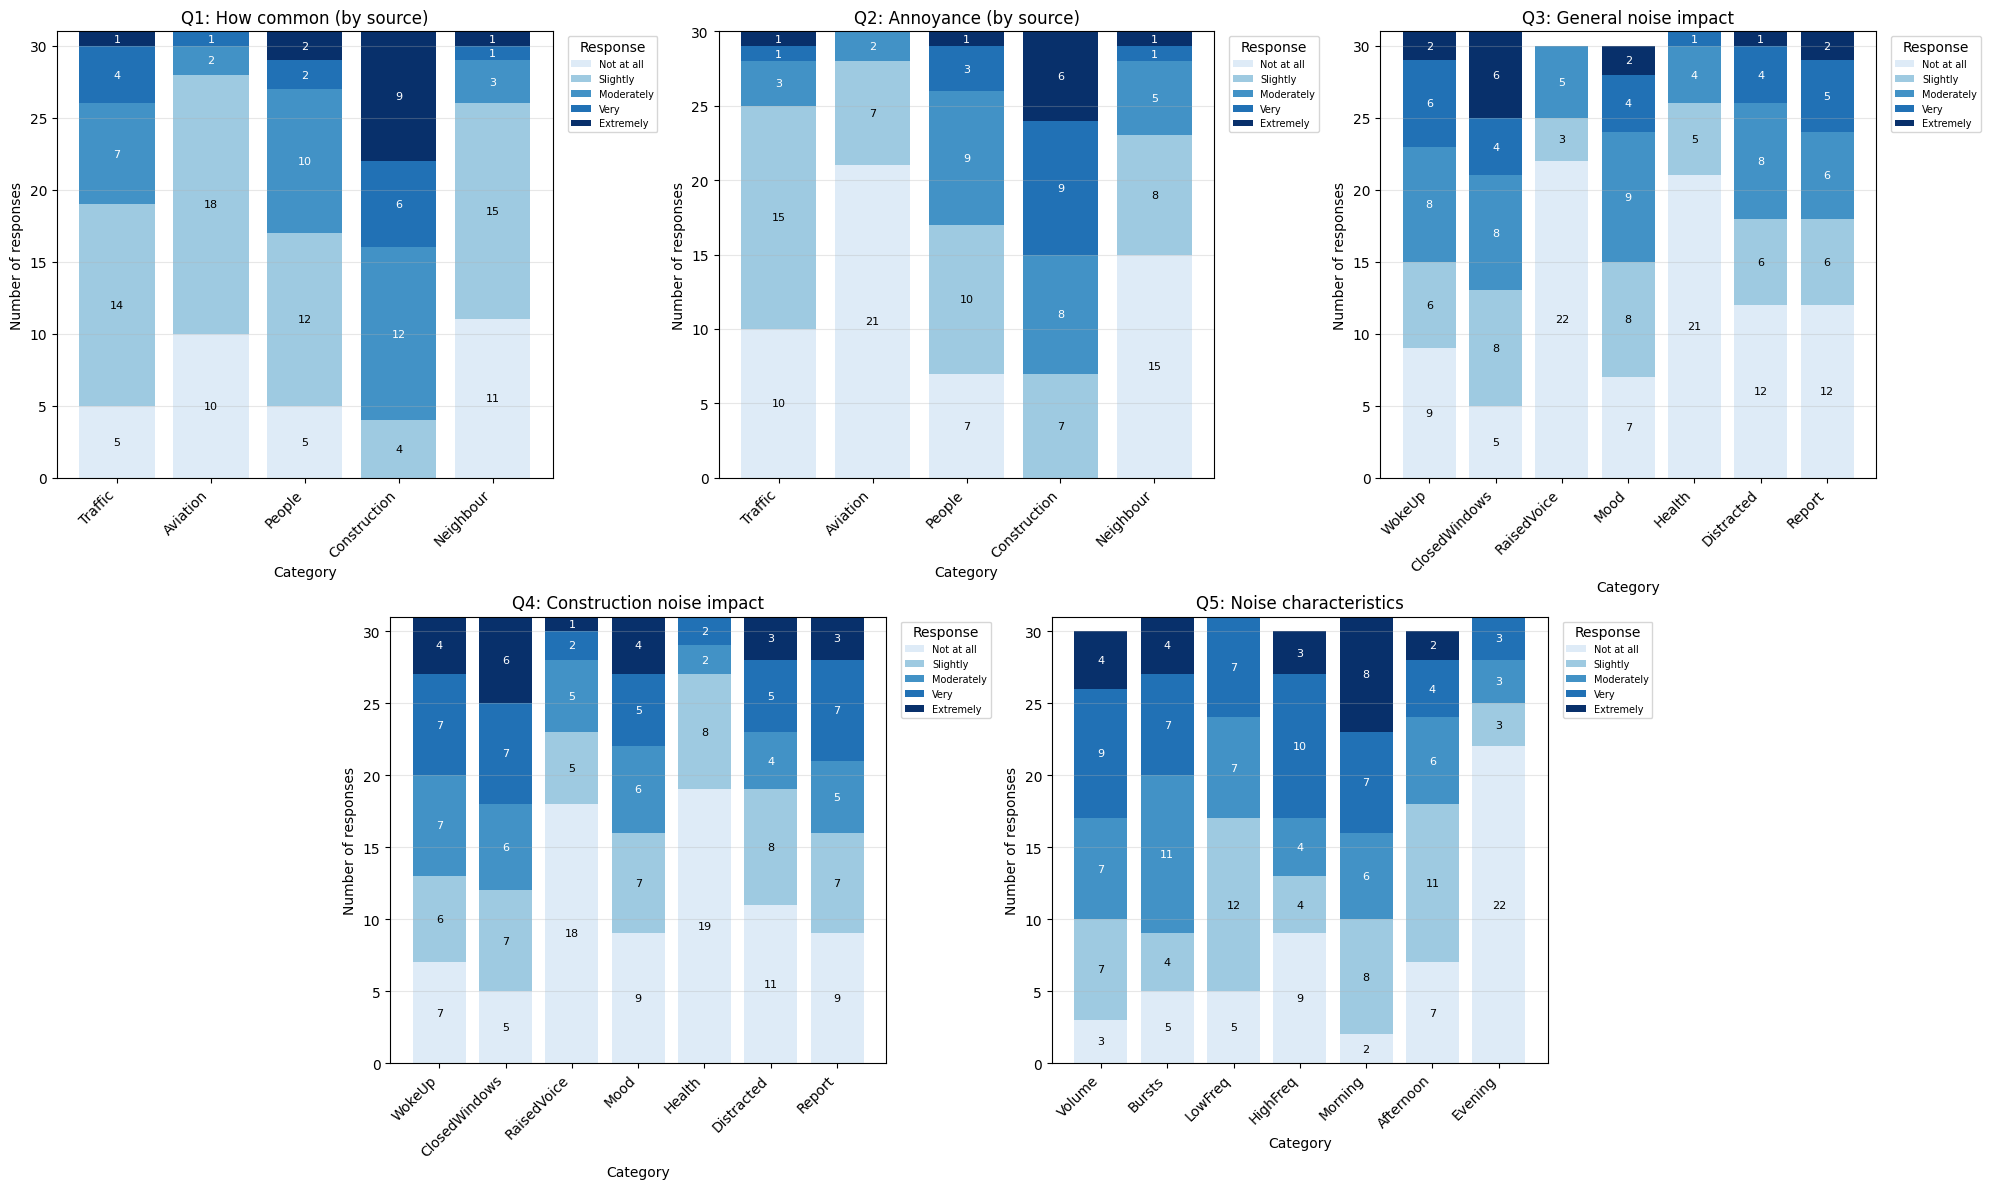

In [44]:
sources = ["Traffic", "Aviation", "People", "Construction", "Neighbour"]
q3_q4_items = ["WokeUp", "ClosedWindows", "RaisedVoice", "Mood", "Health", "Distracted", "Report"]
q5_items = ["Volume", "Bursts", "LowFreq", "HighFreq", "Morning", "Afternoon", "Evening"]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# Q1 - how common each source is
plot_response_counts(df_Survey, [f"Q1_{s}" for s in sources], title="Q1: How common (by source)", ax=axes[0])

# Q2 - how annoying each source is
plot_response_counts(df_Survey, [f"Q2_{s}" for s in sources], title="Q2: Annoyance (by source)", ax=axes[1])

# Q3 - general noise impact
plot_response_counts(df_Survey, [f"Q3_{i}" for i in q3_q4_items], title="Q3: General noise impact", ax=axes[2])

# Q4 - construction noise impact
plot_response_counts(df_Survey, [f"Q4_{i}" for i in q3_q4_items], title="Q4: Construction noise impact", ax=axes[3])

# Q5 - noise characteristics
plot_response_counts(df_Survey, [f"Q5_{i}" for i in q5_items], title="Q5: Noise characteristics", ax=axes[4])

axes[5].axis('off')

plt.tight_layout()
center_last_row(axes, n_used=5, n_cols=3)
plt.show()

#### Observations
##### Question 1
1. Construction and to a lesser extent people and traffic are common
##### Question 2
1. Construction by far most annoying
##### Question 3.
1. Health and raised voices are not really at all a problem with general noise
2. Woke up and closed windows are most common in general
##### Question 4.
1. Seems like overall a very similar pattern
##### Question 5.
1. Noise in the morning is a problem
2. Noise in the evening and night is not at all
3. Most factors contribute, mostly volume and bursts.
4. Seems like high frequency is more polarising: more people who say it's not a problem at all than with low frequency, but less people saying slightly and more saying very and extremely.

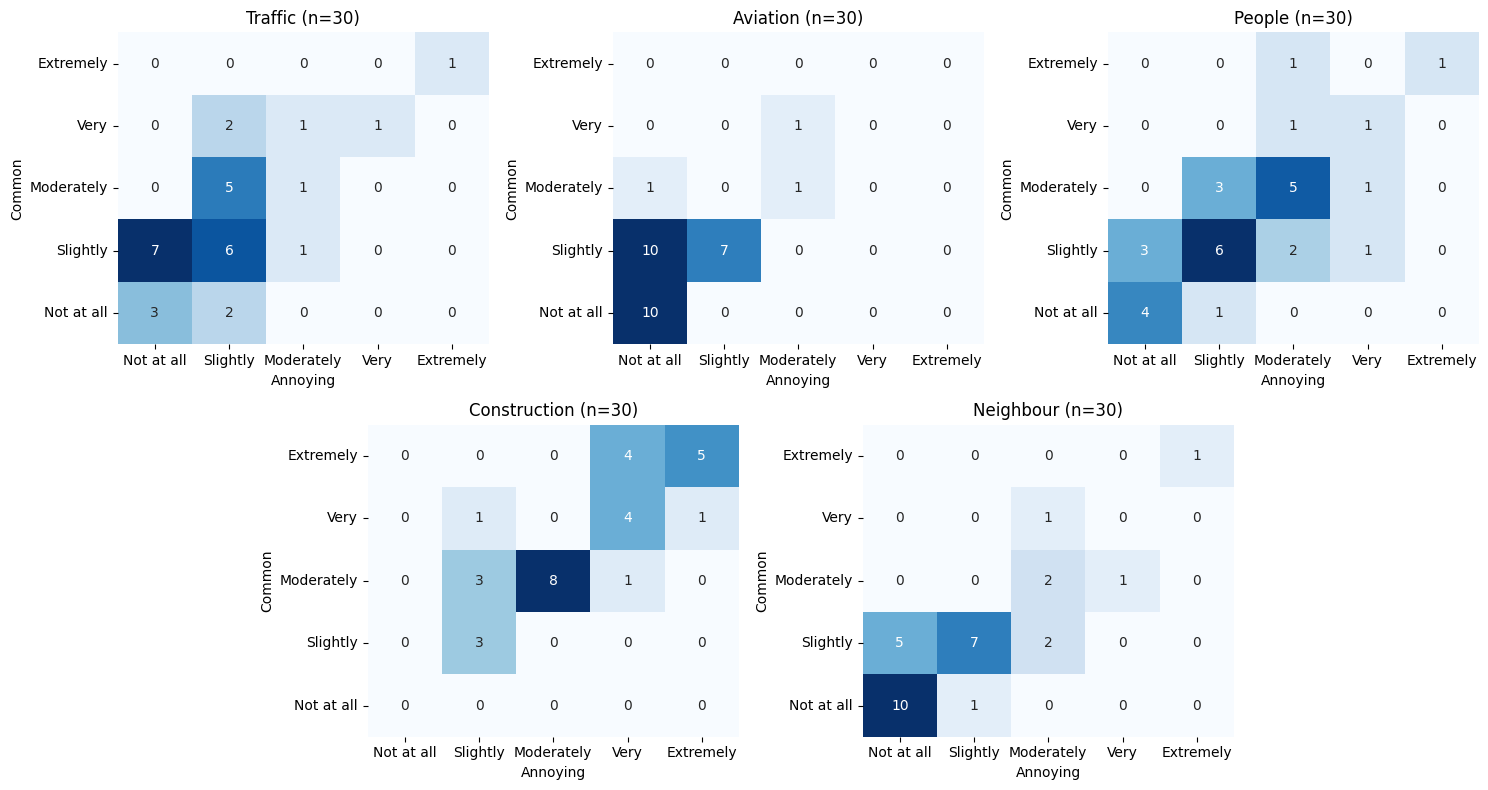

In [45]:
category_order = ["Not at all", "Slightly", "Moderately", "Very", "Extremely"]
y_order = list(reversed(category_order))
x_order = category_order

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, source in zip(axes, sources):
    common_col = f"Q1_{source}"
    annoying_col = f"Q2_{source}"

    all_data = df_Survey

    crosstab_all = pd.crosstab(all_data[common_col], all_data[annoying_col])
    crosstab_all = crosstab_all.reindex(index=y_order, columns=x_order, fill_value=0)

    n_actual = crosstab_all.values.sum()

    sns.heatmap(crosstab_all, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"{source} (n={n_actual})")
    ax.set_xlabel("Annoying")
    ax.set_ylabel("Common")

for ax in axes[len(sources):]:
    ax.axis('off')

plt.tight_layout()
center_last_row(axes, n_used=len(sources), n_cols=3)
plt.show()

In [47]:
comparison_table = []
category_to_num = {cat: i + 1 for i, cat in enumerate(category_order)}
for source in sources:
    common_col = f"Q1_{source}"
    annoying_col = f"Q2_{source}"

    paired = df_Survey[[common_col, annoying_col]].dropna()
    common_numeric = paired[common_col].map(category_to_num)
    annoying_numeric = paired[annoying_col].map(category_to_num)

    n = len(paired)
    more_annoying = (annoying_numeric > common_numeric).sum()
    less_annoying = (annoying_numeric < common_numeric).sum()
    as_annoying = (annoying_numeric == common_numeric).sum()

    comparison_table.append({
        "Source": source,
        "n": n,
        "More annoying than common": more_annoying,
        "More annoying (%)": round(more_annoying / n * 100, 1),
        "Less annoying than common": less_annoying,
        "Less annoying (%)": round(less_annoying / n * 100, 1),
        "As annoying as common": as_annoying,
        "As annoying (%)": round(as_annoying / n * 100, 1),
    })

comparison_table = pd.DataFrame(comparison_table)
comparison_table

,Source,n,More annoying than common,More annoying (%),Less annoying than common,Less annoying (%),As annoying as common,As annoying (%)
0,Traffic,30,3,10.0,15,50.0,12,40.0
1,Aviation,30,0,0.0,12,40.0,18,60.0
2,People,30,5,16.7,8,26.7,17,56.7
3,Construction,30,2,6.7,8,26.7,20,66.7
4,Neighbour,30,4,13.3,6,20.0,20,66.7


#### Observations
##### Traffic
Slightly more common than annoying, can be attributed most likely by the fact most areas were residential
##### Aviation
Not common or annoying
##### People
Already more common and annoying, follows a diagonal pattern
##### Construction
By far the most common and annoying. Seems people aren't too bothered by it, comparative to how common it is.
##### Neighbour
Not common or annoying, though slightly less annoying than common.


The cell below aims to quantify the observations above.

         Source  Mean_Common  Mean_Annoying  Gap_Annoying_minus_Common
0       Traffic     2.419355       1.933333                  -0.486022
1      Aviation     1.806452       1.366667                  -0.439785
2        People     2.483871       2.366667                  -0.117204
3  Construction     3.645161       3.466667                  -0.178495
4     Neighbour     1.903226       1.833333                  -0.069892


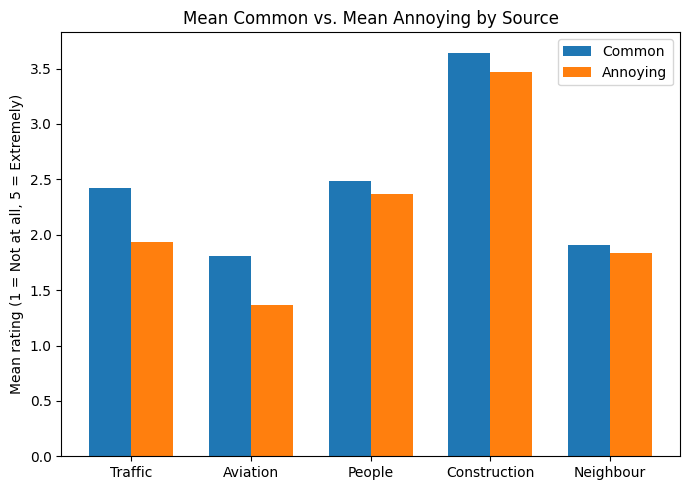

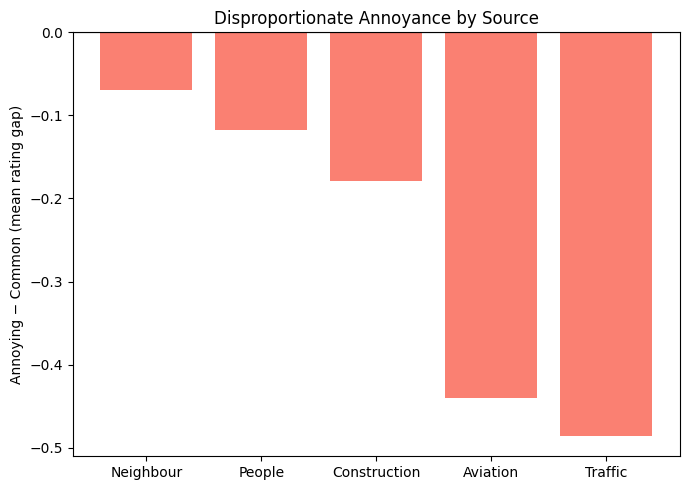

In [48]:
sources = ["Traffic", "Aviation", "People", "Construction", "Neighbour"]

category_to_num = {cat: i + 1 for i, cat in enumerate(category_order)}

mean_common = []
mean_annoying = []

for source in sources:
    common_numeric = df_Survey[f"Q1_{source}"].map(category_to_num)
    annoying_numeric = df_Survey[f"Q2_{source}"].map(category_to_num)

    mean_common.append(common_numeric.mean())
    mean_annoying.append(annoying_numeric.mean())

comparison = pd.DataFrame({
    "Source": sources,
    "Mean_Common": mean_common,
    "Mean_Annoying": mean_annoying,
})
comparison["Gap_Annoying_minus_Common"] = comparison["Mean_Annoying"] - comparison["Mean_Common"]

print(comparison)

x = range(len(sources))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar([i - width/2 for i in x], comparison["Mean_Common"], width=width, label="Common")
plt.bar([i + width/2 for i in x], comparison["Mean_Annoying"], width=width, label="Annoying")
plt.xticks(x, sources)
plt.ylabel("Mean rating (1 = Not at all, 5 = Extremely)")
plt.title("Mean Common vs. Mean Annoying by Source")
plt.legend()
plt.tight_layout()
plt.show()

comparison_sorted = comparison.sort_values("Gap_Annoying_minus_Common", ascending=False)

plt.figure(figsize=(7, 5))
plt.bar(comparison_sorted["Source"], comparison_sorted["Gap_Annoying_minus_Common"], color="salmon")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Annoying − Common (mean rating gap)")
plt.title("Disproportionate Annoyance by Source")
plt.tight_layout()
plt.show()

The cell below prints Q2 (annoyance) response distribution as % per source for section 4.2.1

In [49]:
for source in sources:
    print(f"\n--- {source}: Annoying distribution ---")
    print(df_Survey[f"Q2_{source}"].value_counts(normalize=True).reindex(category_order).round(2))


--- Traffic: Annoying distribution ---
Q2_Traffic
Not at all    0.33
Slightly      0.50
Moderately    0.10
Very          0.03
Extremely     0.03
Name: proportion, dtype: float64

--- Aviation: Annoying distribution ---
Q2_Aviation
Not at all    0.70
Slightly      0.23
Moderately    0.07
Very           NaN
Extremely      NaN
Name: proportion, dtype: float64

--- People: Annoying distribution ---
Q2_People
Not at all    0.23
Slightly      0.33
Moderately    0.30
Very          0.10
Extremely     0.03
Name: proportion, dtype: float64

--- Construction: Annoying distribution ---
Q2_Construction
Not at all     NaN
Slightly      0.23
Moderately    0.27
Very          0.30
Extremely     0.20
Name: proportion, dtype: float64

--- Neighbour: Annoying distribution ---
Q2_Neighbour
Not at all    0.50
Slightly      0.27
Moderately    0.17
Very          0.03
Extremely     0.03
Name: proportion, dtype: float64


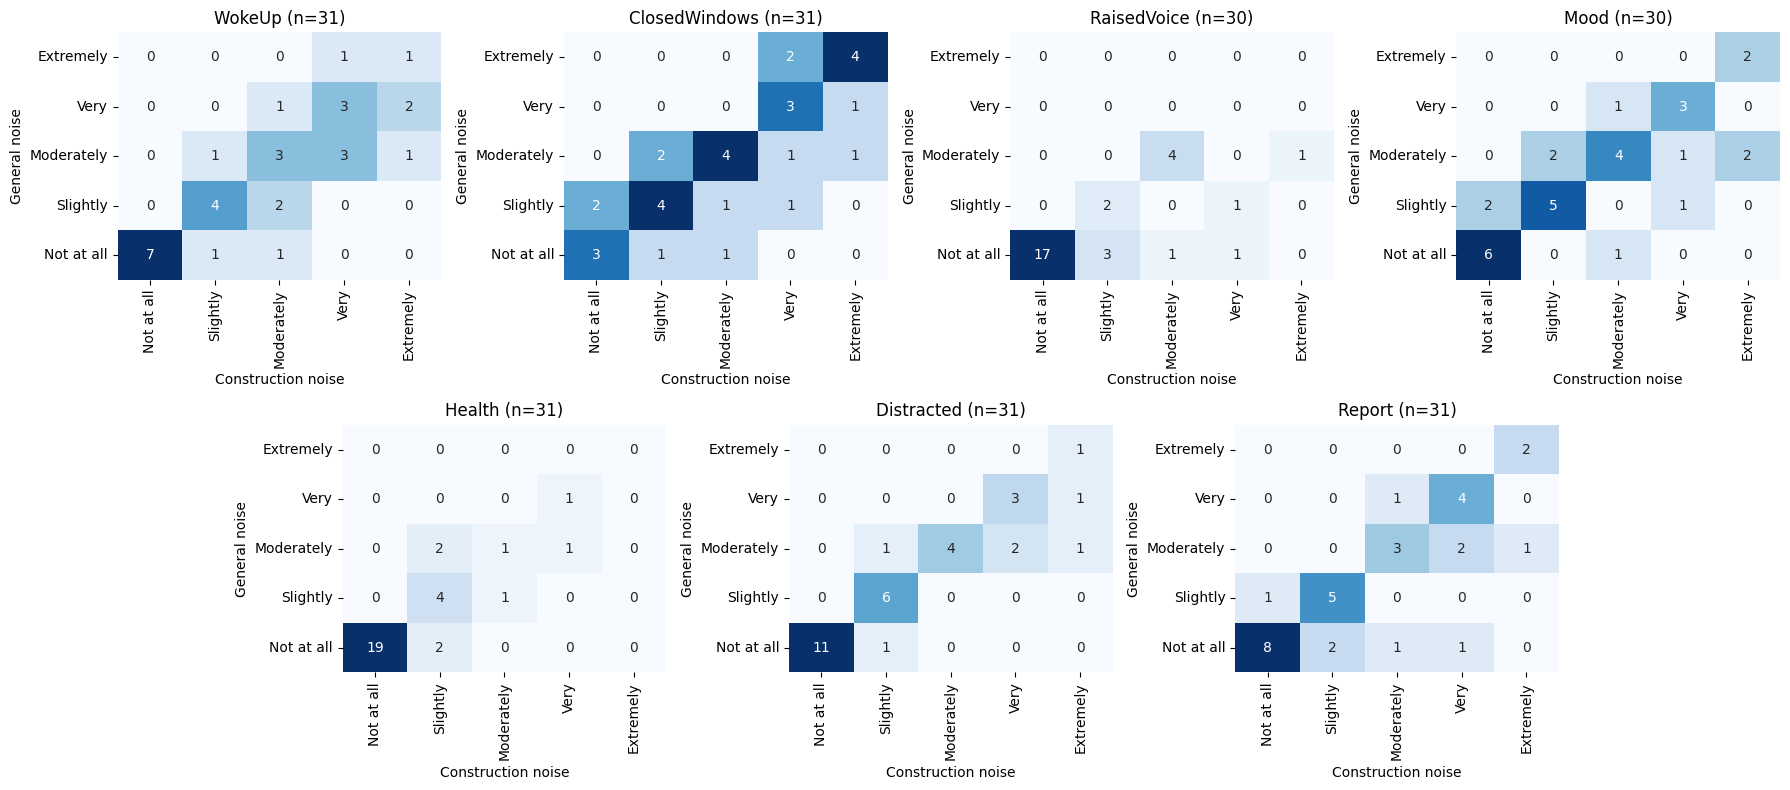

In [50]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, item in zip(axes, q3_q4_items):
    general_col = f"Q3_{item}"
    construction_col = f"Q4_{item}"

    all_data = df_Survey

    crosstab_all = pd.crosstab(all_data[general_col], all_data[construction_col])
    crosstab_all = crosstab_all.reindex(index=y_order, columns=x_order, fill_value=0)

    n_actual = crosstab_all.values.sum()

    sns.heatmap(crosstab_all, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"{item} (n={n_actual})")
    ax.set_xlabel("Construction noise")
    ax.set_ylabel("General noise")

for ax in axes[len(q3_q4_items):]:
    ax.axis('off')

plt.tight_layout()
center_last_row(axes, n_used=len(q3_q4_items), n_cols=4)
plt.show()

In [51]:
comparison_table_q3_q4 = []

for item in q3_q4_items:
    general_col = f"Q3_{item}"
    construction_col = f"Q4_{item}"

    paired = df_Survey[[general_col, construction_col]].dropna()
    general_numeric = paired[general_col].map(category_to_num)
    construction_numeric = paired[construction_col].map(category_to_num)

    n = len(paired)
    more_affected = (construction_numeric > general_numeric).sum()
    less_affected = (construction_numeric < general_numeric).sum()
    as_affected = (construction_numeric == general_numeric).sum()

    comparison_table_q3_q4.append({
        "Behaviour": item,
        "n": n,
        "More affected by construction": more_affected,
        "More affected (%)": round(more_affected / n * 100),
        "Less affected by construction": less_affected,
        "Less affected (%)": round(less_affected / n * 100),
        "Equally affected": as_affected,
        "Equally affected (%)": round(as_affected / n * 100),
    })

comparison_table_q3_q4 = pd.DataFrame(comparison_table_q3_q4)
comparison_table_q3_q4

,Behaviour,n,More affected by construction,More affected (%),Less affected by construction,Less affected (%),Equally affected,Equally affected (%)
0,WokeUp,31,10,32,3,10,18,58
1,ClosedWindows,31,7,23,6,19,18,58
2,RaisedVoice,30,7,23,0,0,23,77
3,Mood,30,5,17,5,17,20,67
4,Health,31,4,13,2,6,25,81
5,Distracted,31,5,16,1,3,25,81
6,Report,31,7,23,2,6,22,71


#### Observations
##### Woke up
Seems there's some commonality between people being annoyed in general vs annoyed by noise
##### Closed window
Most commmon behaviour, also a linear relationship,
##### Raised voices
Just not a concern
##### Mood
Also quite linear and a bit of a mix between answers. Seems it's dependant on general noise perception
##### Health
Not really a concern here, although the only way to truely assess health is medical consultation.
##### Distracted
Very linear, though most people are fine
##### Report
Not too much of a concern for most, though still slightly linear.

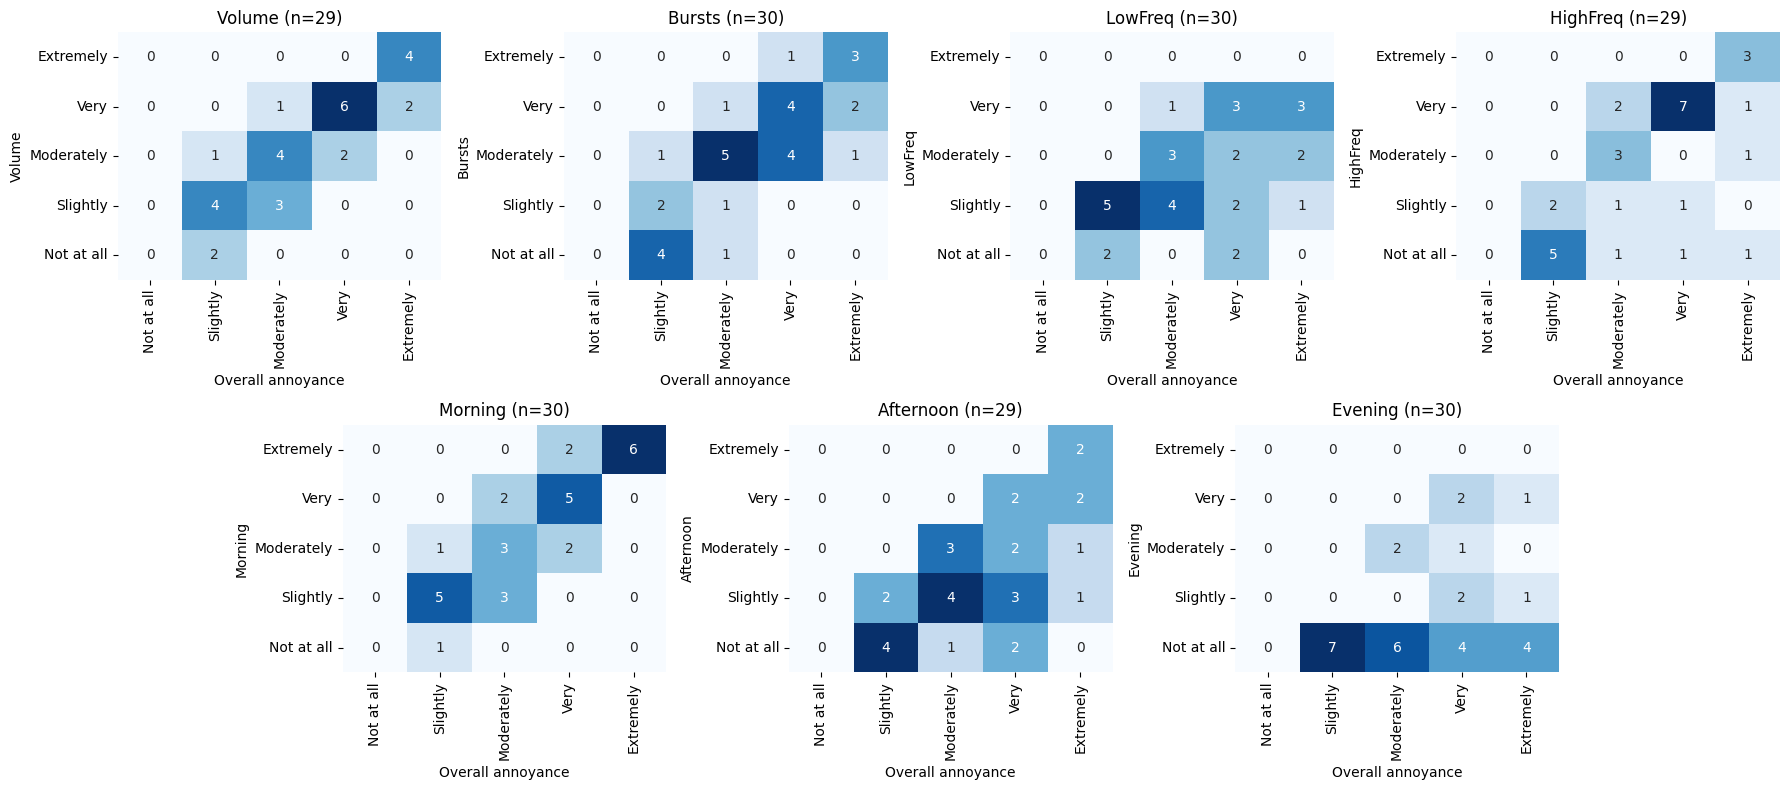

In [52]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, item in zip(axes, q5_items):
    col = f"Q5_{item}"

    all_data = df_Survey

    crosstab_all = pd.crosstab(all_data[col], all_data["Q2_Construction"])
    crosstab_all = crosstab_all.reindex(index=y_order, columns=x_order, fill_value=0)

    n_actual = crosstab_all.values.sum()

    sns.heatmap(crosstab_all, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"{item} (n={n_actual})")
    ax.set_xlabel("Overall annoyance")
    ax.set_ylabel(item)

for ax in axes[len(q5_items):]:
    ax.axis('off')

plt.tight_layout()
center_last_row(axes, n_used=len(q5_items), n_cols=4)
plt.show()

In [53]:
comparison_table_q5 = []

for item in q5_items:
    col = f"Q5_{item}"

    paired = df_Survey[[col, "Q2_Construction"]].dropna()
    item_numeric = paired[col].map(category_to_num)
    annoyance_numeric = paired["Q2_Construction"].map(category_to_num)

    n = len(paired)
    higher_than_overall = (item_numeric > annoyance_numeric).sum()
    lower_than_overall = (item_numeric < annoyance_numeric).sum()
    matches_overall = (item_numeric == annoyance_numeric).sum()

    comparison_table_q5.append({
        "Characteristic": item,
        "n": n,
        "Rated higher than overall annoyance": higher_than_overall,
        "Higher (%)": round(higher_than_overall / n * 100),
        "Rated lower than overall annoyance": lower_than_overall,
        "Lower (%)": round(lower_than_overall / n * 100),
        "Matches overall annoyance": matches_overall,
        "Matches (%)": round(matches_overall / n * 100),
    })

comparison_table_q5 = pd.DataFrame(comparison_table_q5)
comparison_table_q5

,Characteristic,n,Rated higher than overall annoyance,Higher (%),Rated lower than overall annoyance,Lower (%),Matches overall annoyance,Matches (%)
0,Volume,29,2,7,9,31,18,62
1,Bursts,30,3,10,13,43,14,47
2,LowFreq,30,1,3,18,60,11,37
3,HighFreq,29,2,7,12,41,15,52
4,Morning,30,5,17,6,20,19,63
5,Afternoon,29,0,0,20,69,9,31
6,Evening,30,0,0,26,87,4,13
